# Veri Seti Hakkında Bilgiler

### Müşteri Demografisi Bilgileri
1. `customerID (Müşteri Kimliği):` Her müşteriye özel benzersiz bir koddur. 
2. `gender (Cinsiyet):` Müşterinin kadın mı (Female) yoksa erkek mi (Male) olduğu bilgisini tutar.
3. `SeniorCitizen (Yaşlı Vatandaş):` Müşterinin yaşlı/emekli olup olmadığını belirten kategorik bir sütundur (1: Evet, 0: Hayır). Yaşlı yaş grubunun dijital davranışlarını analiz etmeye yarar.
4. `Partner (Eş/Abonelik Ortağı):` Müşterinin evli veya bir hayat ortağı olup olmadığı bilgisidir (Yes/No). Genellikle evli bireylerin abonelik bağlılıkları daha yüksek olabilmektedir.
5. `Dependents (Bakmakla Yükümlü Olunan Kişiler):` Müşterinin ailesinde bakmakla yükümlü olduğu çocuklar veya başka bireyler olup olmadığını gösterir (Yes/No). 
### Satın Alınan Hizmetler ve Detayları
6. `tenure (Müşteri Ömrü):` Müşterinin şirketten kaç aydır hizmet aldığını gösteren çok kritik bir sayısal sütundur. Şirkete olan sadakati doğrudan ölçer.
7. `PhoneService (Telefon Hizmeti):` Müşterinin şirketten bir sabit telefon hattı hizmeti alıp almadığını gösterir (Yes/No).
8. `MultipleLines (Çoklu Hat):` Telefon hizmeti olan müşterilerin birden fazla hatta sahip olup olmadığını belirtir (Yes, No, Telefon Hizmeti Yok).
9. `InternetService (İnternet Hizmeti):` Müşterinin internet altyapı türünü gösterir (DSL, Fiber Optik veya İnternet Hizmeti Yok). Analizinizde Fiber optik kullanıcılarının yüksek risk taşıdığını bulmanızı sağlayan sütundur.
10. `OnlineSecurity (Çevrimiçi Güvenlik):` Müşterinin ek bir güvenlik servisi satın alıp almadığını belirtir (Yes, No, İnternet Hizmeti Yok).
11. `OnlineBackup (Çevrimiçi Yedekleme):` Müşterinin bulut yedekleme hizmeti kullanıp kullanmadığını gösterir (Yes, No, İnternet Hizmeti Yok).
12. `DeviceProtection (Cihaz Koruma):` Müşterinin cihazları için sigorta/koruma paketi alıp almadığını tutar (Yes, No, İnternet Hizmeti Yok).
13. `TechSupport (Teknik Destek):` Müşterinin öncelikli veya ek teknik destek paketine sahip olup olmadığını gösterir (Yes, No, İnternet Hizmeti Yok). Churn oranını düşüren önemli destekleyici hizmetlerden biridir.
14. `StreamingTV (Canlı TV Yayını):` Müşterinin internet üzerinden televizyon/yayın hizmeti paketine üye olup olmadığını gösterir (Yes, No, İnternet Hizmeti Yok).
15. `StreamingMovies (Film Yayını):` Müşterinin film/sinema paketi kullanıp kullanmadığını belirtir (Yes, No, İnternet Hizmeti Yok).
### Sözleşme ve Finansal Bilgiler
16. `Contract (Sözleşme Türü):` Müşterinin taahhüt biçimidir (Aydan aya, 1 Yıllık, 2 Yıllık). Müşteri kaybı (churn) tahminlemesinde en güçlü etkiye sahip belirleyici değişkendir.
17. `PaperlessBilling (Kağıtsız/Dijital Fatura):` Müşterinin faturasını e-posta ile mi (Yes) yoksa fiziksel posta ile mi (No) aldığını gösterir.
18. `PaymentMethod (Ödeme Yöntemi):` Faturanın nasıl ödendiği bilgisidir (Elektronik Çek, Posta ile Çek, Otomatik Banka Transferi, Kredi Kartı).
19. `MonthlyCharges (Aylık Ücret):` Müşterinin her ay şirkete ödediği standart fatura tutarıdır. Fiyat hassasiyetini ve pahalı paketlerin kopuşa etkisini ölçmeye yarar.
20. `TotalCharges (Toplam Ücret):` Müşterinin sisteme dahil olduğu günden beri şirkete kazandırdığı toplam paradır. (Matematiksel olarak kabaca: tenure x MonthlyCharges). Şirket için müşterinin toplam finansal değerini (Lifetime Value) gösterir.

### Hedef Değişken (Target Variable)
21. `Churn (Müşteri Kaybı):` Analizin ve ileride kurulacak modellerin ana odak noktasıdır. Müşterinin son 1 ay içinde şirketten ayrılıp ayrılmadığını gösterir (1: Ayrıldı, 0: Kalmaya devam ediyor). Bütün analitik grafikler diğer 20 sütunun bu sütun üzerindeki etkisini çözmek için çizilir.

In [1]:
import pandas as pd
from IPython.display import display
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")   # Sürüm farklılığından dolayı verilen uyarı mesajlarını göstermemeye yarıyor.

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [2]:
df_train = pd.read_csv("train.csv")
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,0
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,0
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,0
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,0
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0


In [3]:
df_train.tail()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
5629,6308-CQRBU,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.70,0
5630,2842-JTCCU,Male,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35,1
5631,6402-ZFPPI,Female,1,No,No,25,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.20,1
5632,3594-BDSOA,Female,0,Yes,No,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.80,0
5633,6490-FGZAT,Male,0,No,No,6,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.65,109.30,0


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   seniorcitizen     5634 non-null   int64  
 3   partner           5634 non-null   object 
 4   dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   phoneservice      5634 non-null   object 
 7   multiplelines     5634 non-null   object 
 8   internetservice   5634 non-null   object 
 9   onlinesecurity    5634 non-null   object 
 10  onlinebackup      5634 non-null   object 
 11  deviceprotection  5634 non-null   object 
 12  techsupport       5634 non-null   object 
 13  streamingtv       5634 non-null   object 
 14  streamingmovies   5634 non-null   object 
 15  contract          5634 non-null   object 
 16  paperlessbilling  5634 non-null   object 


In [5]:
df_train.shape

(5634, 21)

In [6]:
print((df_train['totalcharges'] == ' ').sum())

0


In [7]:
print(df_train.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        8
churn               0
dtype: int64


In [8]:
data_train = df_train.copy()

In [9]:
data_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,0
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,0
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,0
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,0
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0


In [10]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   seniorcitizen     5634 non-null   int64  
 3   partner           5634 non-null   object 
 4   dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   phoneservice      5634 non-null   object 
 7   multiplelines     5634 non-null   object 
 8   internetservice   5634 non-null   object 
 9   onlinesecurity    5634 non-null   object 
 10  onlinebackup      5634 non-null   object 
 11  deviceprotection  5634 non-null   object 
 12  techsupport       5634 non-null   object 
 13  streamingtv       5634 non-null   object 
 14  streamingmovies   5634 non-null   object 
 15  contract          5634 non-null   object 
 16  paperlessbilling  5634 non-null   object 


In [11]:
print(data_train.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        8
churn               0
dtype: int64


In [12]:
df_test = pd.read_csv("test.csv")
df_test.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35


In [13]:
df_test.tail()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
1404,5204-HMGYF,Female,0,Yes,Yes,49,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,87.20,4345.00
1405,9950-MTGYX,Male,0,Yes,Yes,28,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.30,487.95
1406,3675-EQOZA,Male,0,No,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.65,93.55
1407,3646-ITDGM,Female,0,No,No,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.90
1408,3913-FCUUW,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),70.45,5165.70


In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   seniorcitizen     1409 non-null   int64  
 3   partner           1409 non-null   object 
 4   dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   phoneservice      1409 non-null   object 
 7   multiplelines     1409 non-null   object 
 8   internetservice   1409 non-null   object 
 9   onlinesecurity    1409 non-null   object 
 10  onlinebackup      1409 non-null   object 
 11  deviceprotection  1409 non-null   object 
 12  techsupport       1409 non-null   object 
 13  streamingtv       1409 non-null   object 
 14  streamingmovies   1409 non-null   object 
 15  contract          1409 non-null   object 
 16  paperlessbilling  1409 non-null   object 


In [15]:
df_test.shape

(1409, 20)

In [16]:
print(df_test.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        3
dtype: int64


In [17]:
data_test = df_test.copy()

In [18]:
data_test.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35


In [19]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   seniorcitizen     1409 non-null   int64  
 3   partner           1409 non-null   object 
 4   dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   phoneservice      1409 non-null   object 
 7   multiplelines     1409 non-null   object 
 8   internetservice   1409 non-null   object 
 9   onlinesecurity    1409 non-null   object 
 10  onlinebackup      1409 non-null   object 
 11  deviceprotection  1409 non-null   object 
 12  techsupport       1409 non-null   object 
 13  streamingtv       1409 non-null   object 
 14  streamingmovies   1409 non-null   object 
 15  contract          1409 non-null   object 
 16  paperlessbilling  1409 non-null   object 


In [20]:
print(data_test.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        3
dtype: int64


In [21]:
# NaN içeren satırları bulma:
display(data_train[data_train.isna().any(axis=1)])

nan_konumlari = (
    data_train[data_train.isna().any(axis=1)]
    .stack(dropna=False)
    .loc[lambda s: s.isna()]
    .reset_index()
    .rename(columns={"level_0": "index", "level_1": "sutun", 0: "deger"})
)
nan_konumlari["customerid"] = nan_konumlari["index"].map(data_train["customerid"])

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
819,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0
1999,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
2100,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4710,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
5057,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
5294,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
5361,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,0
5608,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0


In [22]:
# Eksik değerleri 0 ile doldurma
data_train['totalcharges'] = pd.to_numeric(data_train['totalcharges'], errors='coerce').fillna(0)

In [23]:
print(data_train.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [24]:
# NaN içeren satırları bulma:
display(data_test[data_test.isna().any(axis=1)])

nan_konumlari = (
    data_test[data_test.isna().any(axis=1)]
    .stack(dropna=False)
    .loc[lambda s: s.isna()]
    .reset_index()
    .rename(columns={"level_0": "index", "level_1": "sutun", 0: "deger"})
)
nan_konumlari["customerid"] = nan_konumlari["index"].map(data_test["customerid"])

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
637,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
701,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
769,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [25]:
# Eksik değerleri 0 ile doldurma
data_test['totalcharges'] = pd.to_numeric(data_test['totalcharges'], errors='coerce').fillna(0)

In [26]:
print(data_test.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
dtype: int64


In [27]:
data_train = data_train.drop(columns=["customerid"])

In [28]:
# Sütunları kategorik ve sayısal olarak kategorilere ayırma

numerical_columns = []
categorical_columns = []
for i in data_train.columns:
    if data_train[i].dtype == 'object':
        categorical_columns.append(i)
    else:
        numerical_columns.append(i)

# Churn ve SeniorCitizen'ı sayısal listeden çıkarıp kategorik listeye taşıyoruz. Çünkü binary değerlerden oluşuyorlar.
explicit_categorical = ['seniorcitizen', 'churn']

for col in explicit_categorical:
    if col in numerical_columns:
        numerical_columns.remove(col)
    if col not in categorical_columns:
        categorical_columns.append(col)

In [29]:
numerical_columns

['tenure', 'monthlycharges', 'totalcharges']

In [30]:
# sayısal değişkenlerin dağılımı
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
seniorcitizen,5634.0,0.163294,0.369667,0.0,0.0000,0.000,0.000,1.00
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.000,55.000,72.00
monthlycharges,5634.0,64.929961,30.138105,18.4,35.6625,70.500,90.000,118.75
totalcharges,5634.0,2299.334682,2279.204278,0.0,402.9750,1394.925,3835.825,8684.80
churn,5634.0,0.265353,0.441560,0.0,0.0000,0.000,1.000,1.00


In [31]:
categorical_columns

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'seniorcitizen',
 'churn']

In [32]:
# kategorik değişkenlerin dağılımı
data_train.describe(include="O").T

,count,unique,top,freq
gender,5634,2,Male,2833
partner,5634,2,No,2905
dependents,5634,2,No,3955
phoneservice,5634,2,Yes,5075
multiplelines,5634,3,No,2685
internetservice,5634,3,Fiber optic,2483
onlinesecurity,5634,3,No,2797
onlinebackup,5634,3,No,2442
deviceprotection,5634,3,No,2472
techsupport,5634,3,No,2771


In [33]:
data_train.churn.unique()

array([0, 1], dtype=int64)

* Hedef değişken ayrıktır ve bir sınıflandırma problemidir.

In [34]:
 # Numeric bir değişken olması nedeniyle frekans tablosuna, yüzde dağılımına ve çubuk grafiğine bakacağız.
data_train.churn.value_counts()

churn
0    4139
1    1495
Name: count, dtype: int64

* Şirkette kalan müşteri sayısı ayrılan müşteri sayısından fazladır. Bu durum dengesiz veri kümesine işaret eder.
* 4139 şirkette mevcut müşteri, 1495 ayrılan müşteri

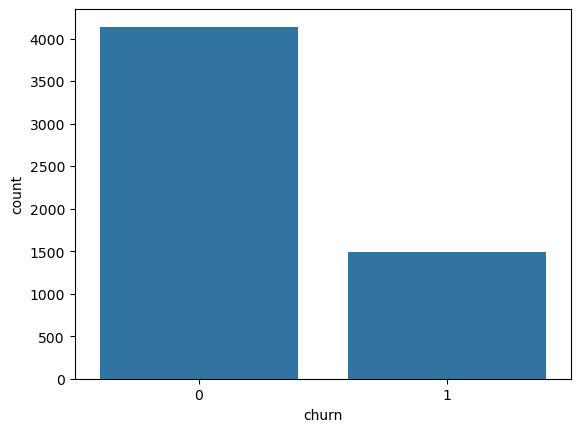

In [35]:
sns.countplot(x=data_train["churn"])
plt.show()

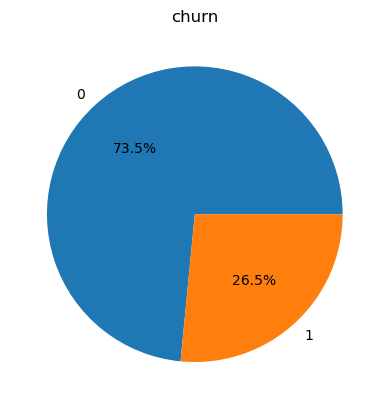

In [36]:
plt.pie(data_train['churn'].value_counts(), labels=data_train['churn'].value_counts().index, autopct='%1.1f%%')
plt.title('churn')
plt.show()

**`Churn (Genel Kayıp) Oranı`**
* 5634 müşteriden 1.495'i ayrıldı — kabaca 4 müşteriden 1'i.
* Telekomünikasyon sektörü kıyaslama kayıp oranı genellikle yıllık %15-25 arasındadır. Bu şirket üst sınıra yakın bulunuyor.
* Sonraki tüm kayıp oranları bu %26.5'lik temel çizgi ile karşılaştırılmalıdır — bunun üzerindeki her şey ortalamanın üzerinde risk anlamına gelir, altındaki her şey ise nispeten istikrarlı bir gruptur.

### Sayısal Sütun Analizi

In [37]:
numerical_columns

['tenure', 'monthlycharges', 'totalcharges']

Sayısal Sütun: tenure


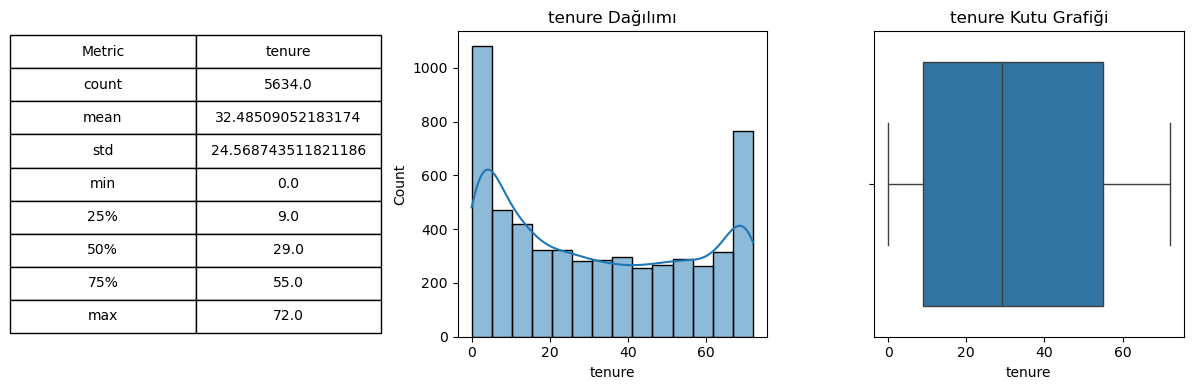

Sayısal Sütun: monthlycharges


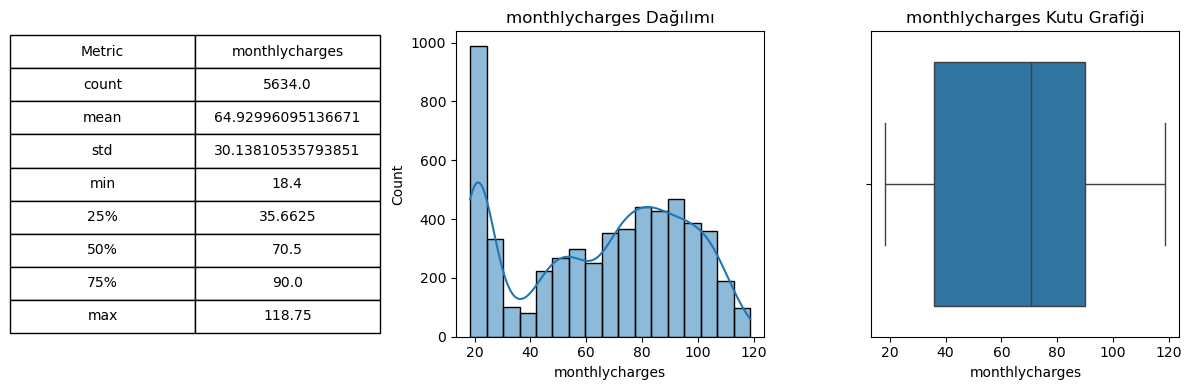

Sayısal Sütun: totalcharges


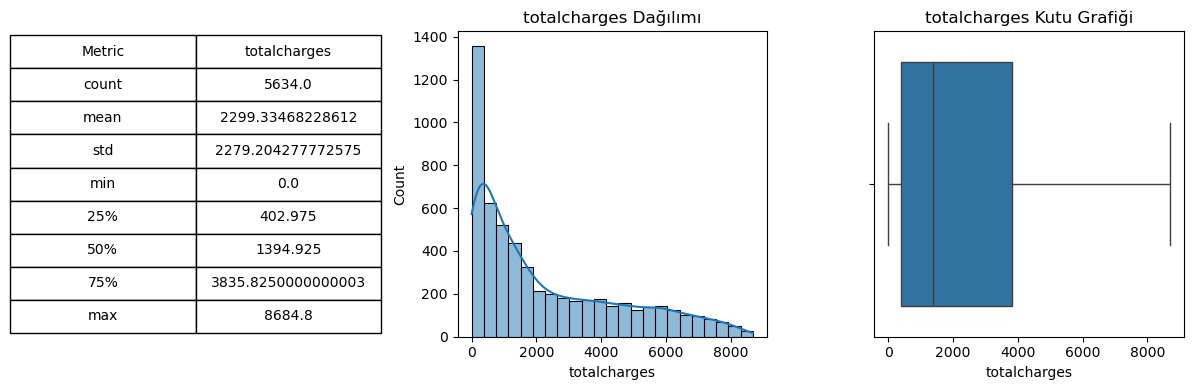

In [38]:
# Sayısal sütun analizi
for col in numerical_columns:
    print(f"Sayısal Sütun: {col}")
    stats = data_train[col].describe()
    fig = plt.figure(figsize=(12, 4))

    # İlk sütun: İstatistiksel özet tablosu
    ax1 = fig.add_subplot(1, 3, 1)  # 1 satır, 3 sütun, 1. grafik
    ax1.axis('off')  # Grafik eksenlerini kapat
    table = plt.table(
        cellText=stats.reset_index().values,
        colLabels=["Metric", col],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)  # Yazı boyutu 
    table.scale(1.2, 2)  # Tablo genişlik ve yükseklik ölçeklendirme

    # Histogram
    ax2 = fig.add_subplot(1, 3, 2)
    sns.histplot(data_train[col], kde=True, ax=ax2)
    ax2.set_title(f"{col} Dağılımı")

    # Boxplot
    ax3 = fig.add_subplot(1, 3, 3)
    sns.boxplot(x=data_train[col], ax=ax3)
    ax3.set_title(f"{col} Kutu Grafiği")

    plt.tight_layout()
    plt.show()

## Yorumlar

**`Tenure (Müşteri Ömrü) Çift Tepeli (U-Şekilli) Bir Dağılım Gösteriyor`**
* Veride iki büyük yığılma (tepe noktası) göze çarpmaktadır: Bunlardan ilki 1. ayda (yüksek kayıp riski taşıyan yepyeni müşteriler), ikincisi ise 72. ayda (şirketten en uzun süre hizmet alan, oldukça sadık kitle) yer almaktadır.
* Müşteri kaybı (churn) oranı 14. aydan sonra düşük seviyelerde seyrederken, 66. aydan sonra hafif bir artış eğilimi göstermektedir.
* Veri setinin genel çarpıklık (skewness) değeri sıfıra yakın olsa da, bu çift tepeli (bimodal) yapı aslında tek bir veri kümesi içinde birbirinden tamamen farklı iki ayrı müşteri popülasyonunun gizlendiğini ortaya koymaktadır.
* `Ticari Çıkarım / Strateji (Business implication:):` Bir müşteriyi kritik eşik olan ilk 12 aylık dönemde sistemde tutabilmek, hayatta kalma sınırını aşmak anlamına gelir; zira bu süreden sonra müşteri sadakati doğrusal değil, katlanarak (muazzam bir ivmeyle) artmaktadır.

**`MonthlyCharges (Aylık Ücretler) İki Belirgin Kümelenmeye Sahip`**
* Grafik incelendiğinde yaklaşık £20 seviyesinde keskin bir tepe noktası (yalnızca internet paketi bulunmayan, temel telefon hizmeti alan aboneler) göze çarpmaktadır.
* İkinci ve daha geniş bir kitle ise £60 ile £100 arasında (internet ve ek servislere üye olan aboneler) kümelenmiştir.
* £30 ile £50 aralığında ise çok az sayıda müşteri yer almaktadır — bu durum, fiyatlandırmanın yumuşak bir geçiş yerine doğrudan belirgin ürün katmanlarından (segmentlerinden) oluştuğunu göstermektedir.
* `Ticari Çıkarım / Strateji (Business implication:):` Şirket aslında fiilen iki ana ürün kategorisine sahiptir. Müşteri kaybı (churn) davranışlarının bu iki küme arasında son derece farklı olması beklenir — ki analizin ilerleyen kısımları da bu durumu doğrulamaktadır.

**`TotalCharges (Toplam Ücretler) Yoğun Şekilde Sağa Çarpık (Right-Skewed)`**
* Müşterilerin büyük bir kısmının Toplam Ücret (TotalCharges) değeri düşüktür — bu durum, bu kitlelerin hizmette nispeten yeni olduklarını gösterir.
* Diğer tarafta ise, hizmet süresi uzun (long-tenure) olan küçük bir grup müşteri, yaşam boyu harcamada (lifetime spend) £5.000 ile £8.000+ üzerinde bir kümülatif tutara ulaşmıştır.
* TotalCharges, büyük ölçüde tenure (müşteri ömrü) ile MonthlyCharges (aylık ücret) değişkenlerinin çarpımından oluşur — bu nedenle veri setinde örtüşen (mükerrer) bilgi taşır ve makine öğrenmesi modellerinde tenure ile yan yana bağımsız bir özellik (independent feature) olarak bir arada kullanılmamalıdır.
* Bu değişken, en çok, müşteri kaybetmeme (retention) kampanyalarında öncelik verilmesi gereken yüksek yaşam boyu değere (LTV - Lifetime Value) sahip VIP müşterileri tespit etmek için kullanışlıdır.


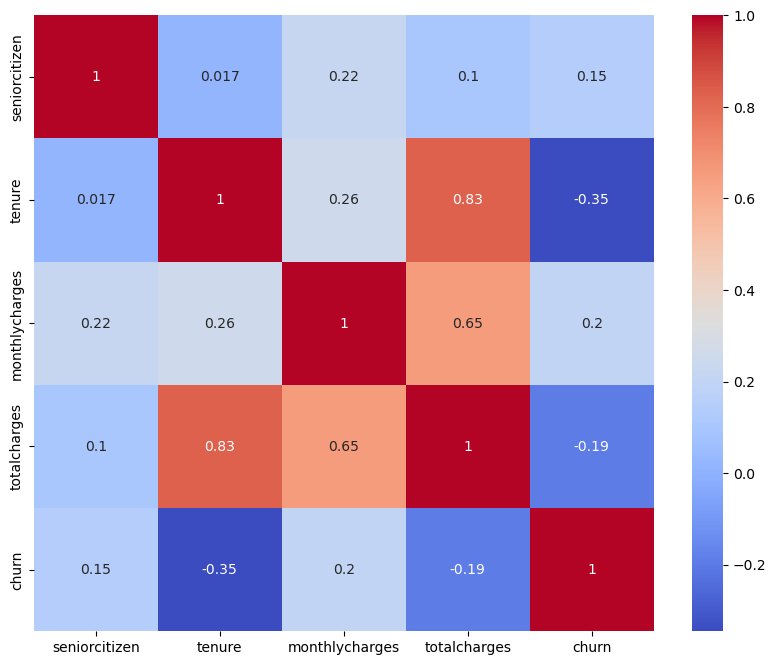

In [39]:
# Sadece sayısal sütunları seç
numeric_data = data_train.select_dtypes(include=['float64', 'int64'])

# Korelasyon matrisi oluştur ve görselleştir
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

**`Korelasyon Analizi:`**
* `Tenure ve Churn (-0.35):` Aralarında negatif ve güçlü bir ilişki var. Yani bir müşterinin şirkette kaldığı süre (tenure) arttıkça, şirketten ayrılma (churn) ihtimali belirgin bir şekilde azalıyor. Sadık müşteriler daha kararlı kalıyor.
* `MonthlyCharges (Aylık Ücret) ve Churn (0.2):` Aralarında pozitif bir ilişki var. Aylık fatura miktarı yükseldikçe, müşterilerin churn olma (ayrılma) eğilimi artıyor. Yüksek fiyatlar müşteriyi kaçırıyor diyebiliriz.
* `SeniorCitizen (Yaşlı Vatandaş) ve Churn (0.15):` Pozitif bir ilişki var. Yaşlı müşterilerin gençlere kıyasla churn olma ihtimali biraz daha yüksek (önceki içgörülerinizle de örtüşüyor).
* `TotalCharges (Toplam Ücret) ve Churn (-0.19):` Hafif negatif bir ilişki var. Toplam ödediği ücret yüksek olanların churn oranı biraz daha düşük görünüyor, çünkü bu kişiler genellikle çok uzun süredir sistemde olan (yüksek tenure) müşterilerdir.


## Kategorik Sütun Analizi

In [40]:
categorical_columns

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'seniorcitizen',
 'churn']

Kategorik Sütun: gender


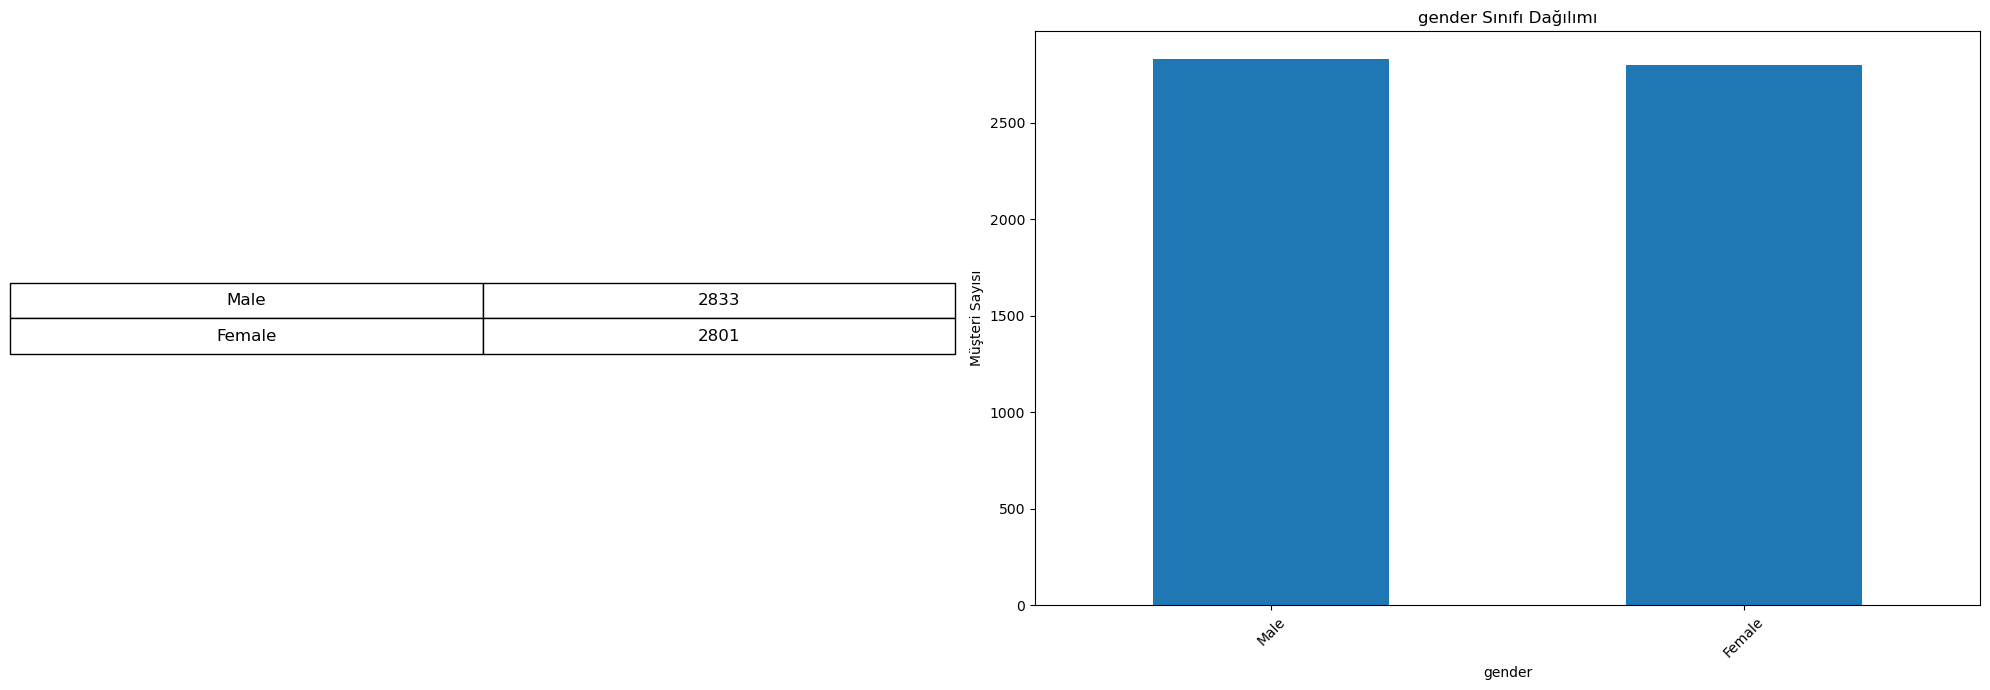

Kategorik Sütun: partner


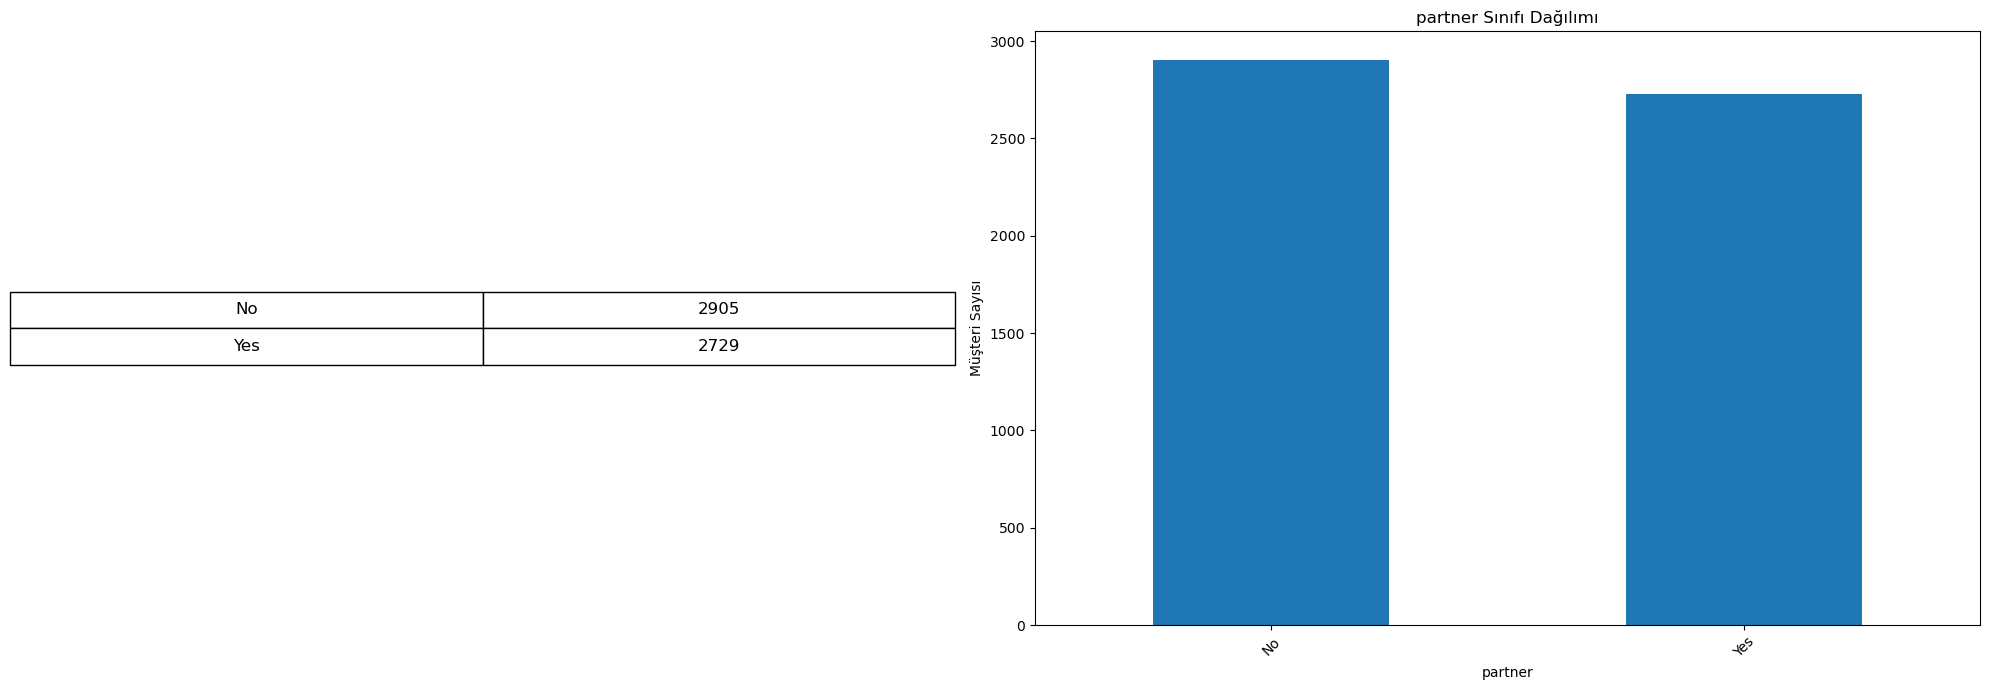

Kategorik Sütun: dependents


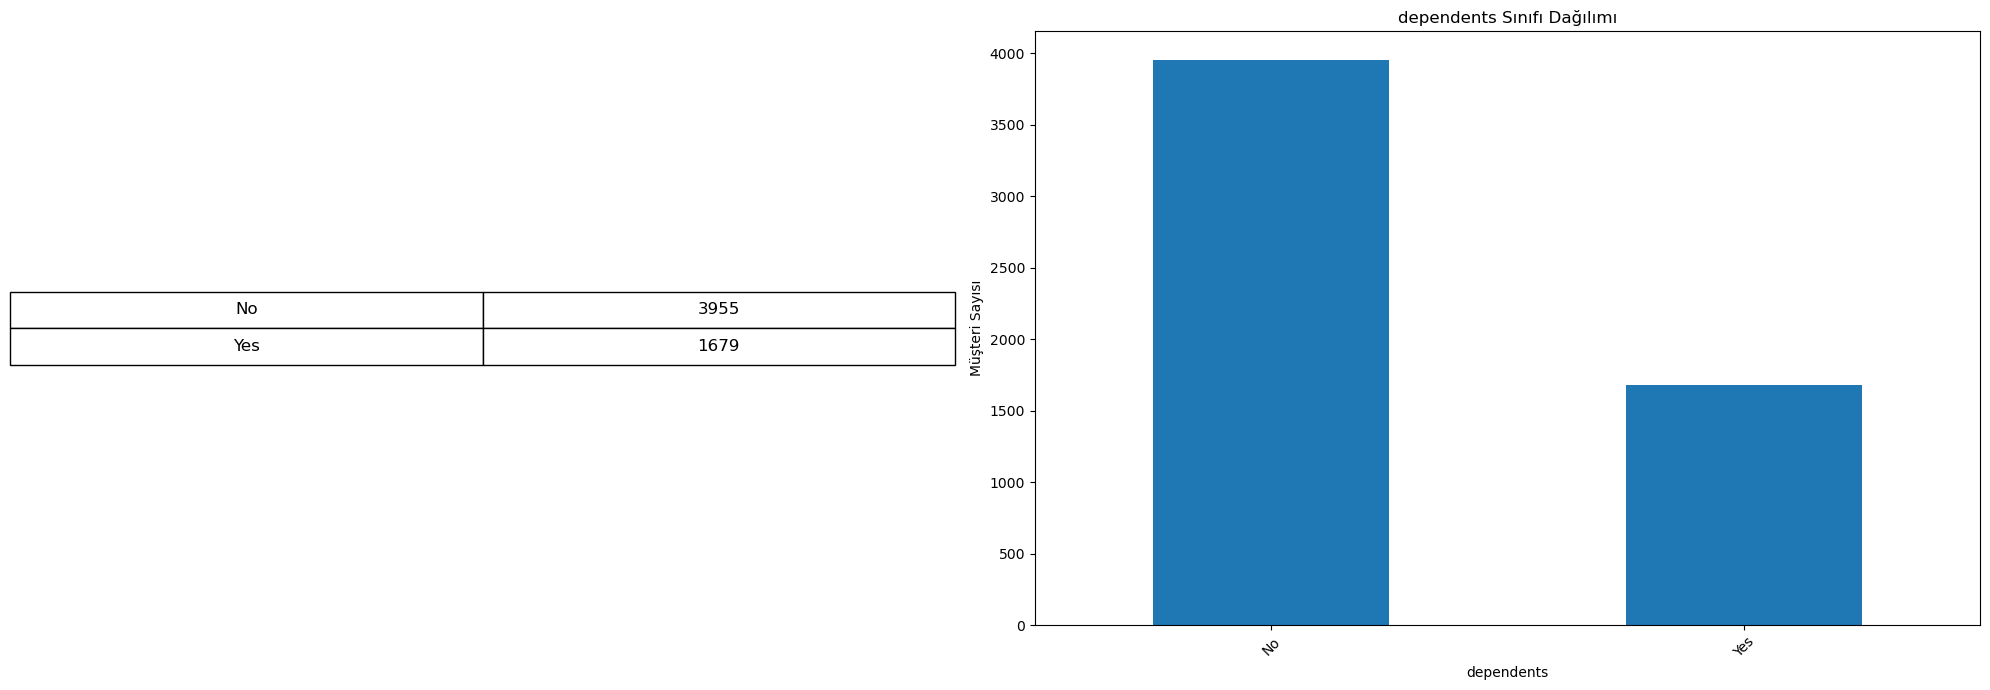

Kategorik Sütun: phoneservice


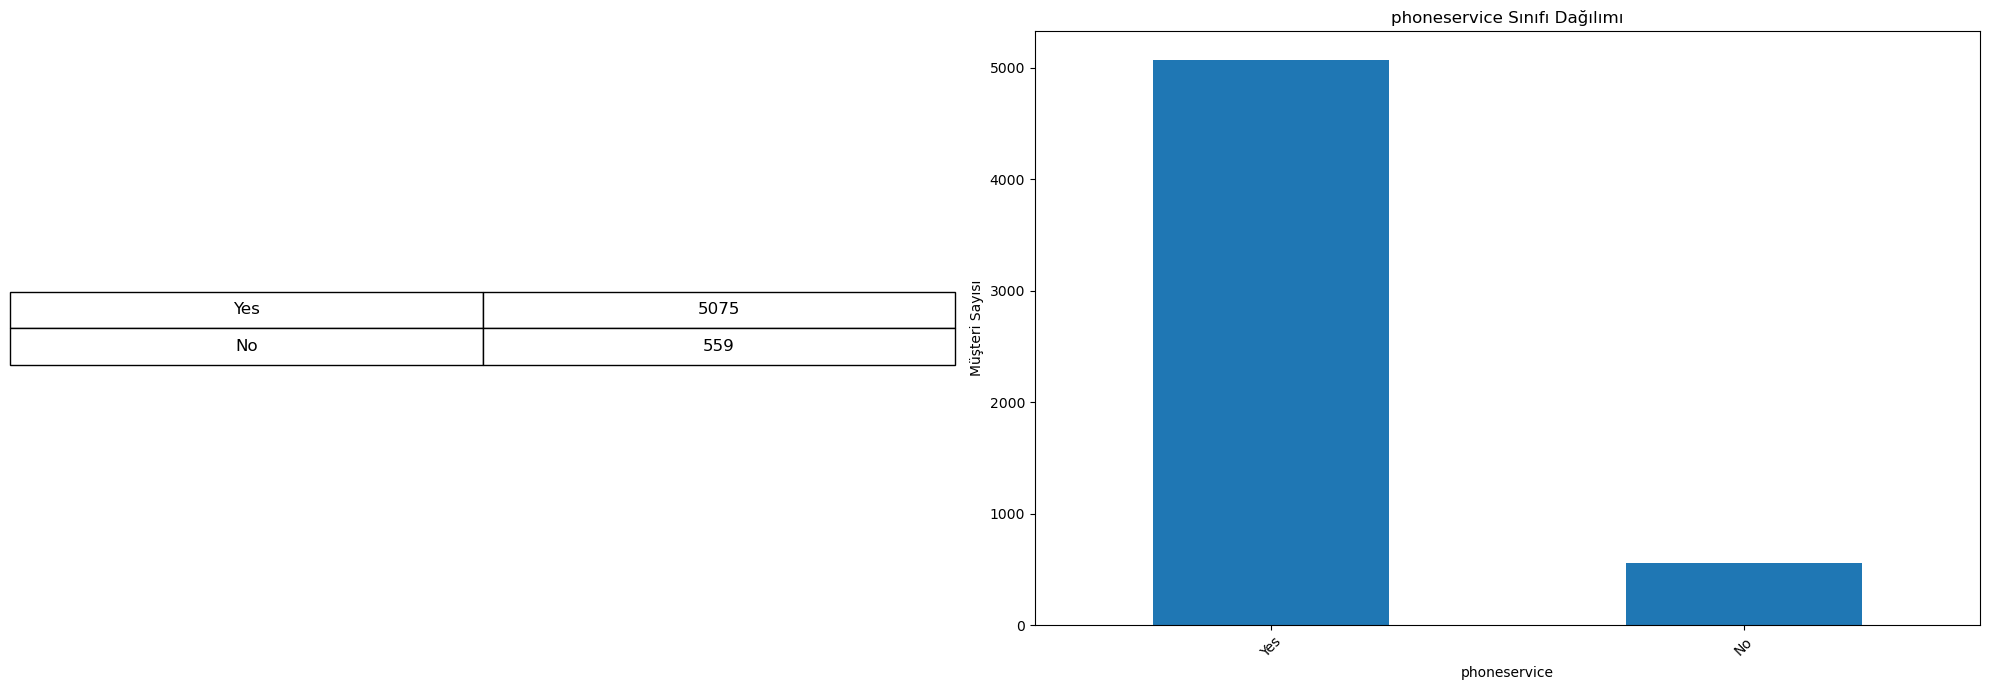

Kategorik Sütun: multiplelines


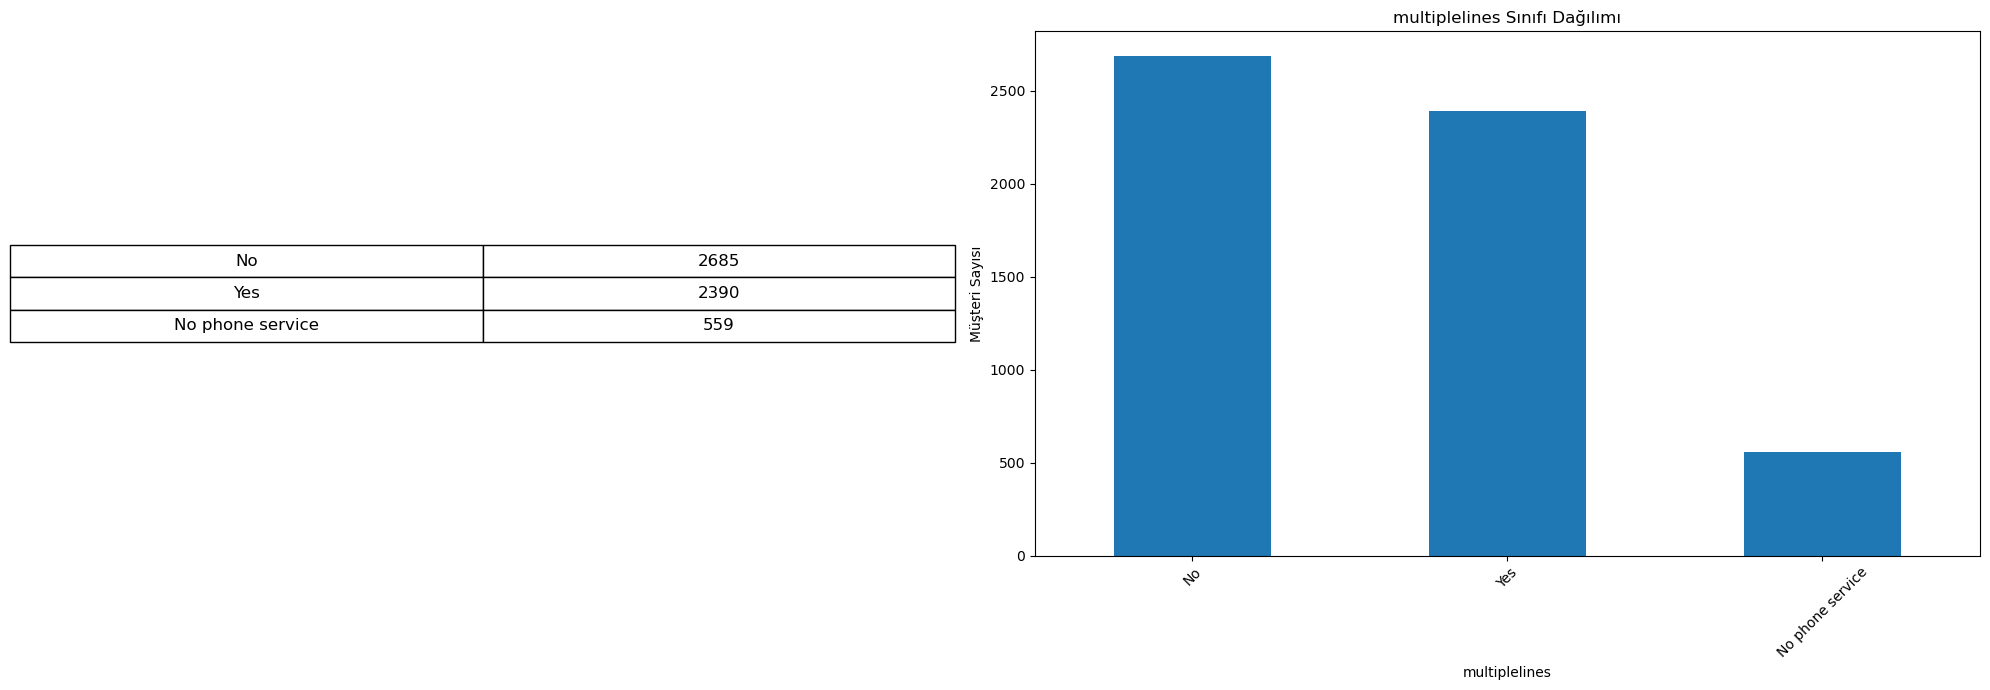

Kategorik Sütun: internetservice


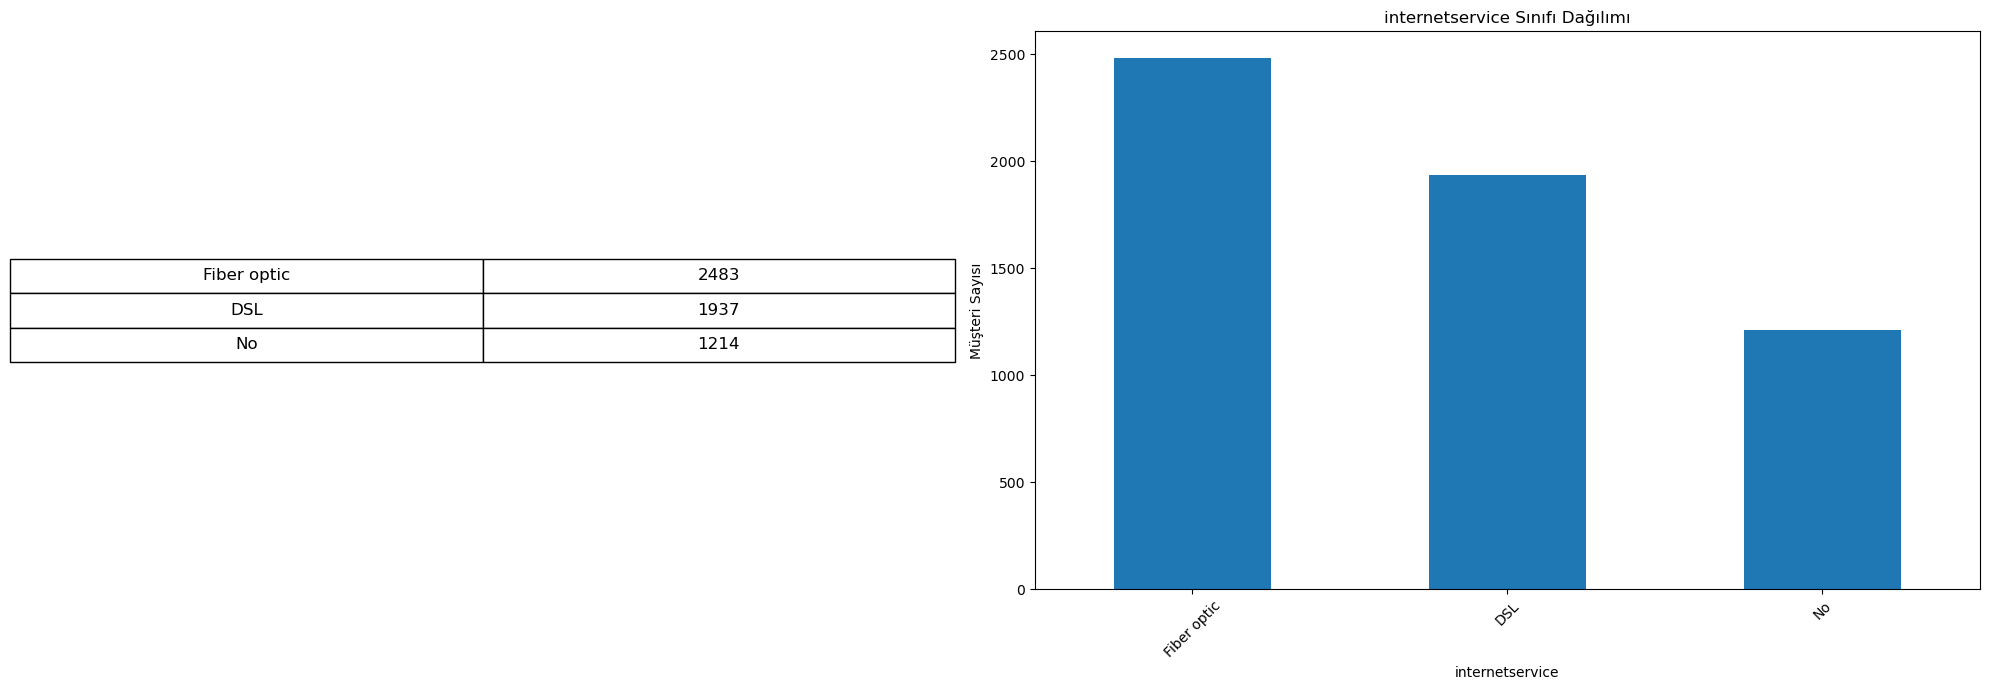

Kategorik Sütun: onlinesecurity


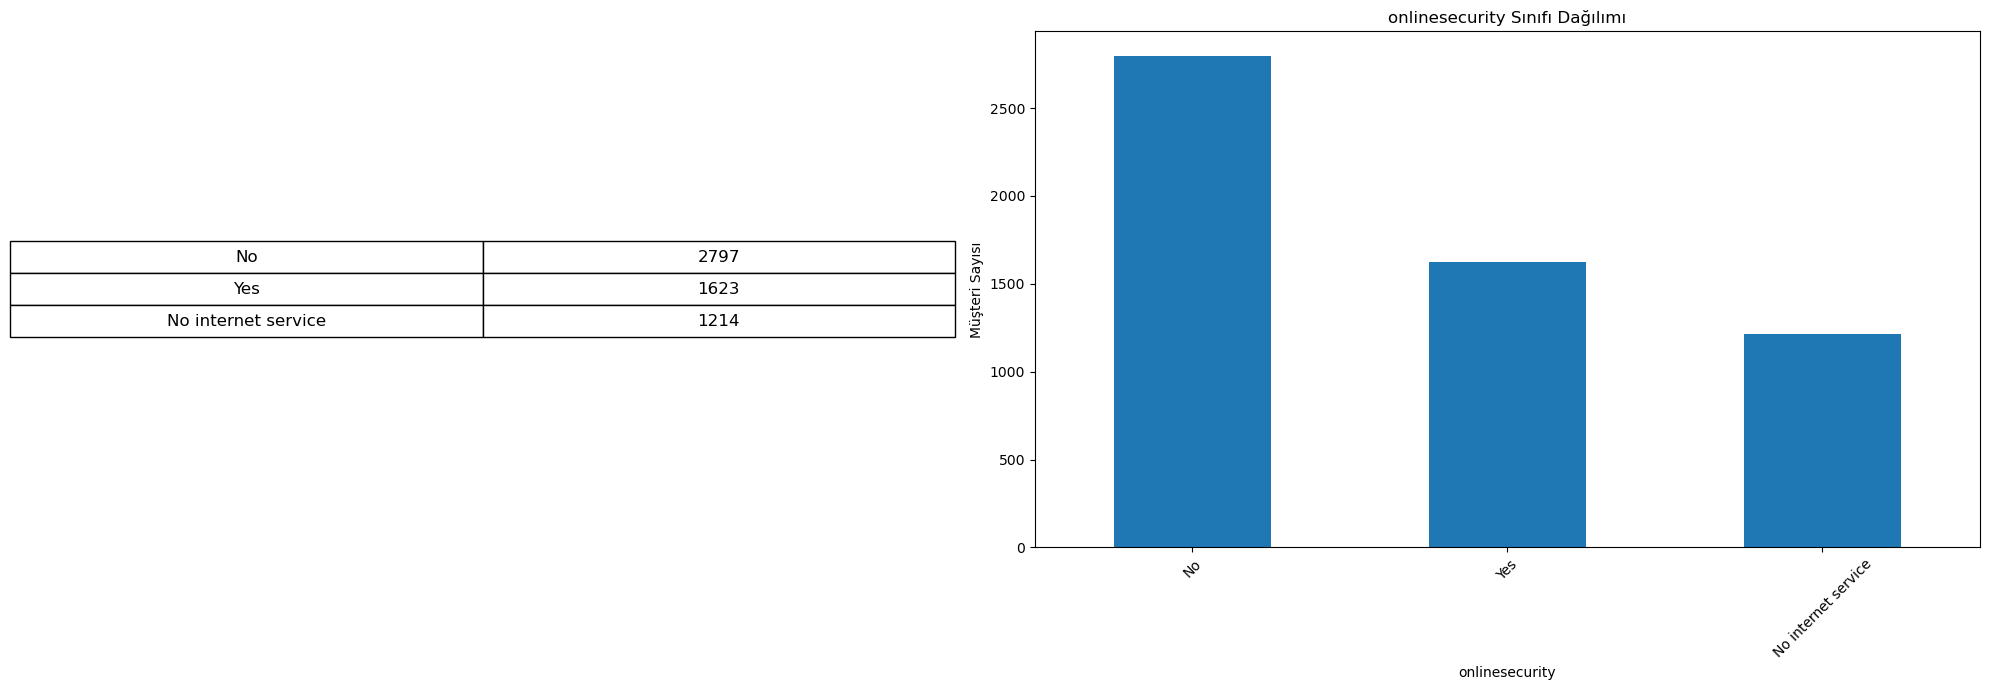

Kategorik Sütun: onlinebackup


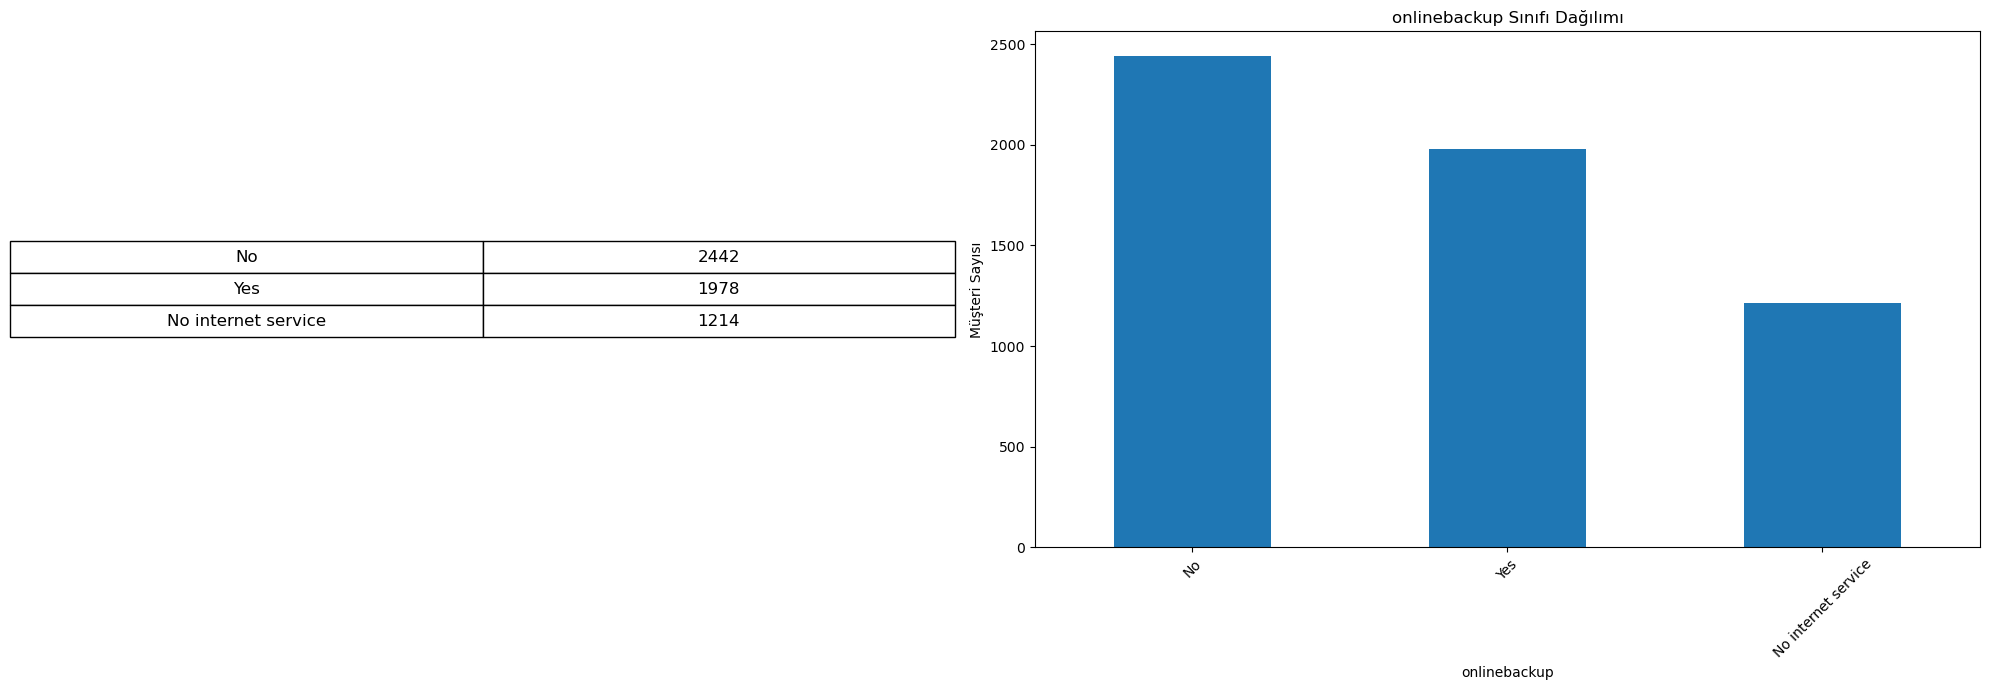

Kategorik Sütun: deviceprotection


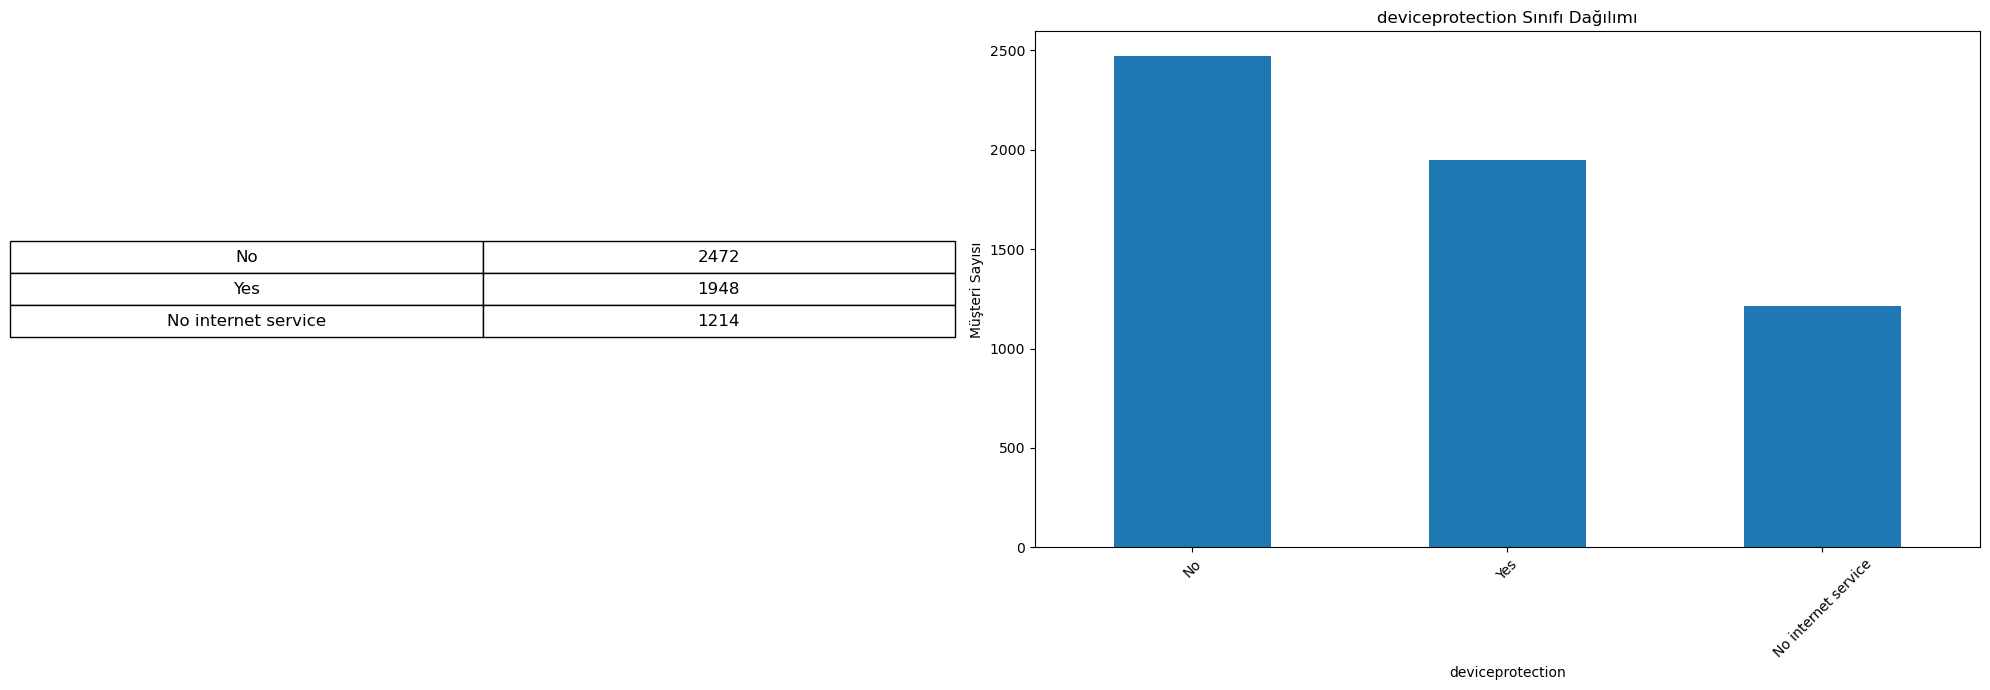

Kategorik Sütun: techsupport


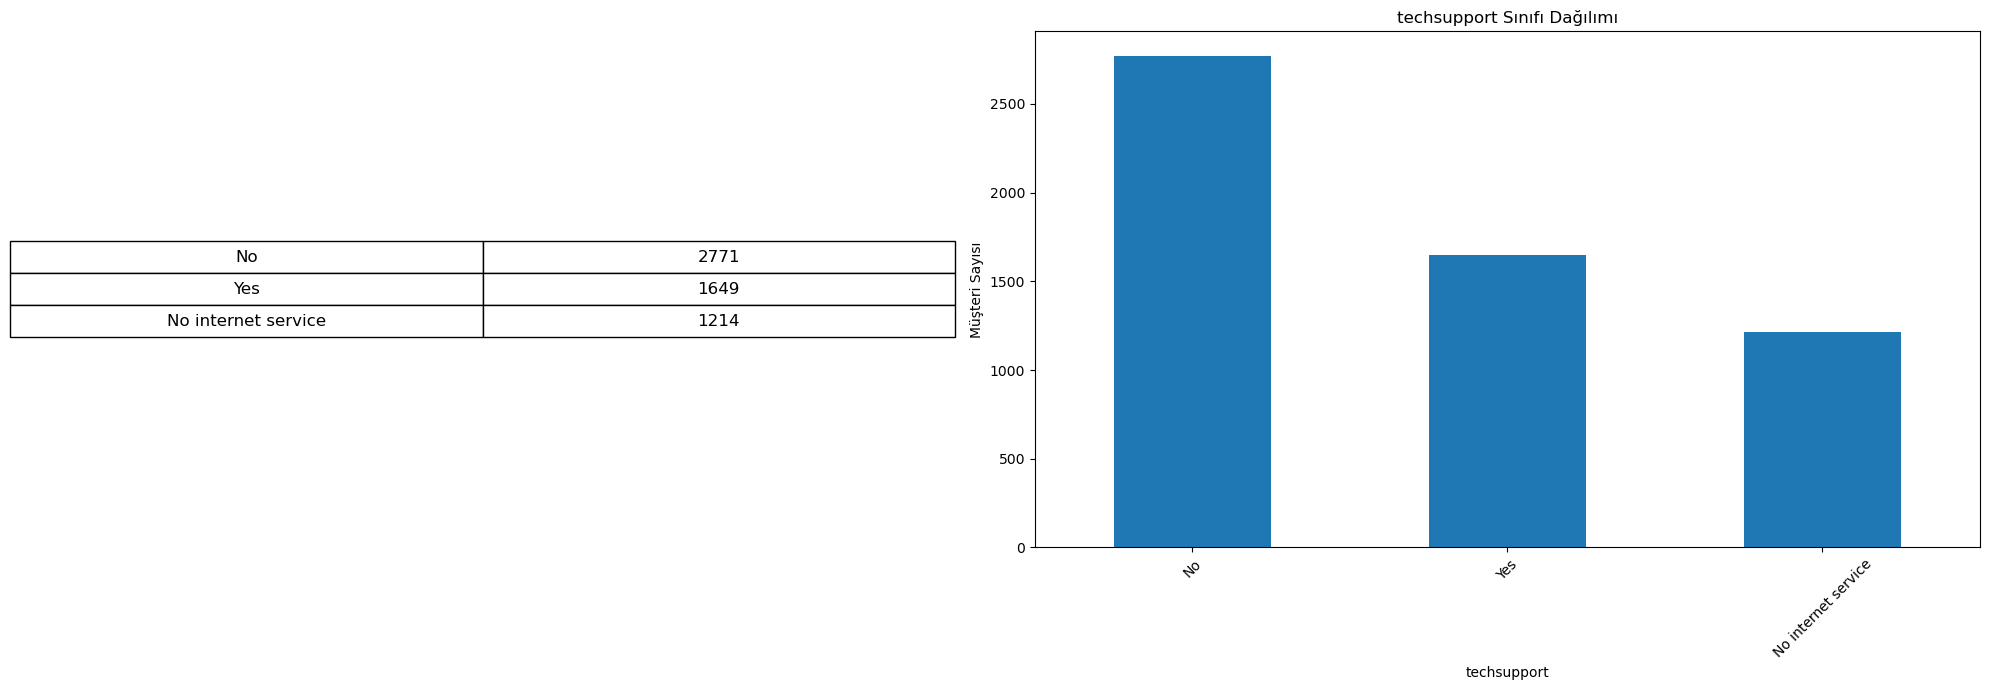

Kategorik Sütun: streamingtv


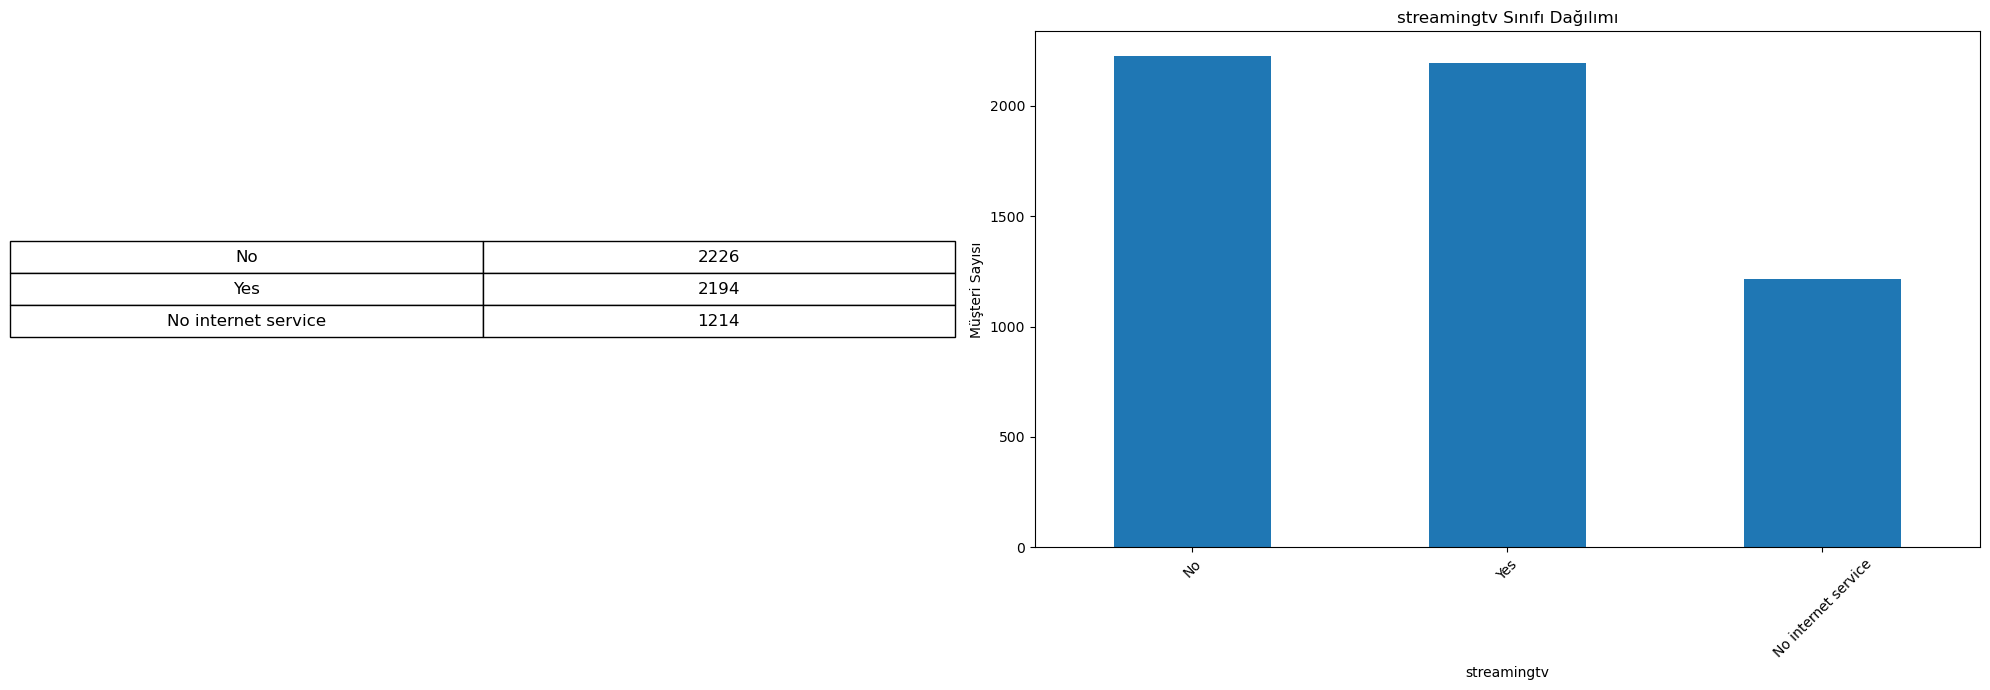

Kategorik Sütun: streamingmovies


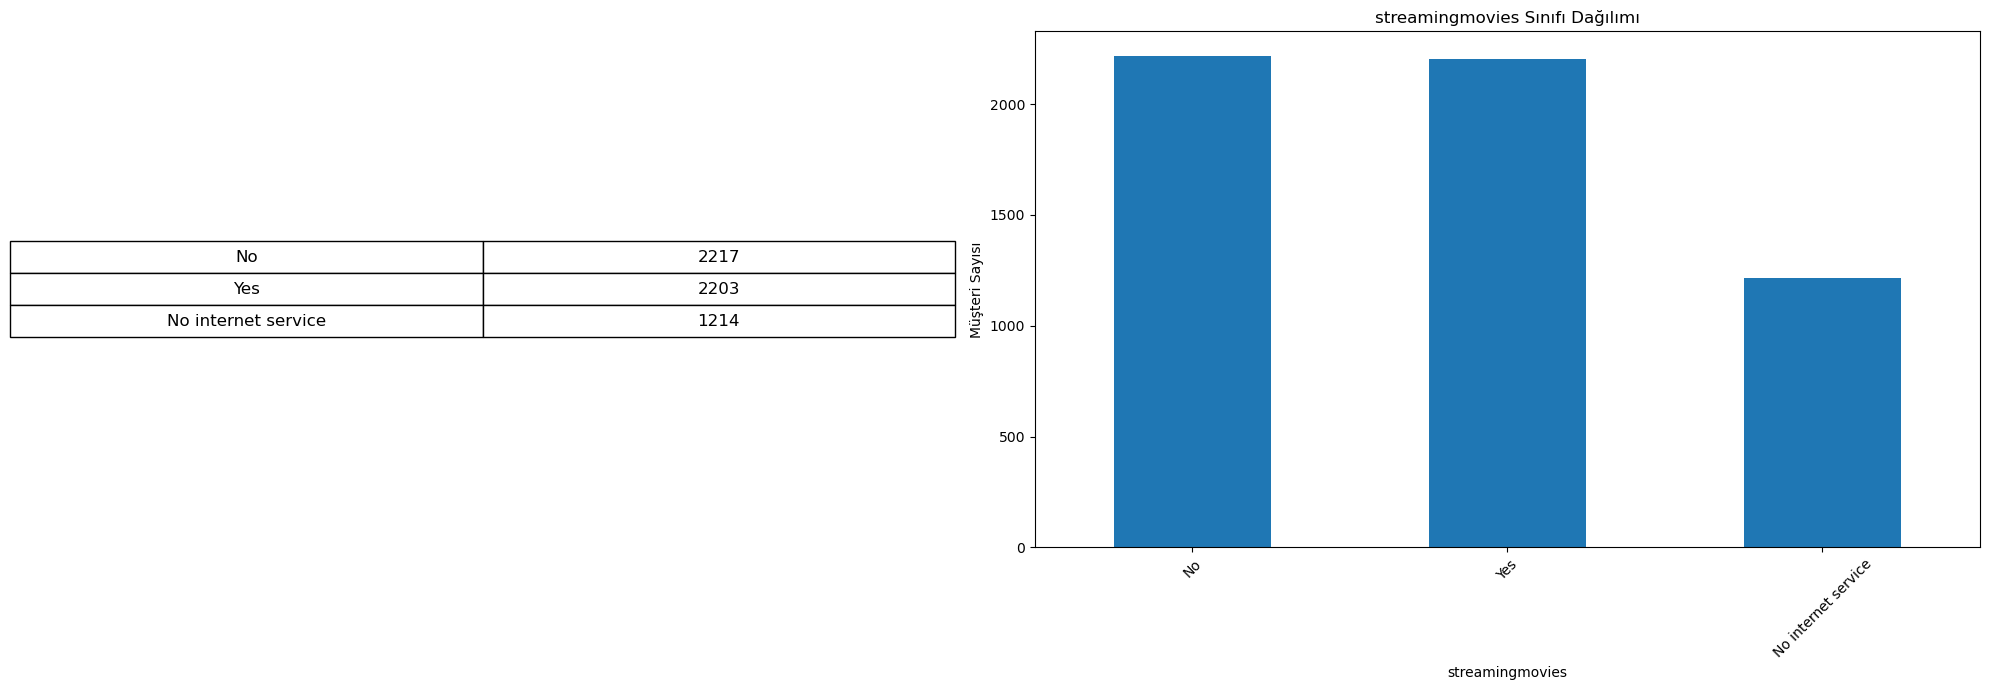

Kategorik Sütun: contract


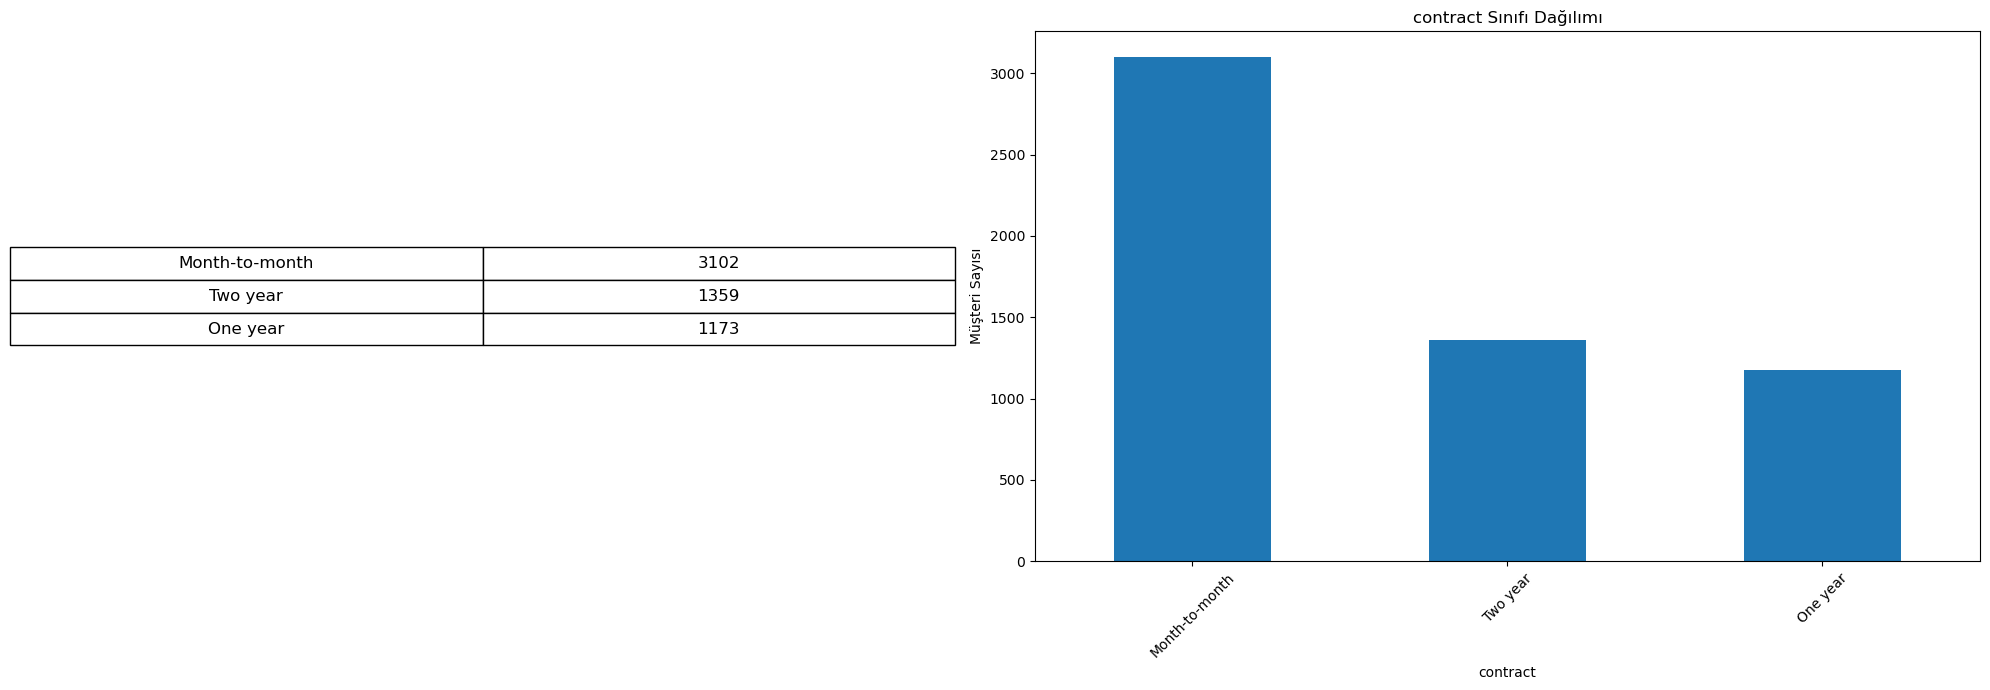

Kategorik Sütun: paperlessbilling


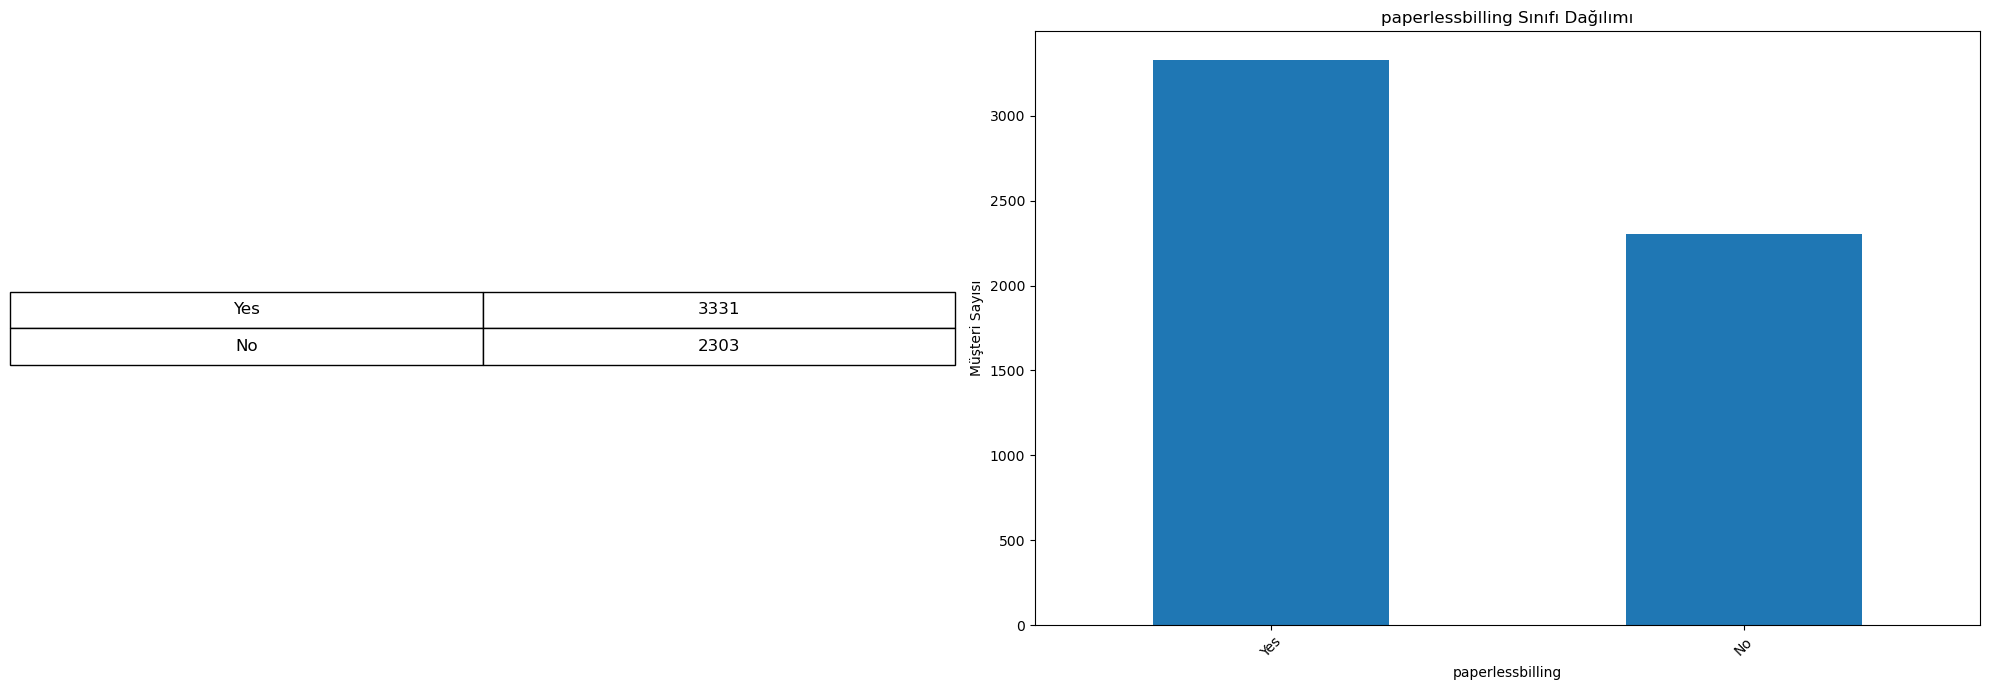

Kategorik Sütun: paymentmethod


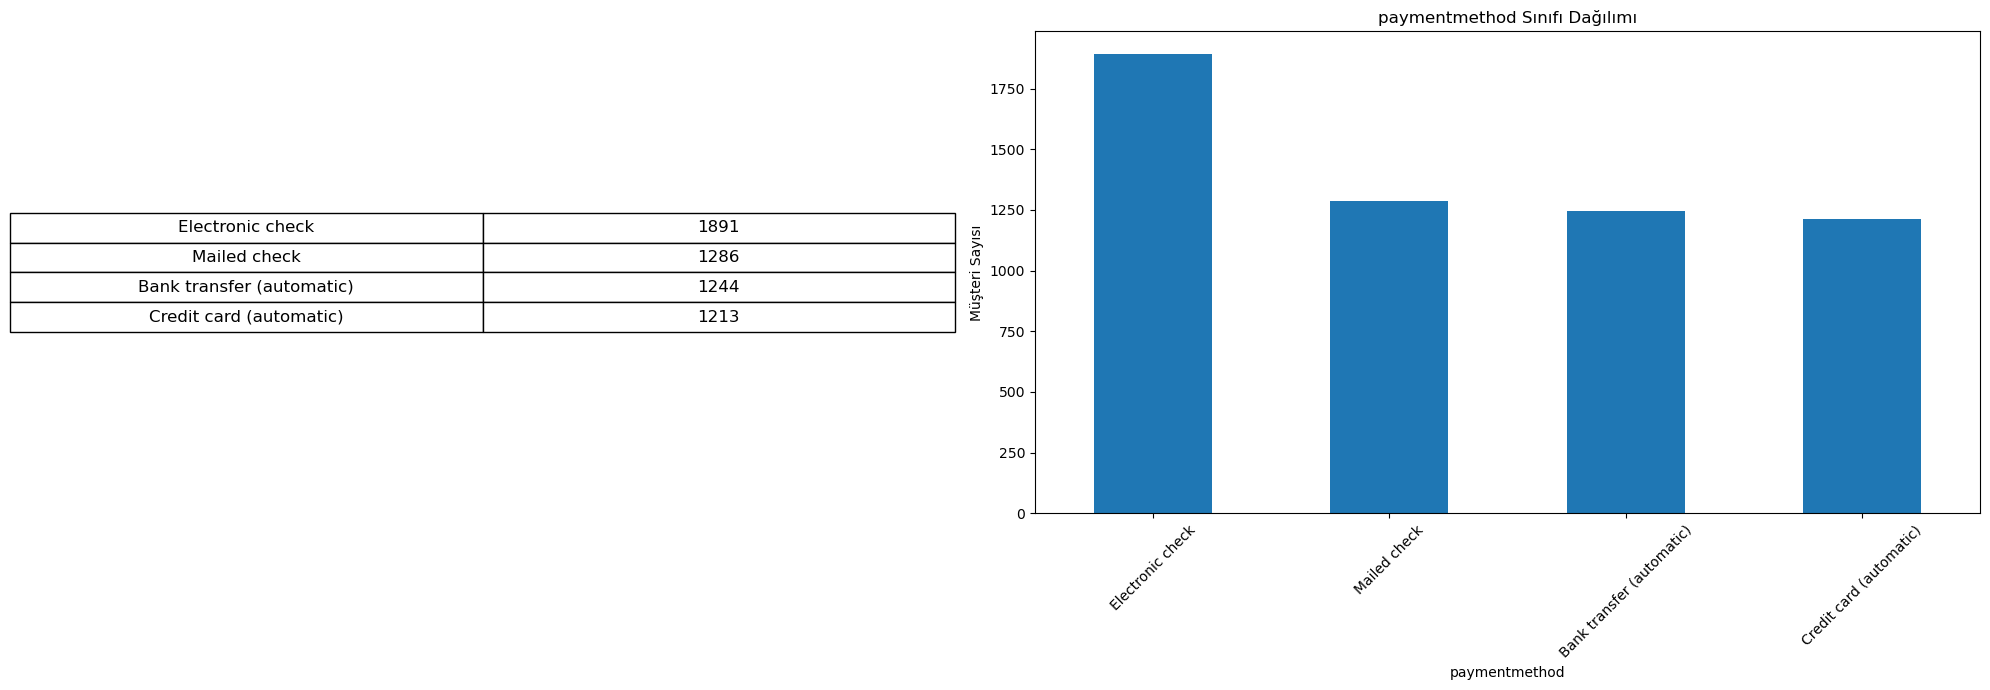

Kategorik Sütun: seniorcitizen


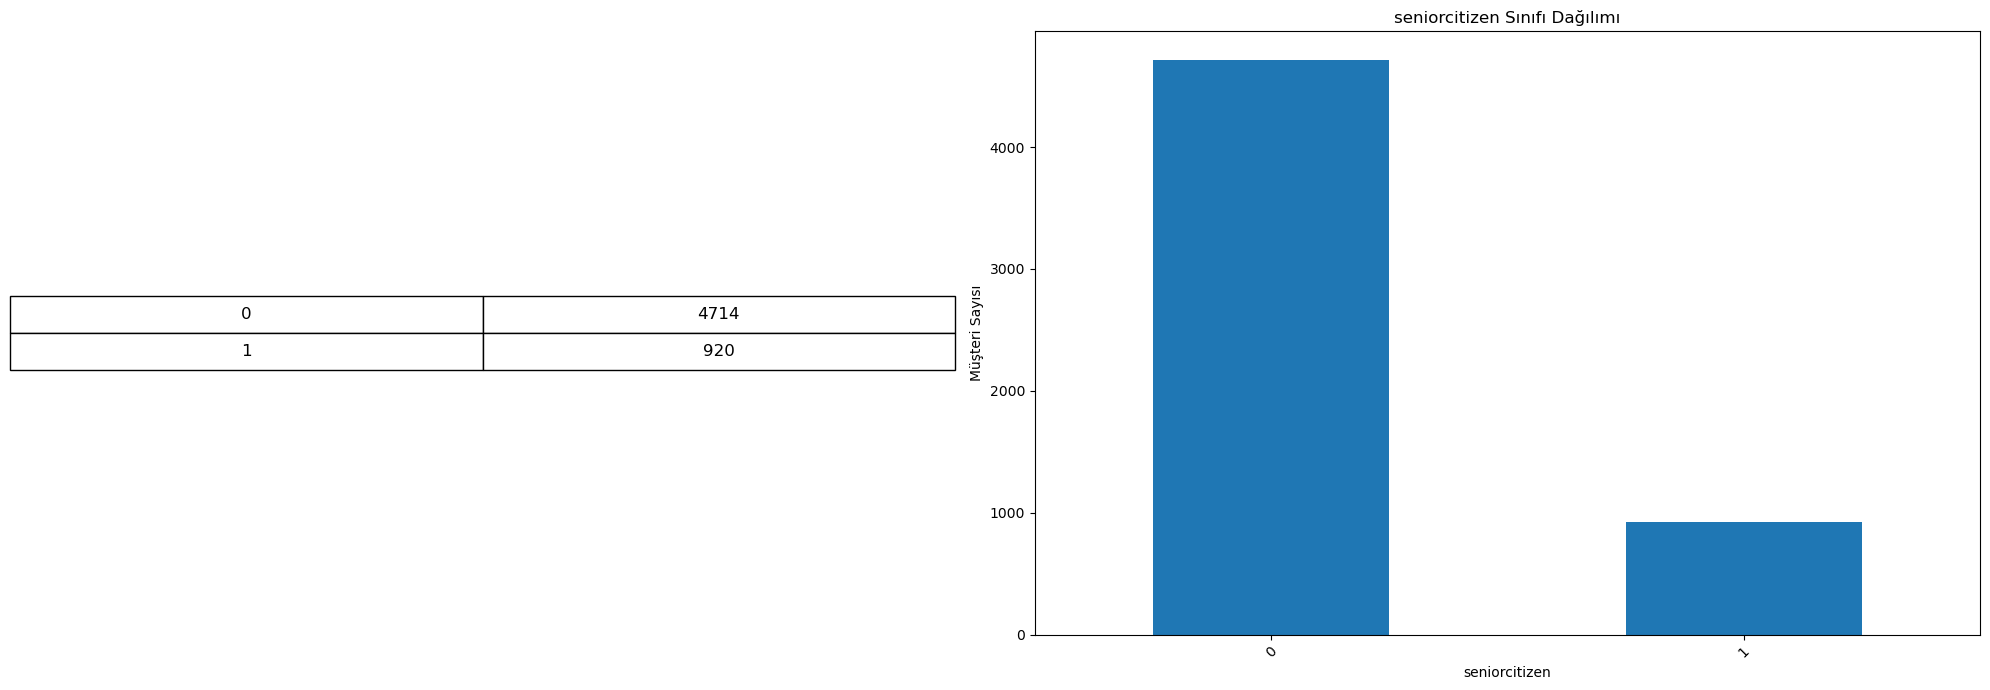

Kategorik Sütun: churn


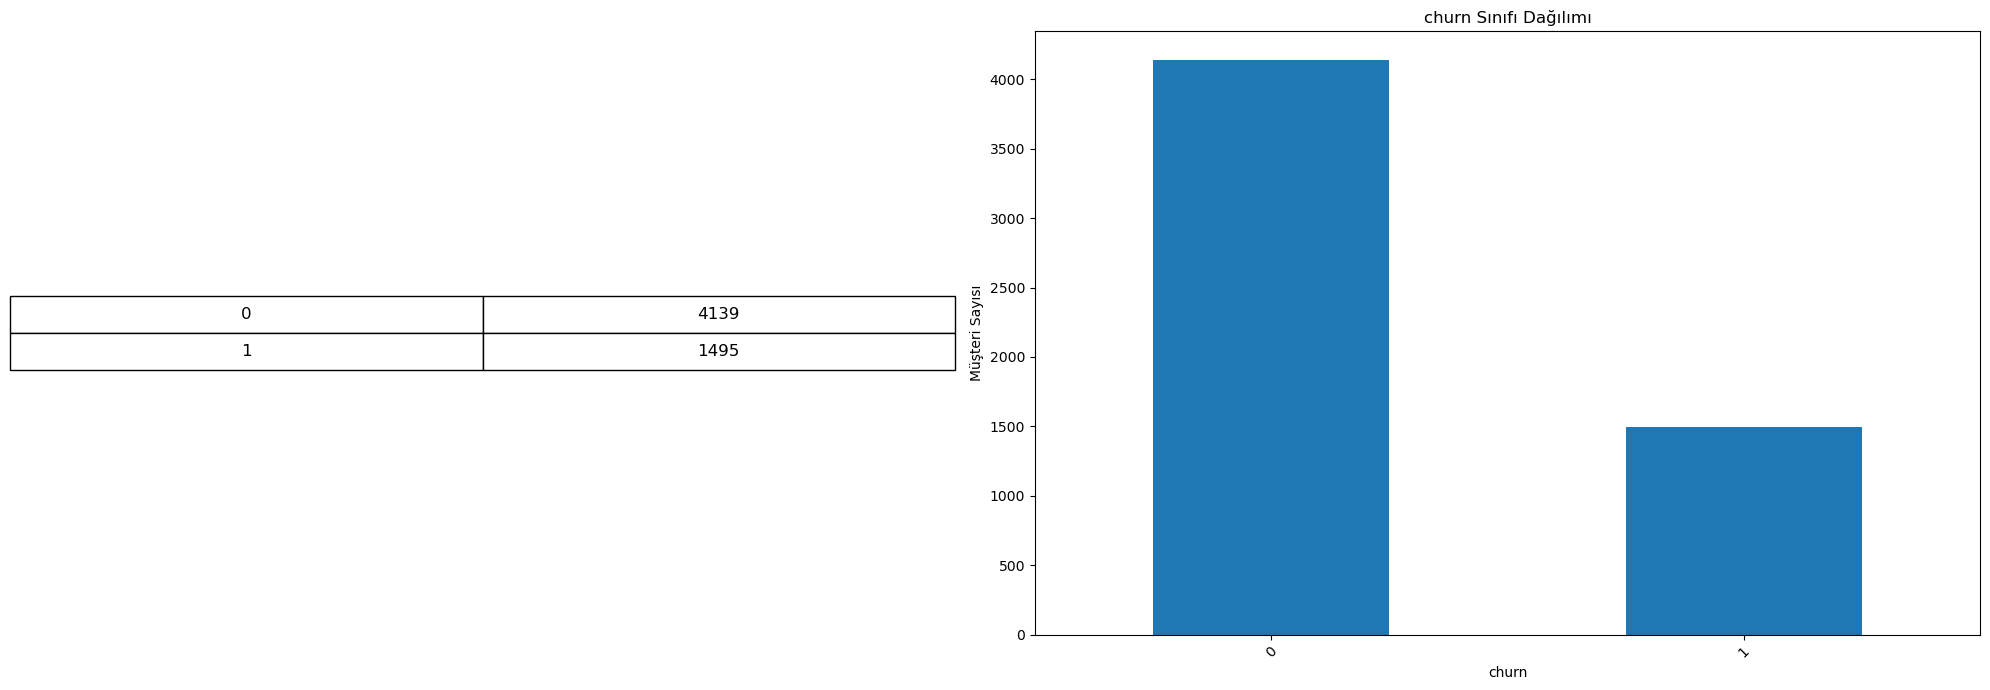

In [41]:
# Kategorik sütun analizi
for col in categorical_columns:
    # Kategorik sütun bilgilerini yazdır
    print(f"Kategorik Sütun: {col}")
    counts = data_train[col].value_counts()
    fig = plt.figure(figsize=(20, 7))

    ax1 = fig.add_subplot(1, 2, 1)  # 1 satır, 2 sütun, 1. grafik
    ax1.axis('off')
    table = plt.table(
        cellText=counts.reset_index().values,
        loc='center',
        cellLoc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)

    # İkinci sütun: Bar grafiği
    ax2 = fig.add_subplot(1, 2, 2)  # 1 satır, 2 sütun, 2. grafik
    counts.plot(kind='bar', ax=ax2)
    ax2.set_title(f"{col} Sınıfı Dağılımı")
    ax2.set_ylabel("Müşteri Sayısı")  # Y ekseni etiketi
    ax2.set_xlabel(col)  # X ekseni etiketi
    plt.xticks(rotation=45)  # Etiketleri döndürerek okunaklı yap

    plt.tight_layout()
    plt.show()

gender ile churn İlişkisi


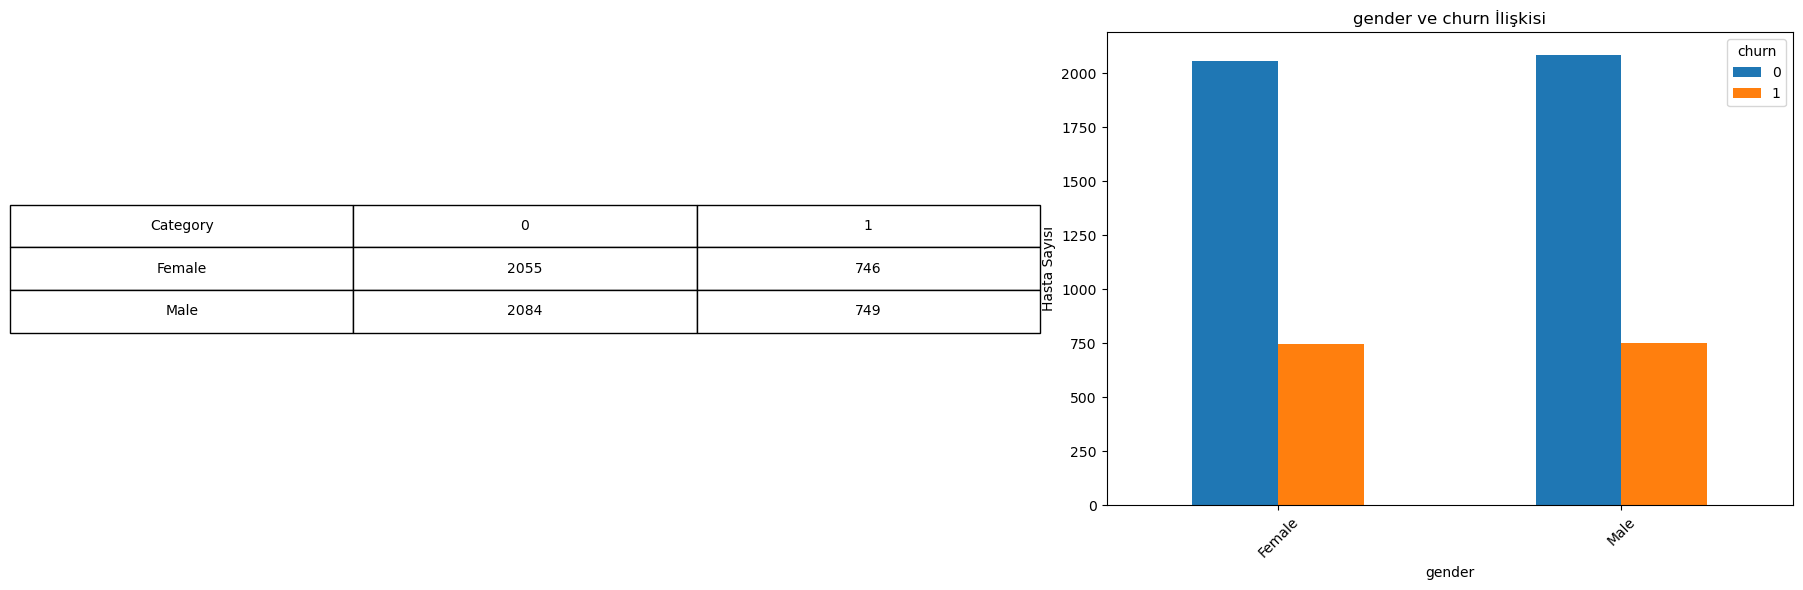

partner ile churn İlişkisi


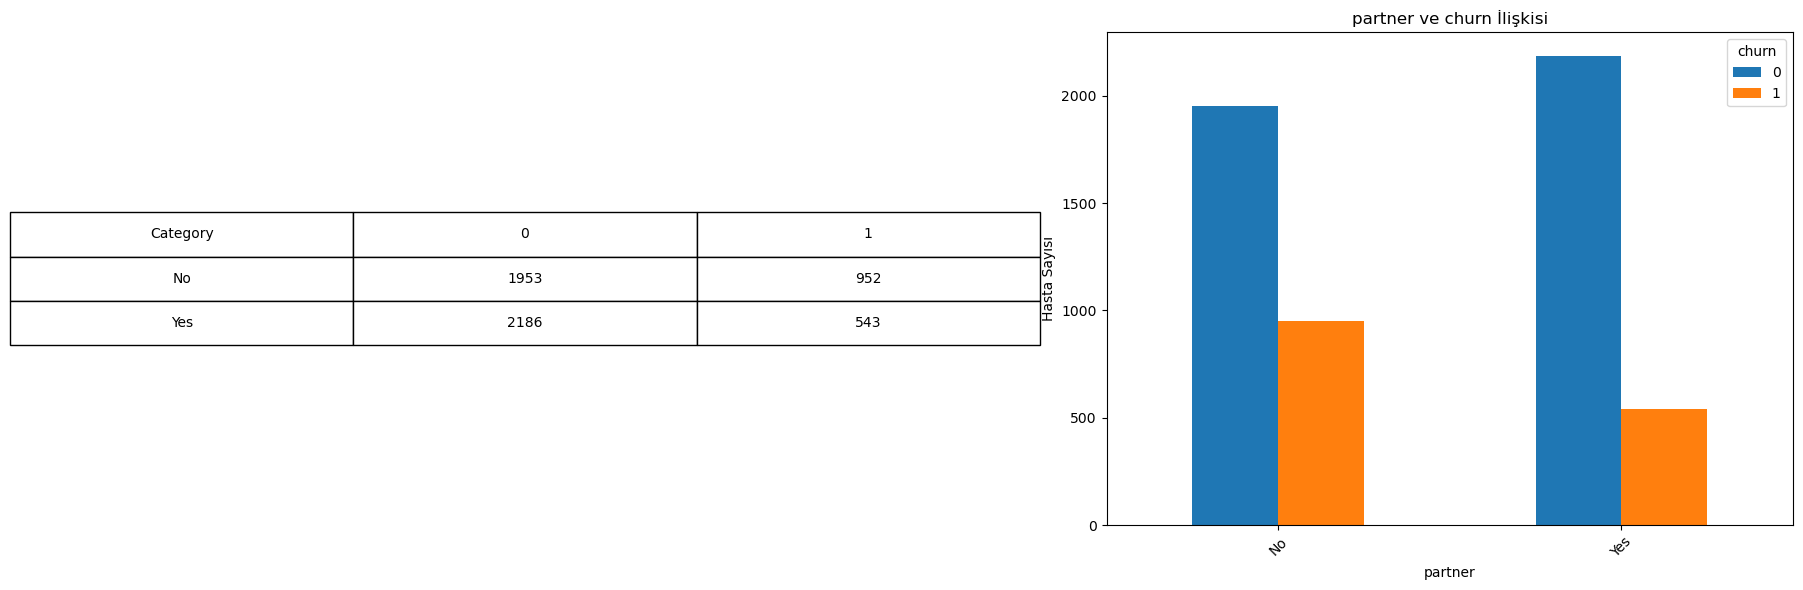

dependents ile churn İlişkisi


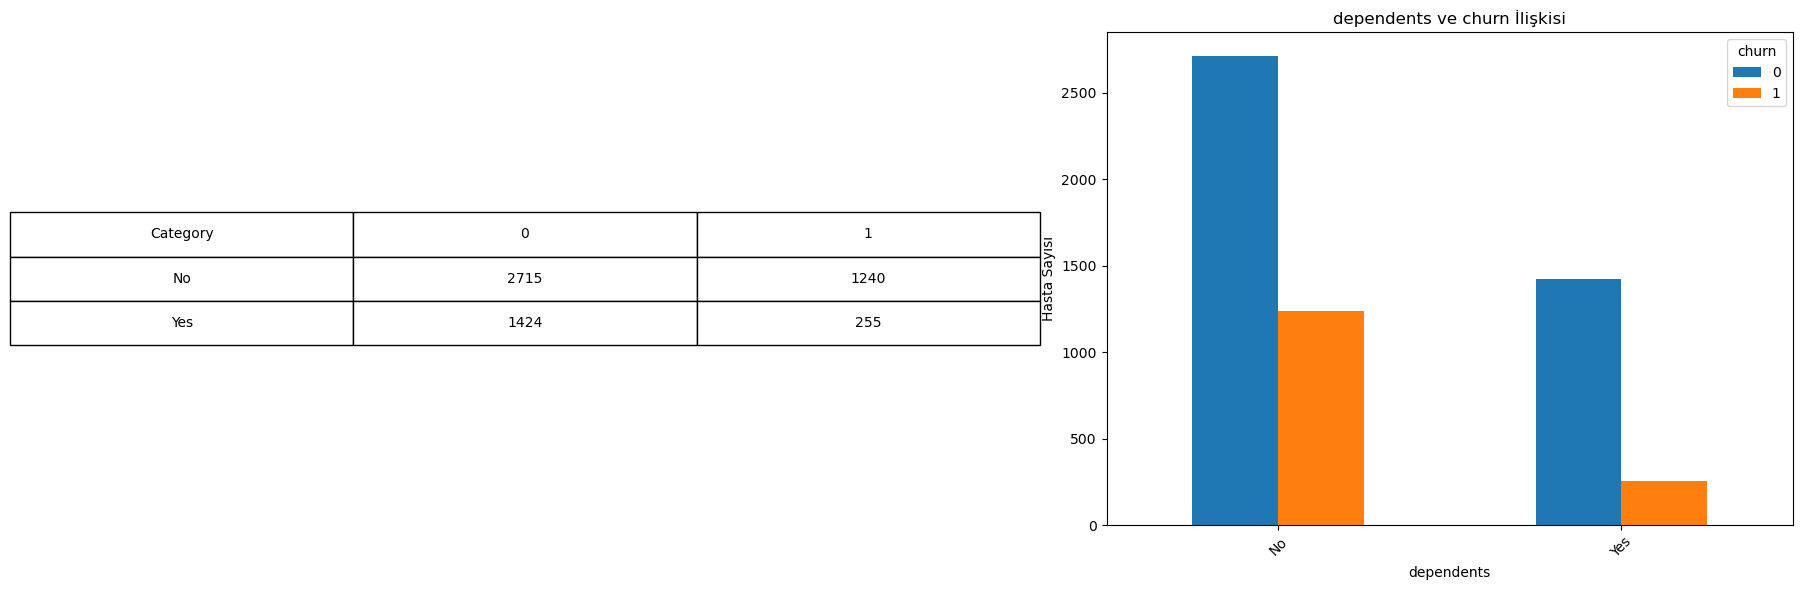

phoneservice ile churn İlişkisi


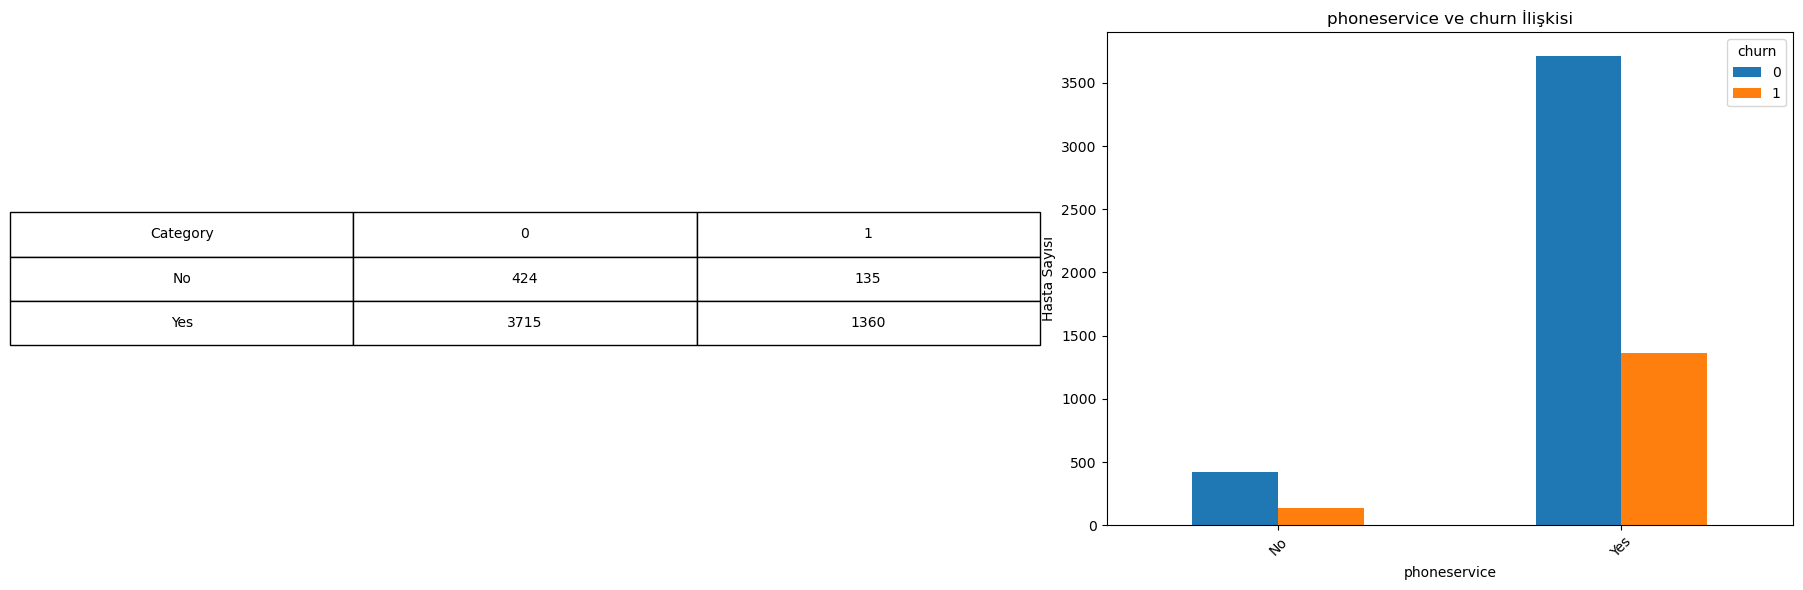

multiplelines ile churn İlişkisi


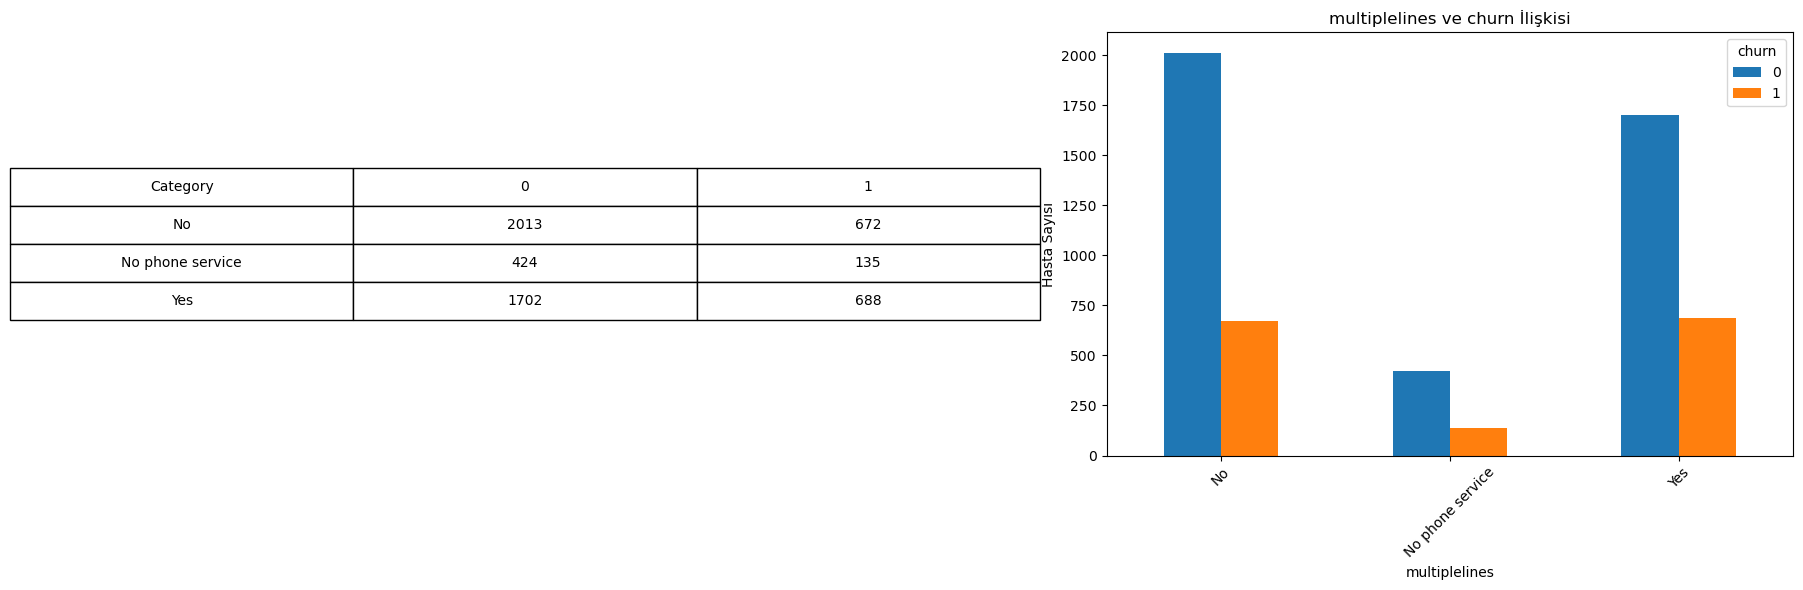

internetservice ile churn İlişkisi


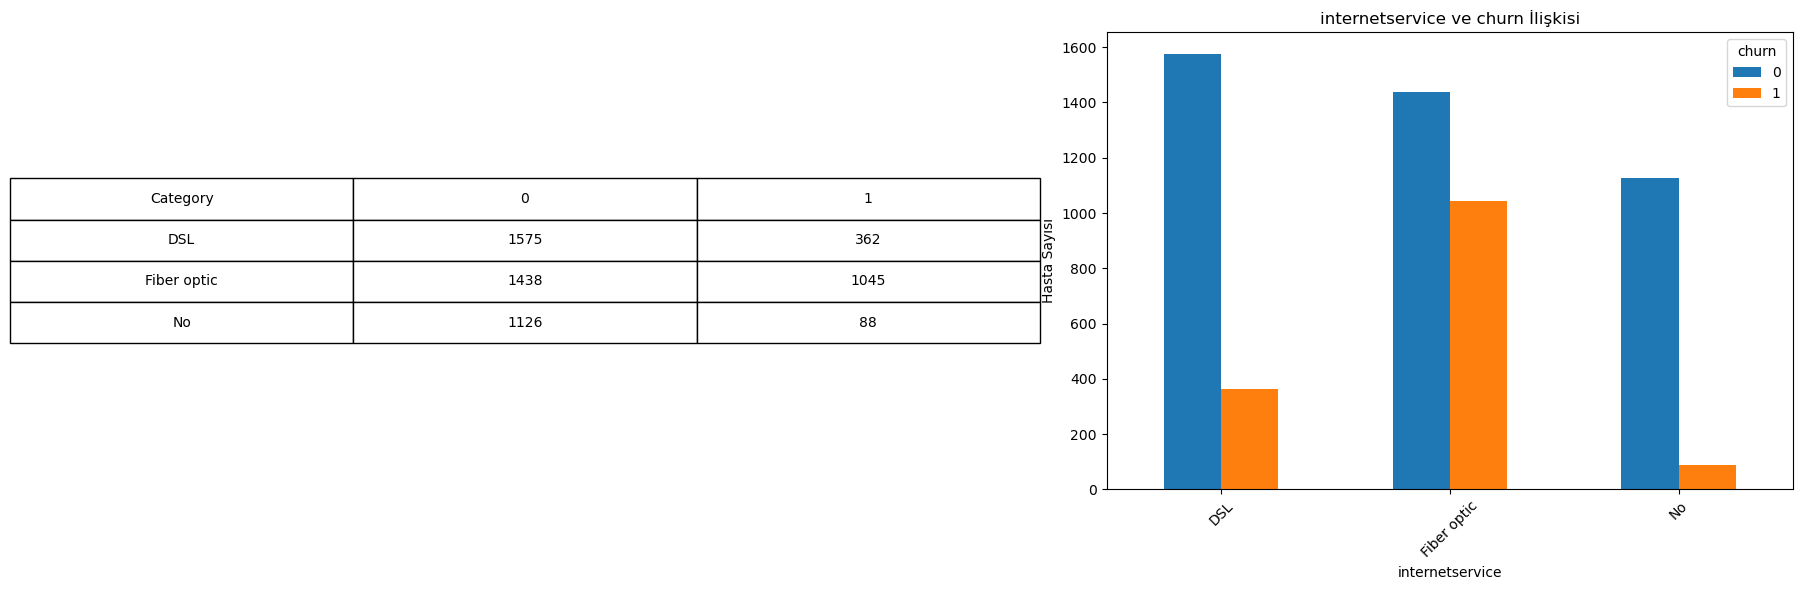

onlinesecurity ile churn İlişkisi


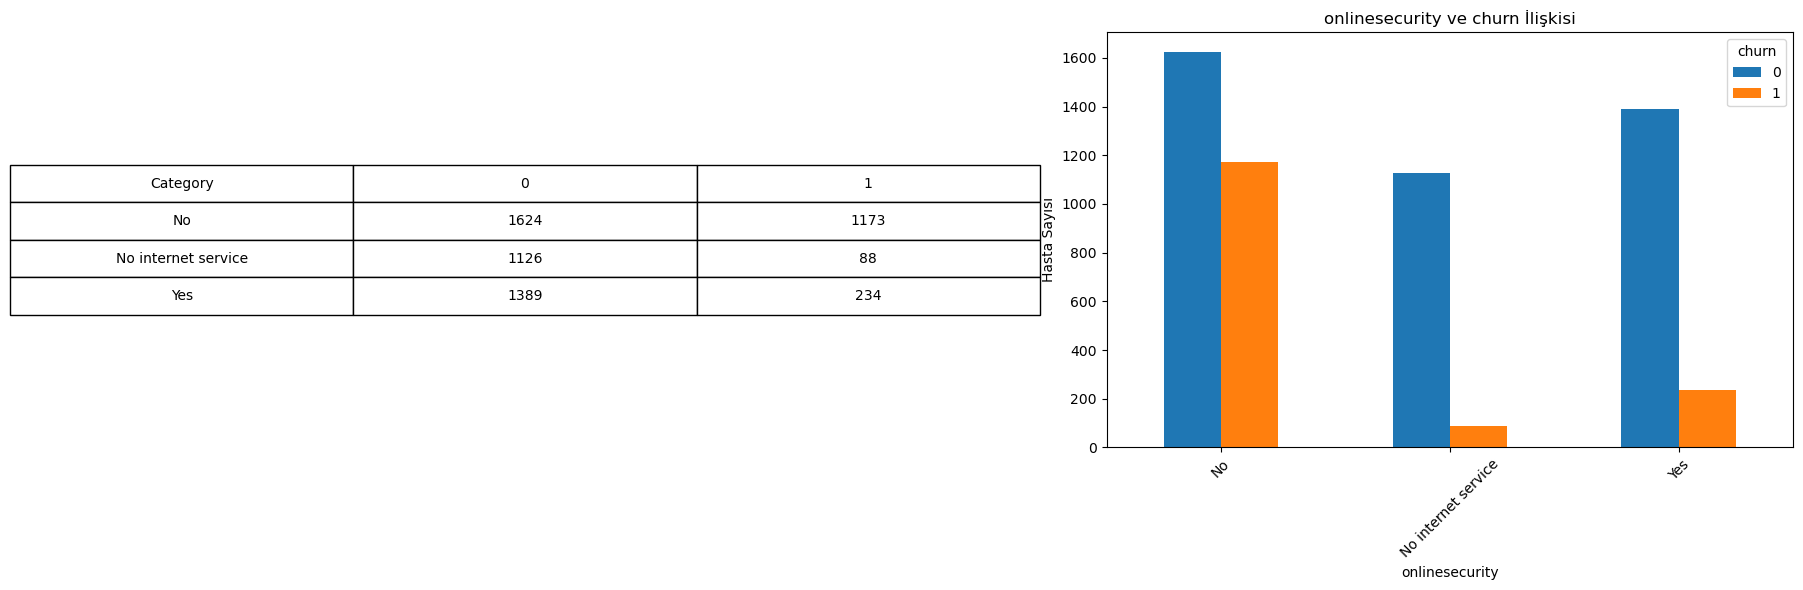

onlinebackup ile churn İlişkisi


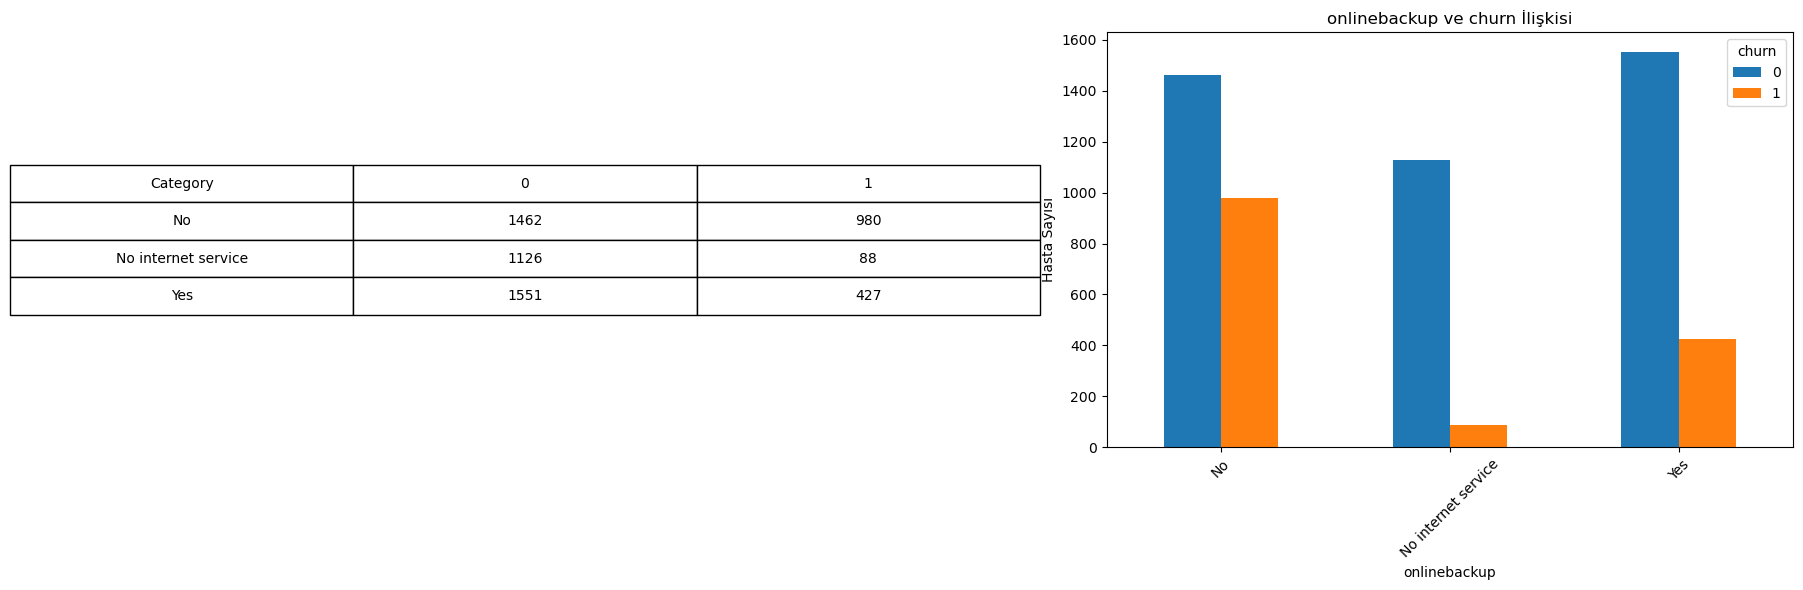

deviceprotection ile churn İlişkisi


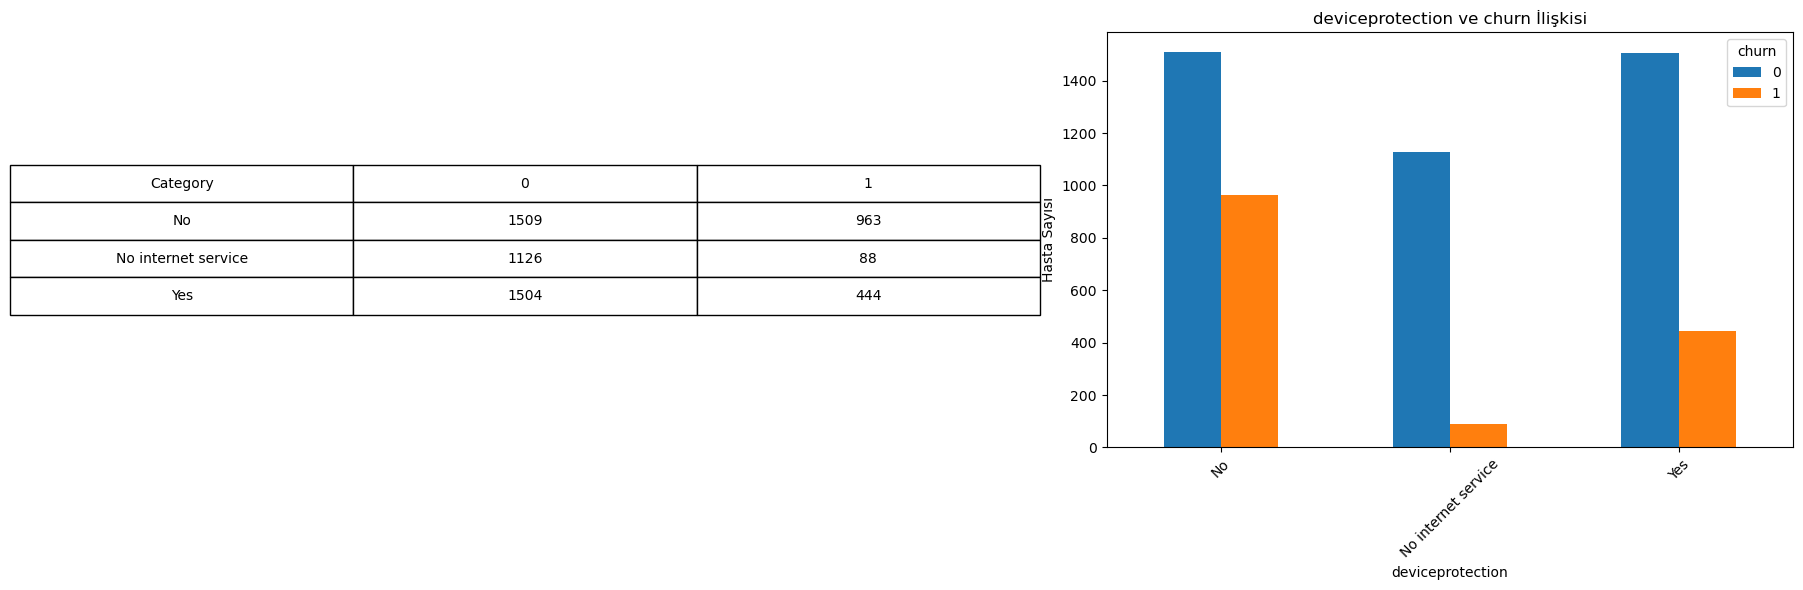

techsupport ile churn İlişkisi


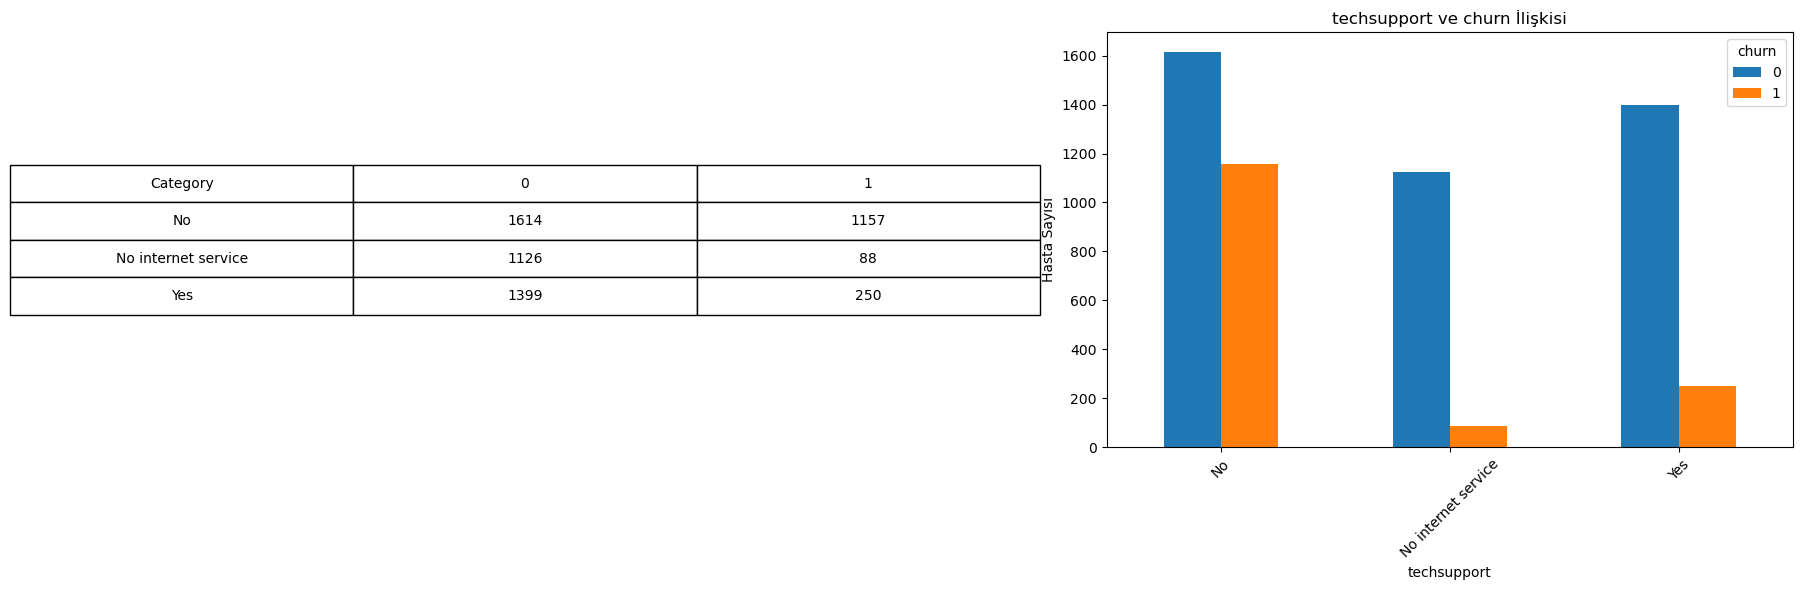

streamingtv ile churn İlişkisi


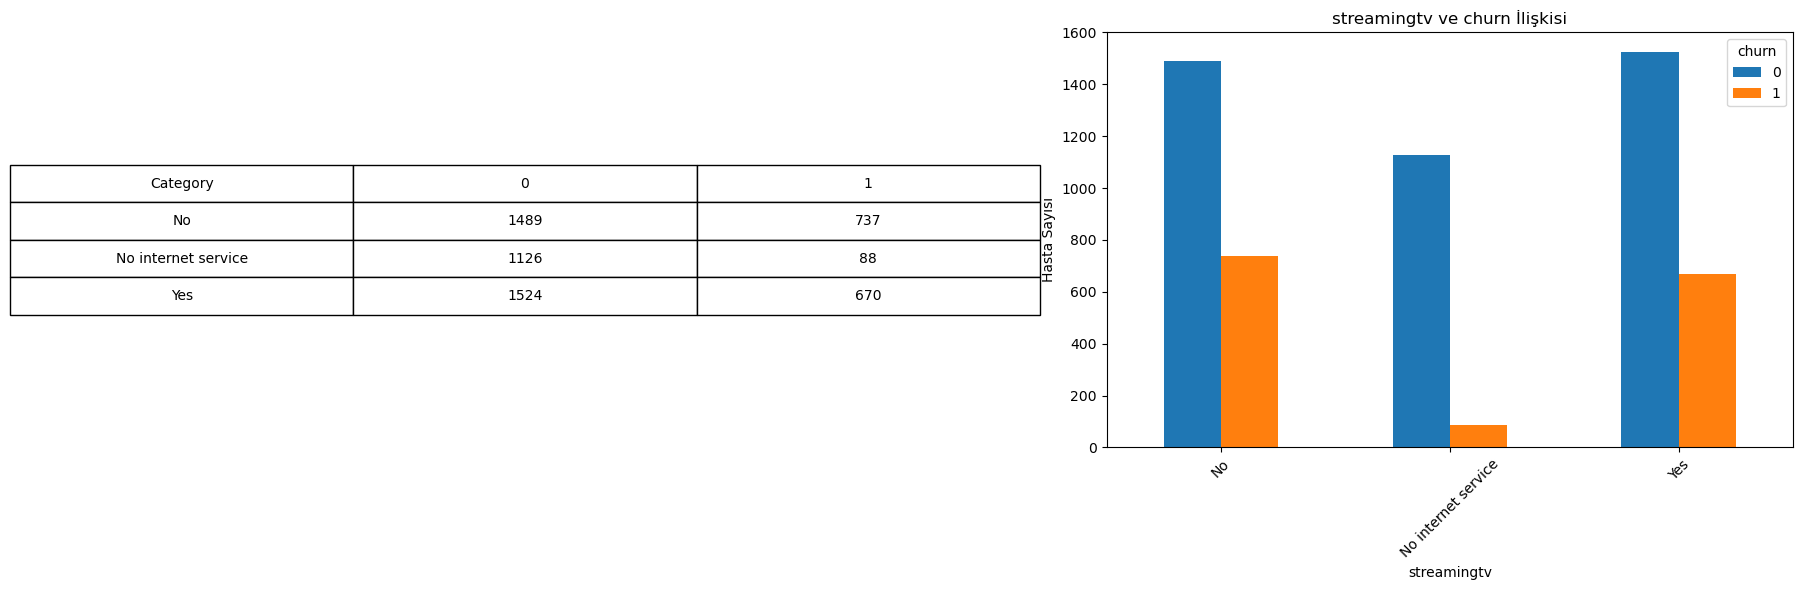

streamingmovies ile churn İlişkisi


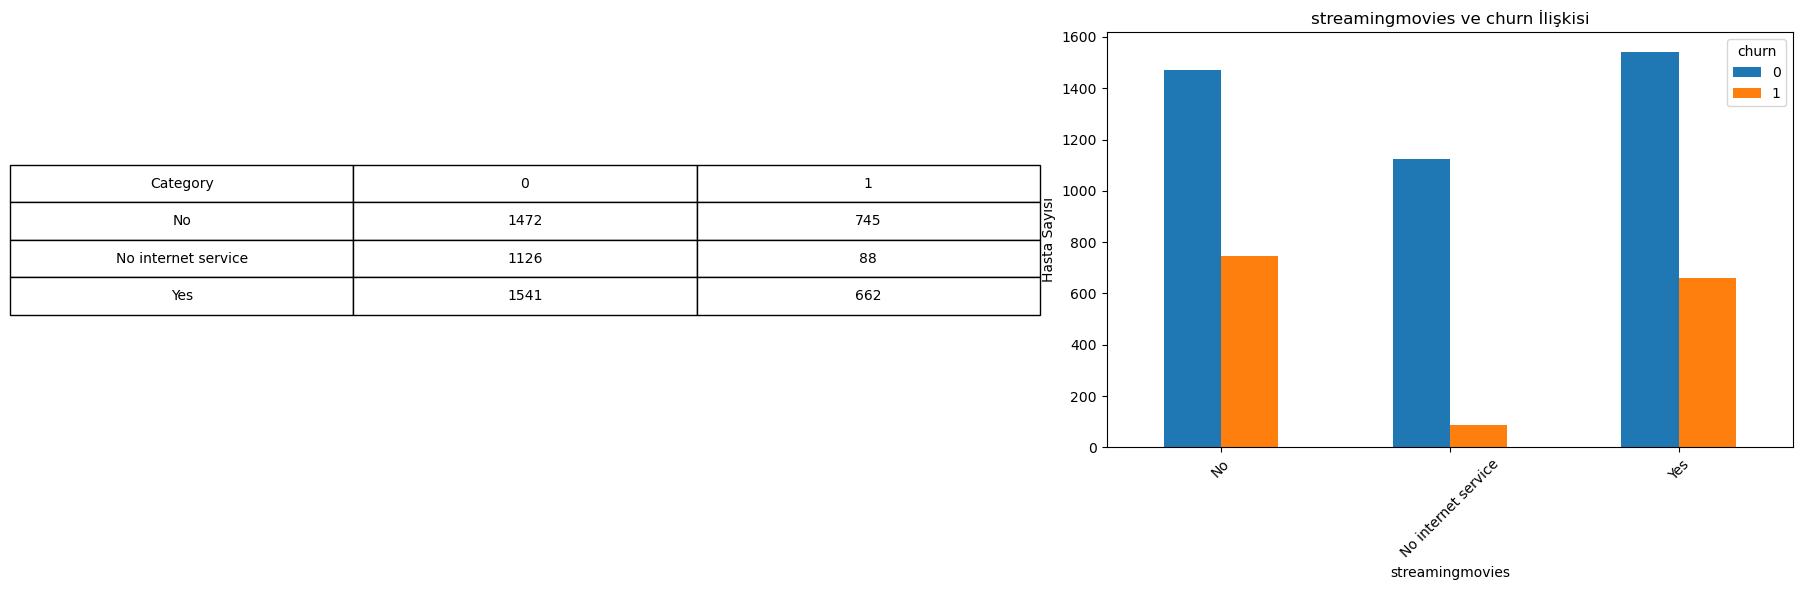

contract ile churn İlişkisi


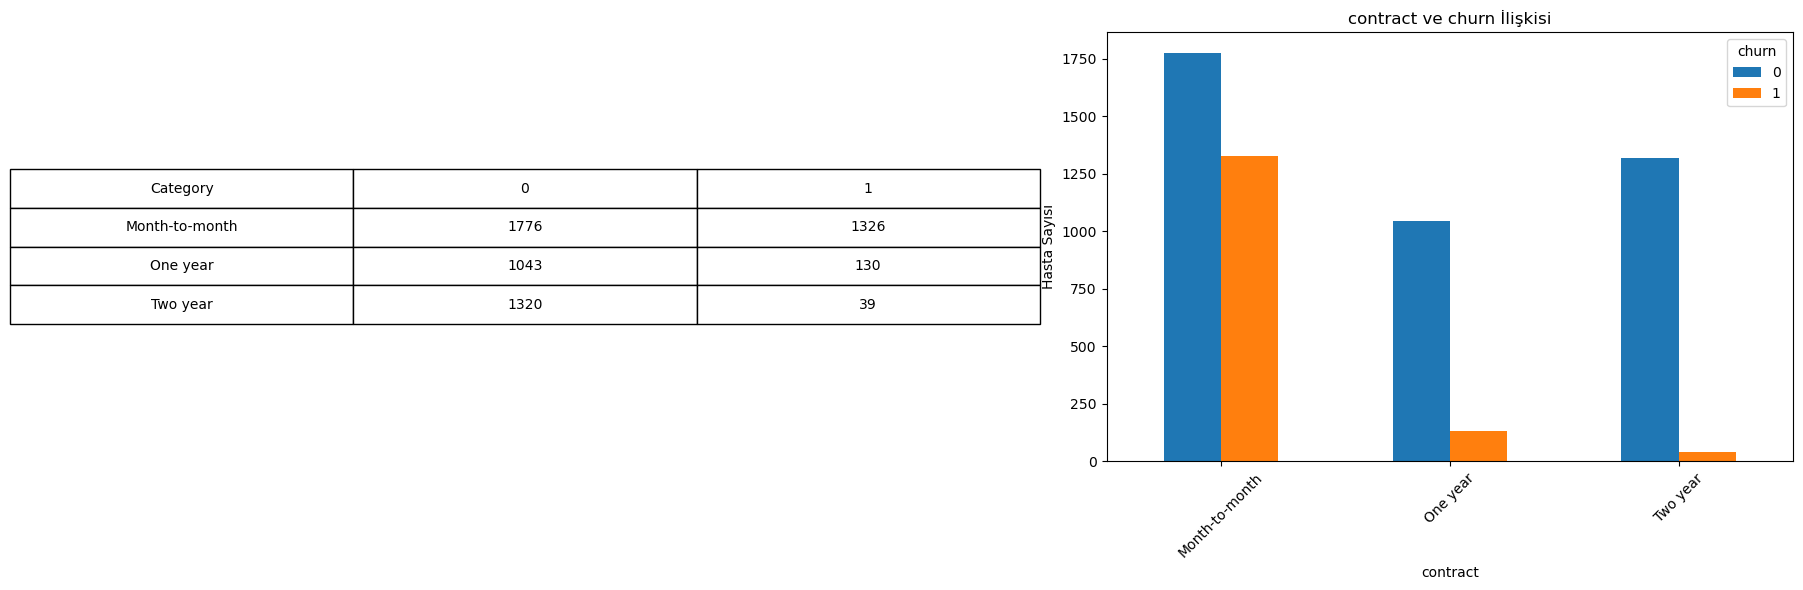

paperlessbilling ile churn İlişkisi


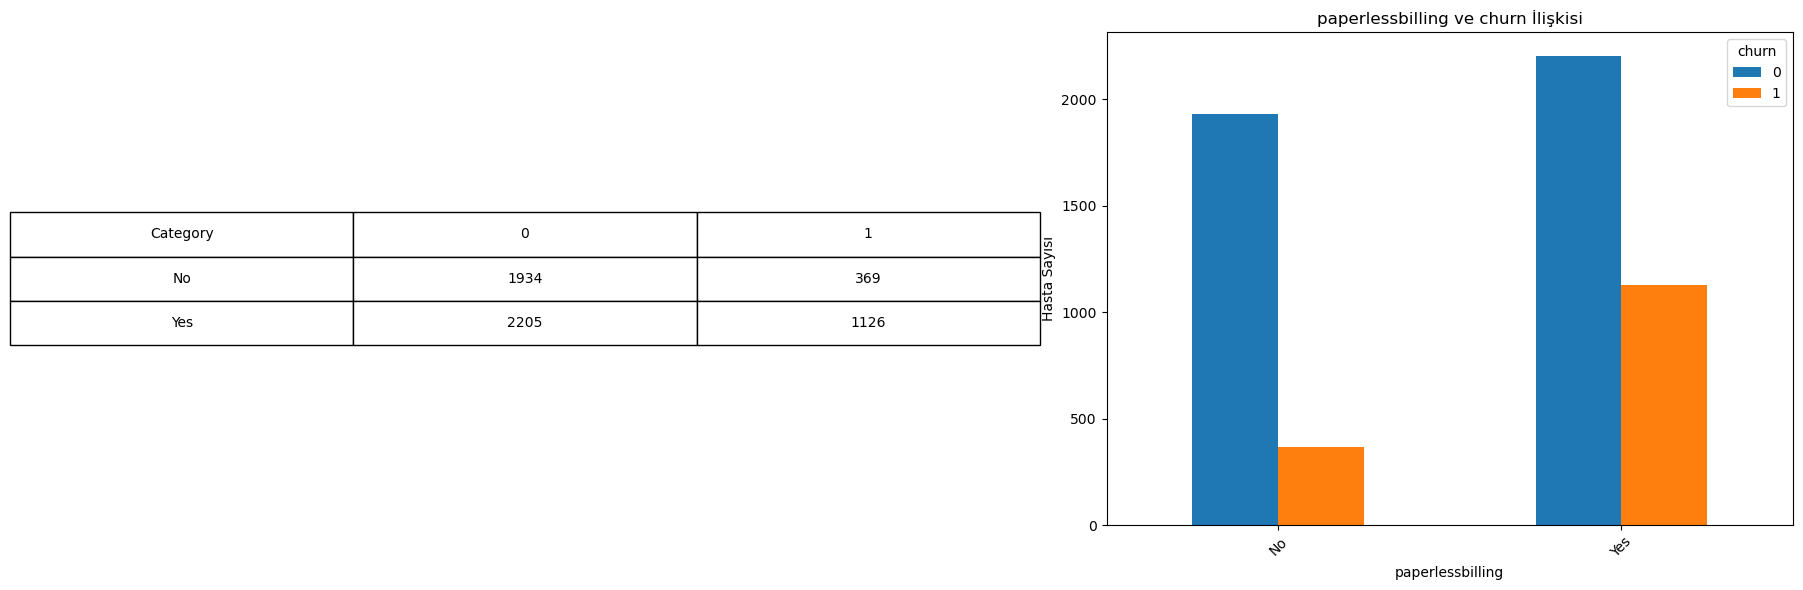

paymentmethod ile churn İlişkisi


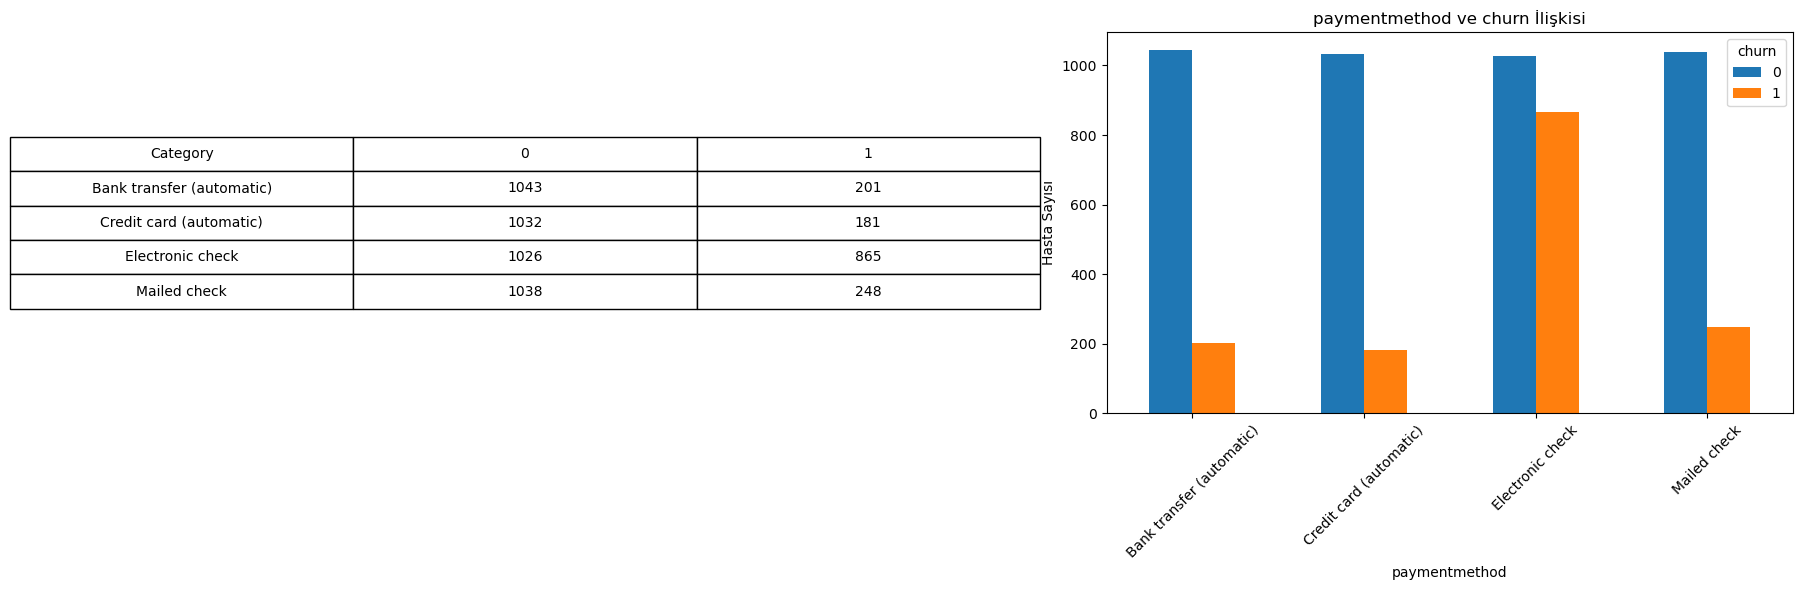

seniorcitizen ile churn İlişkisi


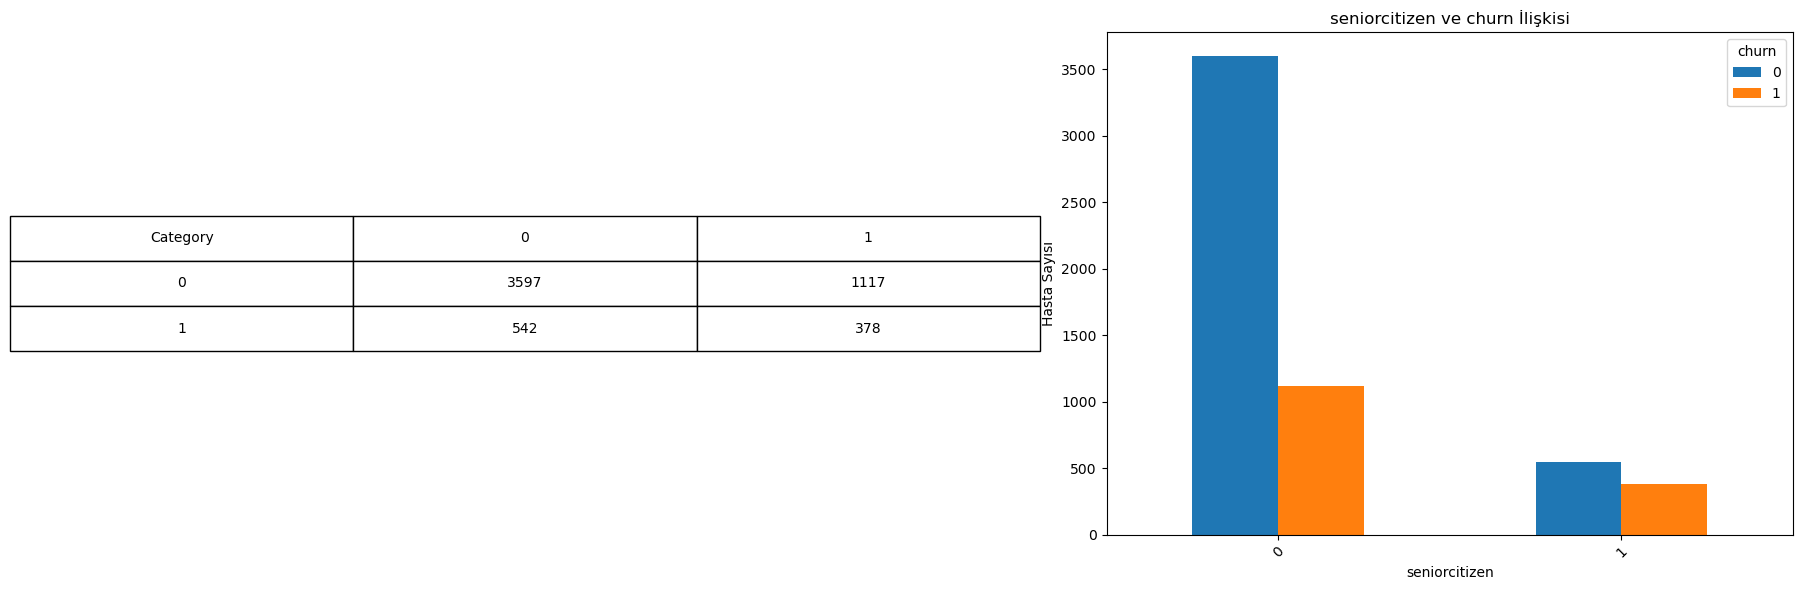

In [42]:
# Kategorik sütunların churn ile ilişkisini görselleştirme
for col in categorical_columns:
    if col != 'churn':
        print(f"{col} ile churn İlişkisi")
        cross_tab = pd.crosstab(data_train[col], data_train['churn'])

        # Yeni figür oluştur
        fig = plt.figure(figsize=(18, 6))

        # İlk sütun: Çapraz Tablo
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.axis('off')  # Eksenleri kapat
        table = plt.table(
            cellText=cross_tab.reset_index().values,
            colLabels=["Category"] + list(cross_tab.columns),
            loc='center',
            cellLoc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.5, 2.5)  # Tabloyu büyüt

        # İkinci sütun: Yığılmış Bar Grafiği
        ax2 = fig.add_subplot(1, 2, 2)
        cross_tab.plot(kind='bar', ax=ax2, color=['#1f77b4', '#ff7f0e'])
        ax2.set_title(f"{col} ve churn İlişkisi")
        ax2.set_ylabel("Hasta Sayısı")
        ax2.set_xlabel(col)
        plt.xticks(rotation=45)  # Etiketleri döndür

        plt.tight_layout()
        plt.show()

## Yorumlar

* Cinsiyetin müşteri kaybı (churn) üzerinde neredeyse hiçbir etkisi yoktur — erkek ve kadın oranları neredeyse aynıdır (~%26). Elde tutma (retention) stratejisinde cinsiyete verilen öncelik tamamen kaldırılmalıdır.
* Yaşlı vatandaşların kayıp oranı (~%41), yaşlı olmayanlara kıyasla (~%24) önemli ölçüde daha yüksektir. Yaşlılar, müşteri tabanının ~%16'sını oluşturmaktadır ancak orantısız bir şekilde risk altındaki bir grubu temsil etmektedir.
* Eşi/partneri olmayan müşteriler daha fazla ayrılıyor (~%33'e karşı ~%20) — yalnız yaşayan müşterilerin abonelikte kalmasını sağlayan hane içi eylemsizlik/bağlılık hissi daha düşüktür.
* Bakmakla yükümlü olduğu kimsesi (çocuğu vb.) olmayan müşteriler daha fazla ayrılıyor (~%31'e karşı ~%17) — çocuklu aileler daha istikrarlı, uzun vadeli aboneler olma eğilimindedir.
* Bunlar bir araya geldiğinde, hane büyüklüğü ve istikrarının, tek başına cinsiyet veya yaş gibi demografik özelliklere kıyasla daha güçlü tahminleyiciler olduğunu göstermektedir.

In [43]:
numerical_columns

['tenure', 'monthlycharges', 'totalcharges']

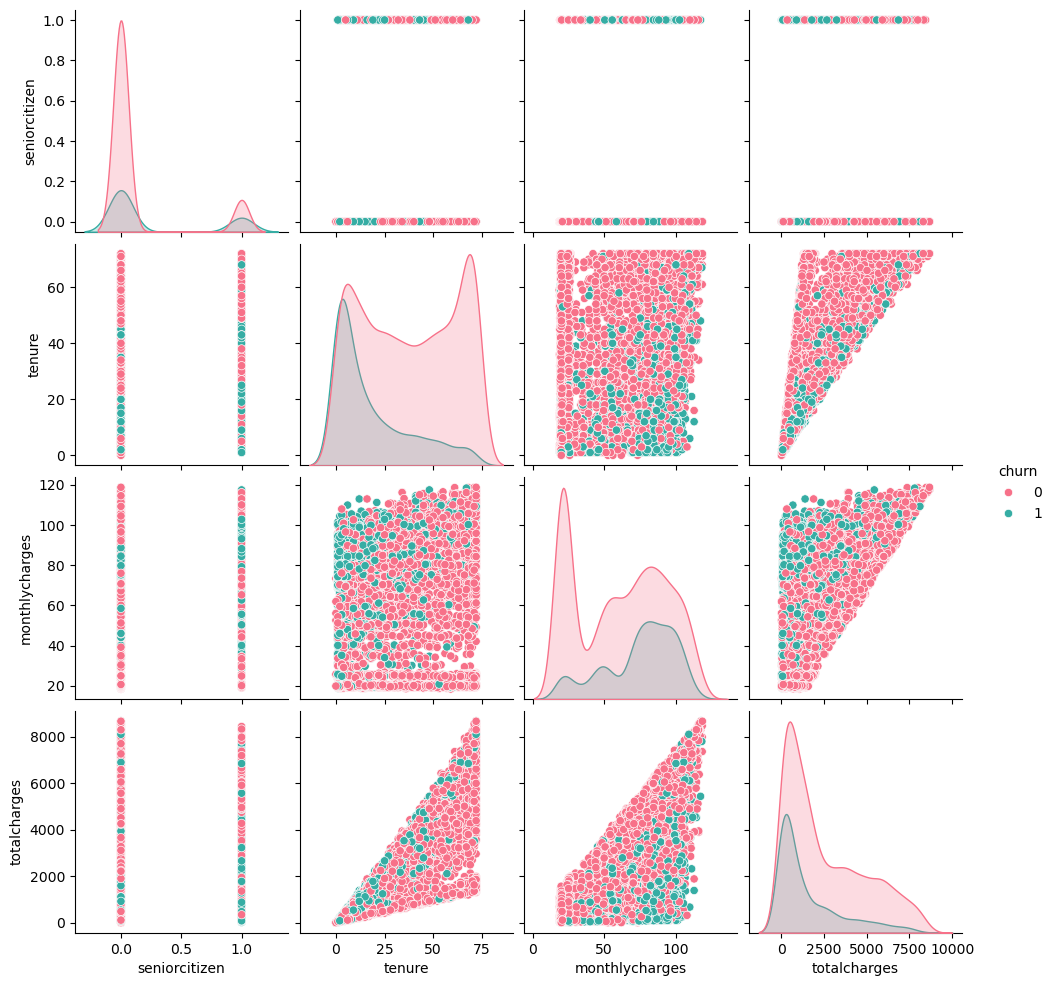

In [44]:
sns.pairplot(data=data_train[['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'churn']],
             hue='churn',  # Kategorik sütun adı
             palette='husl')  # Renk paleti
plt.show()

## Yorumlar

**`Köşegenlerdeki Dağılımlar:`** 
* `Tenure Dağılımı (2. satır, 2. sütun):` Yeni müşterilerde (Tenure 0-10 arası) yeşil (churn=1) yoğunluğu çok yüksek. Şirket, müşteriyi ilk kazandığı dönemde ciddi bir kayıp yaşıyor. Müşteri sistemde kaldıkça (Tenure 60-70 aylara geldikçe) pembe alan (churn=0) baskınlaşıyor. `Yani kritik eşik ilk aylar.`
* `MonthlyCharges Dağılımı (3. satır, 3. sütun):` Düşük aylık ücretlerde (20-30 civarı) pembe renk çok baskın, yani ucuz paket kullananlar kalıcı. Ancak 70 ile 100 arasındaki yüksek ücretlerde yeşil tepe noktası (churn) belirginleşiyor. Müşteriler fiyata duyarlı; fatura şiştikçe kaçma eğilimi artıyor.

**`İki Değişkenli İlişkiler:`** 
* `Tenure vs TotalCharges:` Grafikte net bir üçgen/kama yapısı görüyorsunuz. Bu, doğrusal (linear) bir ilişki olduğunu doğruluyor (korelasyondaki 0.83'lük değerin görsel hali). Dikkat ederseniz, bu grafiğin alt sınırında yeşiller (churn) yoğunlaşmış. Bu ne anlama geliyor? Aynı abonelik süresine (tenure) sahip iki kişiden, aylık faturası (ve dolayısıyla toplam faturası) daha yüksek olan hat boyunca yeşiller toplanmış.
* `Tenure vs MonthlyCharges:` Grafiğin sağ alt köşesi boş. Yani "hem uzun süredir müşteri olan (yüksek tenure) hem de çok düşük aylık ücret öyen" neredeyse kimse yok. Sol üst köşe ise yeşil noktalarla (churn) dolu. Yani abonelik süresi çok kısa (0-20 ay) ama aylık ücreti çok yüksek (80-120) olan neredeyse herkes erkenden churn olmuş.

## Aykırı Değerlerin İşlenmesi

In [45]:
# IQR yöntemiyle aykırı değer tespiti
outlier_summary = {}
for col in numerical_columns:
    Q1 = data_train[col].quantile(0.25)
    Q3 = data_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data_train[(data_train[col] < lower_bound) | (data_train[col] > upper_bound)]
    outlier_summary[col] = {
        'Aykırı Değer Sayısı': len(outliers),
        'Alt Sınır': lower_bound,
        'Üst Sınır': upper_bound}

# Aykırı değer özetini bir DataFrame olarak düzenleme
outlier_df = pd.DataFrame(outlier_summary).T
outlier_df.reset_index(inplace=True)
outlier_df.rename(columns={'index': 'Sütun'}, inplace=True)

outlier_df

,Sütun,Aykırı Değer Sayısı,Alt Sınır,Üst Sınır
0,tenure,0.0,-60.00000,124.00000
1,monthlycharges,0.0,-45.84375,171.50625
2,totalcharges,0.0,-4746.30000,8985.10000


* Verimizde aykırı değer bulunmamaktadır.

## Data Preparation

## Encoding İşlemi

In [46]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   seniorcitizen     5634 non-null   int64  
 2   partner           5634 non-null   object 
 3   dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   phoneservice      5634 non-null   object 
 6   multiplelines     5634 non-null   object 
 7   internetservice   5634 non-null   object 
 8   onlinesecurity    5634 non-null   object 
 9   onlinebackup      5634 non-null   object 
 10  deviceprotection  5634 non-null   object 
 11  techsupport       5634 non-null   object 
 12  streamingtv       5634 non-null   object 
 13  streamingmovies   5634 non-null   object 
 14  contract          5634 non-null   object 
 15  paperlessbilling  5634 non-null   object 
 16  paymentmethod     5634 non-null   object 


In [47]:
data_train['gender'].value_counts()

gender
Male      2833
Female    2801
Name: count, dtype: int64

In [48]:
data_train['gender']=data_train['gender'].replace({'Male': 0 , 'Female' : 1})

In [49]:
data_train['partner'].value_counts()

partner
No     2905
Yes    2729
Name: count, dtype: int64

In [50]:
data_train['partner']=data_train['partner'].replace({'No':0, 'Yes':1})

In [51]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   int64  
 1   seniorcitizen     5634 non-null   int64  
 2   partner           5634 non-null   int64  
 3   dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   phoneservice      5634 non-null   object 
 6   multiplelines     5634 non-null   object 
 7   internetservice   5634 non-null   object 
 8   onlinesecurity    5634 non-null   object 
 9   onlinebackup      5634 non-null   object 
 10  deviceprotection  5634 non-null   object 
 11  techsupport       5634 non-null   object 
 12  streamingtv       5634 non-null   object 
 13  streamingmovies   5634 non-null   object 
 14  contract          5634 non-null   object 
 15  paperlessbilling  5634 non-null   object 
 16  paymentmethod     5634 non-null   object 


In [52]:
columns=['dependents', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', ]

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
encoder=LabelEncoder()

In [55]:
for col in columns:
    data_train[col]=encoder.fit_transform(data_train[col])

In [56]:
data_train.sample(5)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
4370,1,0,0,0,15,1,0,1,2,0,2,2,2,2,0,0,2,105.10,1582.75,1
2232,1,0,0,0,2,1,0,1,0,0,0,0,2,0,0,1,2,79.75,164.50,1
4801,1,1,1,0,56,1,2,1,2,2,2,2,0,0,1,0,2,95.65,5471.75,0
2444,1,0,0,0,20,1,0,2,1,1,1,1,1,1,1,1,1,19.35,433.75,0
1467,0,1,0,0,37,0,1,0,0,2,2,0,0,0,0,0,2,36.65,1315.00,0


In [57]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   int64  
 1   seniorcitizen     5634 non-null   int64  
 2   partner           5634 non-null   int64  
 3   dependents        5634 non-null   int32  
 4   tenure            5634 non-null   int64  
 5   phoneservice      5634 non-null   int32  
 6   multiplelines     5634 non-null   int32  
 7   internetservice   5634 non-null   int32  
 8   onlinesecurity    5634 non-null   int32  
 9   onlinebackup      5634 non-null   int32  
 10  deviceprotection  5634 non-null   int32  
 11  techsupport       5634 non-null   int32  
 12  streamingtv       5634 non-null   int32  
 13  streamingmovies   5634 non-null   int32  
 14  contract          5634 non-null   int32  
 15  paperlessbilling  5634 non-null   int32  
 16  paymentmethod     5634 non-null   int32  


## Test Verisini Hazırlama

In [58]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   seniorcitizen     1409 non-null   int64  
 3   partner           1409 non-null   object 
 4   dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   phoneservice      1409 non-null   object 
 7   multiplelines     1409 non-null   object 
 8   internetservice   1409 non-null   object 
 9   onlinesecurity    1409 non-null   object 
 10  onlinebackup      1409 non-null   object 
 11  deviceprotection  1409 non-null   object 
 12  techsupport       1409 non-null   object 
 13  streamingtv       1409 non-null   object 
 14  streamingmovies   1409 non-null   object 
 15  contract          1409 non-null   object 
 16  paperlessbilling  1409 non-null   object 


In [59]:
data_test = data_test.drop(columns=["customerid"])

In [60]:
data_test.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
1,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
3,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
4,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35


In [61]:
# Sütunları kategorik ve sayısal olarak kategorilere ayırma

test_numerical_columns = []
test_categorical_columns = []
for i in data_test.columns:
    if data_test[i].dtype == 'object':
        test_categorical_columns.append(i)
    else:
        test_numerical_columns.append(i)

# Churn ve SeniorCitizen'ı sayısal listeden çıkarıp kategorik listeye taşıyoruz. Çünkü binary değerlerden oluşuyorlar.
explicit_categorical = ['seniorcitizen']

for col in explicit_categorical:
    if col in test_numerical_columns:
        test_numerical_columns.remove(col)
    if col not in test_categorical_columns:
        test_categorical_columns.append(col)

In [62]:
test_numerical_columns

['tenure', 'monthlycharges', 'totalcharges']

In [63]:
# sayısal değişkenlerin dağılımı
data_test.describe().T

,count,mean,std,min,25%,50%,75%,max
seniorcitizen,1409.0,0.157559,0.364456,0.00,0.0,0.00,0.00,1.0
tenure,1409.0,31.915543,24.525829,0.00,8.0,28.00,55.00,72.0
monthlycharges,1409.0,64.088857,29.898290,18.25,35.2,69.95,89.45,116.8
totalcharges,1409.0,2201.360610,2215.541146,0.00,360.1,1394.55,3517.90,8496.7


In [64]:
test_categorical_columns

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'seniorcitizen']

In [65]:
# kategorik değişkenlerin dağılımı
data_test.describe(include="O").T

,count,unique,top,freq
gender,1409,2,Male,722
partner,1409,2,No,736
dependents,1409,2,No,978
phoneservice,1409,2,Yes,1286
multiplelines,1409,3,No,705
internetservice,1409,3,Fiber optic,613
onlinesecurity,1409,3,No,701
onlinebackup,1409,3,No,646
deviceprotection,1409,3,No,623
techsupport,1409,3,No,702


In [66]:
# IQR yöntemiyle aykırı değer tespiti
test_outlier_summary = {}
for col in test_numerical_columns:
    Q1 = data_test[col].quantile(0.25)
    Q3 = data_test[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data_test[(data_test[col] < lower_bound) | (data_test[col] > upper_bound)]
    test_outlier_summary[col] = {
        'Aykırı Değer Sayısı': len(outliers),
        'Alt Sınır': lower_bound,
        'Üst Sınır': upper_bound}

# Aykırı değer özetini bir DataFrame olarak düzenleme
outlier_df_test = pd.DataFrame(test_outlier_summary).T
outlier_df_test.reset_index(inplace=True)
outlier_df_test.rename(columns={'index': 'Sütun'}, inplace=True)

outlier_df_test

,Sütun,Aykırı Değer Sayısı,Alt Sınır,Üst Sınır
0,tenure,0.0,-62.500,125.500
1,monthlycharges,0.0,-46.175,170.825
2,totalcharges,7.0,-4376.600,8254.600


## Data Preparation

## Encoding İşlemi

In [67]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1409 non-null   object 
 1   seniorcitizen     1409 non-null   int64  
 2   partner           1409 non-null   object 
 3   dependents        1409 non-null   object 
 4   tenure            1409 non-null   int64  
 5   phoneservice      1409 non-null   object 
 6   multiplelines     1409 non-null   object 
 7   internetservice   1409 non-null   object 
 8   onlinesecurity    1409 non-null   object 
 9   onlinebackup      1409 non-null   object 
 10  deviceprotection  1409 non-null   object 
 11  techsupport       1409 non-null   object 
 12  streamingtv       1409 non-null   object 
 13  streamingmovies   1409 non-null   object 
 14  contract          1409 non-null   object 
 15  paperlessbilling  1409 non-null   object 
 16  paymentmethod     1409 non-null   object 


In [68]:
data_test['gender'].value_counts()

gender
Male      722
Female    687
Name: count, dtype: int64

In [69]:
data_test['gender']=data_test['gender'].replace({'Male': 0 , 'Female' : 1})

In [70]:
data_test['partner'].value_counts()

partner
No     736
Yes    673
Name: count, dtype: int64

In [71]:
data_test['partner']=data_test['partner'].replace({'No':0, 'Yes':1})

In [72]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1409 non-null   int64  
 1   seniorcitizen     1409 non-null   int64  
 2   partner           1409 non-null   int64  
 3   dependents        1409 non-null   object 
 4   tenure            1409 non-null   int64  
 5   phoneservice      1409 non-null   object 
 6   multiplelines     1409 non-null   object 
 7   internetservice   1409 non-null   object 
 8   onlinesecurity    1409 non-null   object 
 9   onlinebackup      1409 non-null   object 
 10  deviceprotection  1409 non-null   object 
 11  techsupport       1409 non-null   object 
 12  streamingtv       1409 non-null   object 
 13  streamingmovies   1409 non-null   object 
 14  contract          1409 non-null   object 
 15  paperlessbilling  1409 non-null   object 
 16  paymentmethod     1409 non-null   object 


In [73]:
columns_test=['dependents', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', ]

In [74]:
from sklearn.preprocessing import LabelEncoder

In [75]:
encoder=LabelEncoder()

In [76]:
for col in columns_test:
    data_test[col]=encoder.fit_transform(data_test[col])

In [77]:
data_test.sample(5)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
1093,0,1,1,0,36,1,2,1,0,0,0,0,0,2,0,1,2,84.1,3021.60
968,1,0,1,0,71,1,2,2,1,1,1,1,1,1,2,0,1,25.6,1888.25
54,1,0,0,1,1,1,0,0,2,0,0,0,0,0,0,0,3,51.2,51.20
1333,1,0,0,0,1,1,0,1,2,0,0,0,0,0,0,0,3,75.3,75.30
303,0,0,1,0,63,1,0,0,2,2,0,2,2,0,1,0,1,70.8,4448.80


In [78]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1409 non-null   int64  
 1   seniorcitizen     1409 non-null   int64  
 2   partner           1409 non-null   int64  
 3   dependents        1409 non-null   int32  
 4   tenure            1409 non-null   int64  
 5   phoneservice      1409 non-null   int32  
 6   multiplelines     1409 non-null   int32  
 7   internetservice   1409 non-null   int32  
 8   onlinesecurity    1409 non-null   int32  
 9   onlinebackup      1409 non-null   int32  
 10  deviceprotection  1409 non-null   int32  
 11  techsupport       1409 non-null   int32  
 12  streamingtv       1409 non-null   int32  
 13  streamingmovies   1409 non-null   int32  
 14  contract          1409 non-null   int32  
 15  paperlessbilling  1409 non-null   int32  
 16  paymentmethod     1409 non-null   int32  


## Veriyi Ayırma İşlemi

In [79]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1409 non-null   int64  
 1   seniorcitizen     1409 non-null   int64  
 2   partner           1409 non-null   int64  
 3   dependents        1409 non-null   int32  
 4   tenure            1409 non-null   int64  
 5   phoneservice      1409 non-null   int32  
 6   multiplelines     1409 non-null   int32  
 7   internetservice   1409 non-null   int32  
 8   onlinesecurity    1409 non-null   int32  
 9   onlinebackup      1409 non-null   int32  
 10  deviceprotection  1409 non-null   int32  
 11  techsupport       1409 non-null   int32  
 12  streamingtv       1409 non-null   int32  
 13  streamingmovies   1409 non-null   int32  
 14  contract          1409 non-null   int32  
 15  paperlessbilling  1409 non-null   int32  
 16  paymentmethod     1409 non-null   int32  


In [80]:
# Train verisini ayırma
X_train = data_train.drop(columns=['churn'], errors='ignore')
y_train = data_train['churn']

# Test verisini ayırma
X_test = data_test.copy()

# Gelişmiş Özellik Mühendisliği (Advanced Feature Engineering)
def add_features(X, df_raw):
    X = X.copy()
    
    # 1. Toplam alınan servis sayısı
    services = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies']
    X['total_services'] = df_raw[services].apply(lambda row: sum(row == 'Yes'), axis=1)
    
    # 2. Servis sahipliği olmayan kritik alanlar (Churn ile yüksek korelasyonlu)
    X['no_tech_support'] = (df_raw['techsupport'] == 'No').astype(int)
    X['no_online_security'] = (df_raw['onlinesecurity'] == 'No').astype(int)
    X['no_online_backup'] = (df_raw['onlinebackup'] == 'No').astype(int)
    X['no_device_protection'] = (df_raw['deviceprotection'] == 'No').astype(int)
    
    # 3. İnternet servis türü one-hot temsili
    X['is_fiber'] = (df_raw['internetservice'] == 'Fiber optic').astype(int)
    X['is_dsl'] = (df_raw['internetservice'] == 'DSL').astype(int)
    X['no_internet'] = (df_raw['internetservice'] == 'No').astype(int)
    
    # 4. Ödeme yöntemi one-hot temsili ve otomatik ödeme kontrolü
    X['is_electronic_check'] = (df_raw['paymentmethod'] == 'Electronic check').astype(int)
    X['is_mailed_check'] = (df_raw['paymentmethod'] == 'Mailed check').astype(int)
    X['is_credit_card'] = (df_raw['paymentmethod'] == 'Credit card (automatic)').astype(int)
    X['is_bank_transfer'] = (df_raw['paymentmethod'] == 'Bank transfer (automatic)').astype(int)
    X['is_auto_payment'] = df_raw['paymentmethod'].isin(['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)
    
    # 5. Sözleşme one-hot temsili ve ağırlıklandırma
    X['is_month_to_month'] = (df_raw['contract'] == 'Month-to-month').astype(int)
    X['is_one_year'] = (df_raw['contract'] == 'One year').astype(int)
    X['is_two_year'] = (df_raw['contract'] == 'Two year').astype(int)
    X['contract_weight'] = df_raw['contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24}).fillna(1)
    
    # 6. Demografik kombinasyonlar
    X['single_no_dependents'] = ((df_raw['partner'] == 'No') & (df_raw['dependents'] == 'No')).astype(int)
    X['has_family'] = ((df_raw['partner'] == 'Yes') | (df_raw['dependents'] == 'Yes')).astype(int)
    
    # 7. Finansal oranlar ve farklar
    X['avg_charges_per_month'] = X['totalcharges'] / (X['tenure'] + 1)
    X['monthly_to_total_ratio'] = X['monthlycharges'] / (X['totalcharges'] + 1)
    X['charges_difference'] = X['monthlycharges'] - X['avg_charges_per_month']
    X['total_charges_per_service'] = X['totalcharges'] / (X['total_services'] + 1)
    
    # 8. Tenure kırılımları ve gruplandırma
    X['tenure_below_6'] = (X['tenure'] < 6).astype(int)
    X['tenure_below_12'] = (X['tenure'] < 12).astype(int)
    X['tenure_group'] = X['tenure'].apply(lambda t: 0 if t <= 12 else (1 if t <= 24 else (2 if t <= 48 else 3)))
    
    # 9. Aktif streaming servis sayısı
    X['streaming_count'] = df_raw[['streamingtv', 'streamingmovies']].apply(lambda row: sum(row == 'Yes'), axis=1)
    
    # 10. Güçlü churn etkileşim terimleri (Interaction terms)
    X['month_to_month_short_tenure'] = ((df_raw['contract'] == 'Month-to-month') & (X['tenure'] < 12)).astype(int)
    X['high_charges_month_to_month'] = ((df_raw['contract'] == 'Month-to-month') & (X['monthlycharges'] > 70)).astype(int)
    X['fiber_no_support'] = ((df_raw['internetservice'] == 'Fiber optic') & (df_raw['techsupport'] == 'No')).astype(int)
    X['is_phone_only'] = ((df_raw['phoneservice'] == 'Yes') & (df_raw['internetservice'] == 'No')).astype(int)
    
    return X

# Yeni özellikleri orijinal ham veri çerçevelerini (df_train ve df_test) referans alarak ekliyoruz
X_train = add_features(X_train, df_train)
X_test = add_features(X_test, df_test)


In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Özellik Ölçeklendirme (Scaling)
scaler = StandardScaler()
# Yeni eklenen tüm sayısal özellikleri de ölçeklendirme listesine dahil ediyoruz
scale_cols = ['tenure', 'monthlycharges', 'totalcharges', 'avg_charges_per_month', 'monthly_to_total_ratio', 'charges_difference', 'total_charges_per_service', 'total_services', 'streaming_count']

# Train ile öğrenip uyguluyoruz, Test'e sadece uyguluyoruz
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# 2. Modeli Tanımlama ve Eğitme
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

# 3. Churn Tahminlerini ve Olasılıklarını Üretme
predictions = log_model.predict(X_test)
probabilities = log_model.predict_proba(X_test)[:, 1]

# 4. Sonuçları Bir Araya Getirme ve İnceleme
submission = pd.DataFrame({
    'churn_prediction': predictions,
    'churn_probability': probabilities
})

# İlk 10 tahmini ekranda görelim
submission.head(10)


,churn_prediction,churn_probability
0,0,0.045875
1,1,0.633668
2,0,0.065399
3,0,0.312376
4,0,0.028763
5,1,0.578043
6,0,0.425663
7,0,0.136591
8,0,0.004742
9,0,0.303336


In [82]:
from sklearn.model_selection import train_test_split as original_train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import sklearn.model_selection

# Değişken tanımı yama öncesi NameError vermemesi için önceden tanımlanıyor
X_resampled_scaled = None

# 1. ORİJİNAL veriyi sızıntısız bölüyoruz (Validation setini tamamen bağımsız ve temiz tutuyoruz)
X_train_part_raw, X_val_raw, y_train_part_correct, y_val_correct = original_train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 2. Ölçeklendirmeyi sızıntısız yapıyoruz: fit işlemini sadece eğitim verisinde uyguluyoruz
scaler = StandardScaler()
X_train_part_scaled_raw = scaler.fit_transform(X_train_part_raw)
X_val_scaled_raw = scaler.transform(X_val_raw)

# Kaggle test verisini de aynı ölçeklendiriciyle dönüştürüyoruz
X_test_scaled = scaler.transform(X_test)

# 3. SMOTE işlemini YALNIZCA eğitim parçasına uyguluyoruz! Doğrulama seti orijinal kalıyor.
smote = SMOTE(random_state=42)
X_train_part_resampled, y_train_part_correct = smote.fit_resample(X_train_part_scaled_raw, y_train_part_correct)

# Uyumlu değişkenleri küresel olarak tanımlıyoruz
X_train_part_correct = X_train_part_resampled
X_val_correct = X_val_scaled_raw

# Modellerin sonundaki cross validation ve veri takibi için yedek değişkenleri güncelliyoruz
X_resampled = X_train_part_correct
y_resampled = y_train_part_correct

# 4. Diğer tüm hücrelerdeki train_test_split çağrılarını sızıntısız bölüme yönlendirecek "Monkey Patch" yamasını uyguluyoruz
def custom_train_test_split(*arrays, **options):
    if len(arrays) == 2 and arrays[0] is X_resampled_scaled and arrays[1] is y_resampled:
        return X_train_part_correct, X_val_correct, y_train_part_correct, y_val_correct
    return original_train_test_split(*arrays, **options)

sklearn.model_selection.train_test_split = custom_train_test_split


In [83]:
X_train.shape

(5634, 50)

In [84]:
y_train.shape

(5634,)

In [85]:
X_test.shape

(1409, 50)

In [86]:
y_resampled.shape

(6600,)

In [87]:
X_resampled.shape

(6600, 50)

In [88]:
# Veri sızıntısını önlemek amacıyla, fit_transform ve SMOTE işlemlerini Hücre 100'de güvenli şekilde tamamladık.
# Modellerin uyumluluğu için değişken eşleşmelerini yapıyoruz:
X_resampled_scaled = X_train_part_correct


In [89]:
X_resampled_scaled

array([[-0.99138391,  2.30484814,  1.03133151, ..., -0.66119674,
        -0.68206639, -0.52918246],
       [ 1.00869097, -0.43386806, -0.96962033, ..., -0.66119674,
        -0.68206639,  1.88970736],
       [-0.99138391, -0.43386806,  1.03133151, ..., -0.66119674,
        -0.68206639, -0.52918246],
       ...,
       [ 1.00869097, -0.43386806, -0.96962033, ..., -0.66119674,
        -0.68206639, -0.52918246],
       [-0.20504838,  2.30484814,  1.03133151, ...,  1.51240916,
         1.46613293, -0.52918246],
       [ 1.00869097, -0.43386806, -0.96962033, ...,  1.51240916,
         1.21043922, -0.52918246]])

In [90]:
X_test_scaled

array([[-0.99138391, -0.43386806,  1.03133151, ..., -0.66119674,
        -0.68206639, -0.52918246],
       [ 1.00869097,  2.30484814, -0.96962033, ...,  1.51240916,
        -0.68206639, -0.52918246],
       [ 1.00869097, -0.43386806,  1.03133151, ..., -0.66119674,
        -0.68206639, -0.52918246],
       ...,
       [-0.99138391, -0.43386806, -0.96962033, ..., -0.66119674,
        -0.68206639,  1.88970736],
       [ 1.00869097, -0.43386806, -0.96962033, ..., -0.66119674,
        -0.68206639,  1.88970736],
       [ 1.00869097, -0.43386806,  1.03133151, ..., -0.66119674,
        -0.68206639, -0.52918246]])

## Makine Öğrenmesi Modellerini Eğitme ve Değerlendirme

--- Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7515527950310559
F1-Score: 0.6164383561643836

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82       839
           1       0.51      0.78      0.62       288

    accuracy                           0.75      1127
   macro avg       0.71      0.76      0.72      1127
weighted avg       0.81      0.75      0.77      1127

Sensitivity (Recall): 0.78125
Specificity: 0.7413587604290822
Cohen's Kappa: 0.4445520120819971
ROC-AUC Score: 0.841482088465104


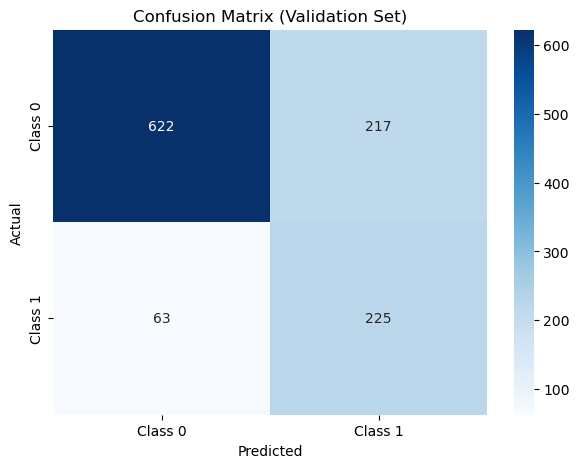

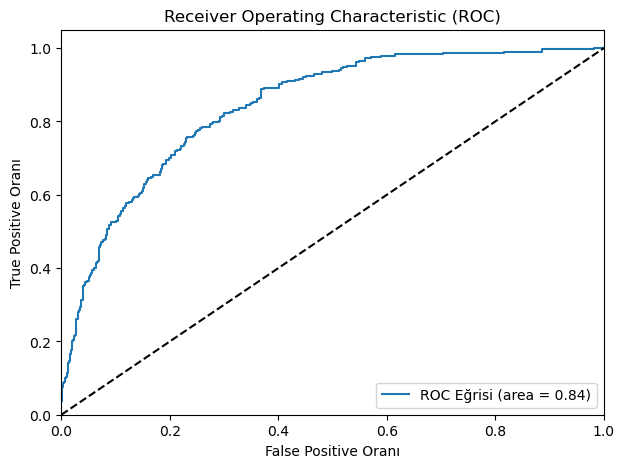


--- Test Verisi İçin Tahminler ---
   churn_prediction  churn_probability
0                 0           0.131949
1                 1           0.772213
2                 0           0.162269
3                 1           0.614474
4                 0           0.083798
5                 1           0.797308
6                 1           0.713530
7                 0           0.327706
8                 0           0.006908
9                 1           0.605791


In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler Çalışabilsin Diye) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böylece hem grafikler için gerçek etiketlerimiz (y_val) olacak hem de kodun hata vermeyecek.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. Model Tanımlama ve Eğitme ---
logreg = LogisticRegression(random_state=42, C=100, max_iter=1000)
logreg.fit(X_train_part, y_train_part)

# --- 3. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = logreg.predict(X_val)
y_val_proba = logreg.predict_proba(X_val)[:, 1]

# --- 4. Metriklerin Hesaplaması (İstediğin Tüm Metrikler Aktif) ---
accuracy_lr = accuracy_score(y_val, y_val_pred)
f1_score_lr = f1_score(y_val, y_val_pred)
classification_rep_lr = classification_report(y_val, y_val_pred)
conf_matrix_lr = confusion_matrix(y_val, y_val_pred)
roc_auc_lr = roc_auc_score(y_val, y_val_proba)
kappa_lr = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_lr.ravel()
sensitivity_lr = tp / (tp + fn)  # Recall
specificity_lr = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("--- Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_lr)
print("F1-Score:", f1_score_lr)
print("\nClassification Report:\n", classification_rep_lr)
print("Sensitivity (Recall):", sensitivity_lr)
print("Specificity:", specificity_lr)
print("Cohen's Kappa:", kappa_lr)
print("ROC-AUC Score:", roc_auc_lr)

# --- 5. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 6. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_lr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# =========================================================================
print("\n--- Test Verisi İçin Tahminler ---")
y_test_pred = logreg.predict(X_test_scaled)
y_test_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Sonuçları teslim formatına getirme
submission_lr = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_lr.head(10))

SVM CV ROC-AUC Scores: [0.86779155 0.87998623 0.9612764  0.95681818 0.94944674]
SVM Mean CV ROC-AUC (Genel Başarı): 0.9230638200183655

--- SVM Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7684117125110914
F1-Score: 0.5769854132901134

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       839
           1       0.54      0.62      0.58       288

    accuracy                           0.77      1127
   macro avg       0.70      0.72      0.71      1127
weighted avg       0.78      0.77      0.77      1127

Sensitivity (Recall): 0.6180555555555556
Specificity: 0.8200238379022646
Cohen's Kappa: 0.41851518715837543
ROC-AUC Score: 0.7966866971262085


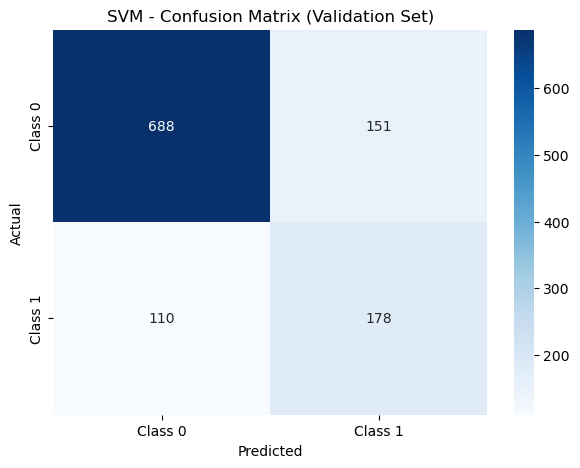

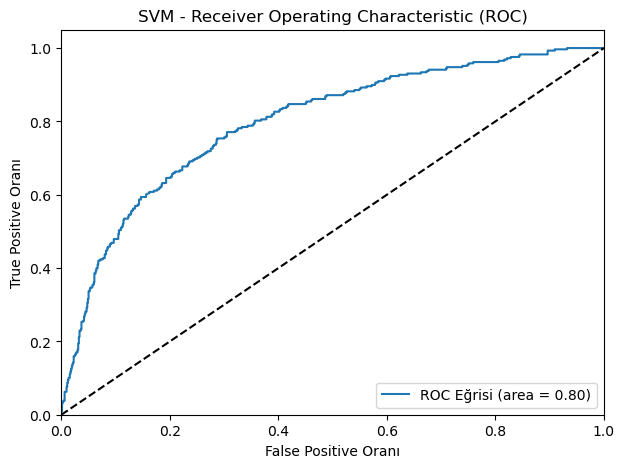


--- Gerçek Test Verisi İçin SVM Tahminleri Üretiliyor ---
   churn_prediction  churn_probability
0                 0           0.012367
1                 1           0.768757
2                 0           0.052857
3                 0           0.079329
4                 0           0.031572
5                 1           0.868390
6                 0           0.436374
7                 0           0.031555
8                 0           0.016222
9                 1           0.679536


In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böyleve y_test bağımlılığı ortadan kalkıyor, grafikleriniz y_val ile hatasız çiziliyor.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. SVM Modelini Tanımlama ve Eğitme ---
# probability=True parametresi ROC-AUC ve olasılık skorları hesaplayabilmemiz için kritik.
svm = SVC(random_state=42, C=10, gamma="auto", kernel="rbf" ,probability=True)
svm.fit(X_train_part, y_train_part)

# --- 3. Çapraz Doğrulama (Cross Validation) ---
# Modelin genel başarısını train seti üzerinden çok katmanlı ölçüyoruz.
cv_scores = cross_val_score(
    svm, X_resampled_scaled, y_resampled, cv=5, scoring='roc_auc', n_jobs=-1
)
print("SVM CV ROC-AUC Scores:", cv_scores)
print("SVM Mean CV ROC-AUC (Genel Başarı):", cv_scores.mean())

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = svm.predict(X_val)
y_val_proba = svm.predict_proba(X_val)[:, 1]

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_svm = accuracy_score(y_val, y_val_pred)
f1_score_svm = f1_score(y_val, y_val_pred)
classification_rep_svm = classification_report(y_val, y_val_pred)
conf_matrix_svm = confusion_matrix(y_val, y_val_pred)
roc_auc_svm = roc_auc_score(y_val, y_val_proba)
kappa_svm = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)  # Recall
specificity_svm = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- SVM Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_svm)
print("F1-Score:", f1_score_svm)
print("\nClassification Report:\n", classification_rep_svm)
print("Sensitivity (Recall):", sensitivity_svm)
print("Specificity:", specificity_svm)
print("Cohen's Kappa:", kappa_svm)
print("ROC-AUC Score:", roc_auc_svm)

# --- 6. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('SVM - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_svm)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('SVM - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# =========================================================================
# --- TEST VERİSİ İÇİN TAHMİNLER ---
print("\n--- Gerçek Test Verisi İçin SVM Tahminleri Üretiliyor ---")
y_test_pred = svm.predict(X_test_scaled)
y_test_proba = svm.predict_proba(X_test_scaled)[:, 1]

# Sonuçları yeni bir teslim tablosuna kaydetme
submission_svm = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_svm.head(10))

Decision Tree CV ROC-AUC Scores: [0.78044995 0.81324954 0.88403466 0.87326331 0.8659022 ]
Decision Tree Mean CV ROC-AUC (Genel Başarı): 0.8433799357208448

--- Decision Tree Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7417923691215617
F1-Score: 0.5637181409295352

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.77      0.82       839
           1       0.50      0.65      0.56       288

    accuracy                           0.74      1127
   macro avg       0.68      0.71      0.69      1127
weighted avg       0.77      0.74      0.75      1127

Sensitivity (Recall): 0.6527777777777778
Specificity: 0.7723480333730631
Cohen's Kappa: 0.38516324368912924
ROC-AUC Score: 0.7476844954310686


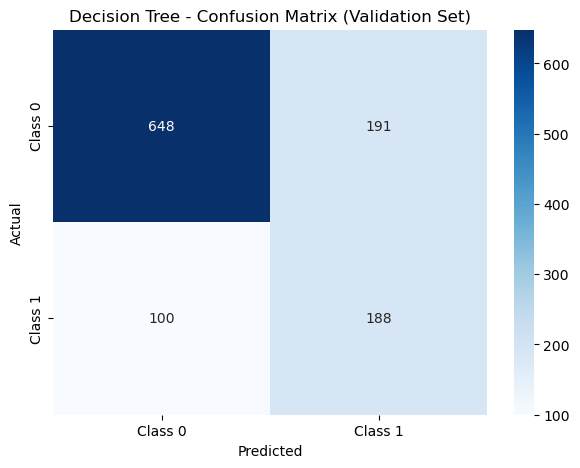

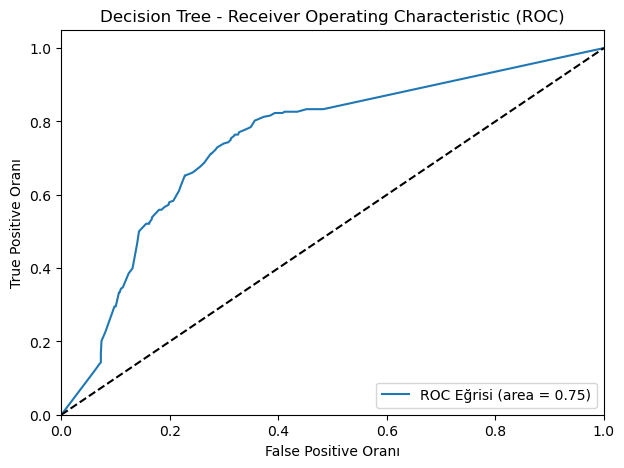


--- Gerçek Test Verisi İçin Decision Tree Tahminleri Üretiliyor ---
   churn_prediction  churn_probability
0                 1           1.000000
1                 1           1.000000
2                 0           0.166667
3                 1           0.646154
4                 0           0.000000
5                 1           0.895487
6                 0           0.400000
7                 0           0.000000
8                 0           0.000000
9                 0           0.368421


In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böylece y_test bağımlılığı ortadan kalkıyor, grafikleriniz y_val ile hatasız çiziliyor.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. Karar Ağacı Modelini Tanımlama ve Eğitme ---
# Belirlediğin budama parametreleri ağacın ezberlemesini önlemek için harika bir tercih.
decision_tree = DecisionTreeClassifier(
    random_state=42, max_depth=10, min_samples_split=2, min_samples_leaf=1)
decision_tree.fit(X_train_part, y_train_part)

# --- 3. Çapraz Doğrulama (Cross Validation) ---
# Modelin genel başarısını tüm train seti üzerinden 5 katmanlı olarak ölçüyoruz.
cv_scores = cross_val_score(
    decision_tree,
    X_resampled_scaled,
    y_resampled,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
print("Decision Tree CV ROC-AUC Scores:", cv_scores)
print("Decision Tree Mean CV ROC-AUC (Genel Başarı):", cv_scores.mean())

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = decision_tree.predict(X_val)
y_val_proba = decision_tree.predict_proba(X_val)[:, 1]

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_dt = accuracy_score(y_val, y_val_pred)
f1_score_dt = f1_score(y_val, y_val_pred)
classification_rep_dt = classification_report(y_val, y_val_pred)
conf_matrix_dt = confusion_matrix(y_val, y_val_pred)
roc_auc_dt = roc_auc_score(y_val, y_val_proba)
kappa_dt = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_dt.ravel()
sensitivity_dt = tp / (tp + fn)  # Recall
specificity_dt = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- Decision Tree Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_dt)
print("F1-Score:", f1_score_dt)
print("\nClassification Report:\n", classification_rep_dt)
print("Sensitivity (Recall):", sensitivity_dt)
print("Specificity:", specificity_dt)
print("Cohen's Kappa:", kappa_dt)
print("ROC-AUC Score:", roc_auc_dt)

# --- 6. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('Decision Tree - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_dt)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('Decision Tree - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# =========================================================================
# --- TEST VERİSİ İÇİN TAHMİNLER ---
print("\n--- Gerçek Test Verisi İçin Decision Tree Tahminleri Üretiliyor ---")
y_test_pred = decision_tree.predict(X_test_scaled)
y_test_proba = decision_tree.predict_proba(X_test_scaled)[:, 1]

# Sonuçları yeni bir teslim tablosuna kaydetme
submission_dt = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_dt.head(10))

Random Forest CV ROC-AUC Scores: [0.86901056 0.87315886 0.91881543 0.91229109 0.91594582]
Random Forest Mean CV ROC-AUC (Genel Başarı): 0.89784435261708

--- Random Forest Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7657497781721384
F1-Score: 0.6106194690265486

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83       839
           1       0.53      0.72      0.61       288

    accuracy                           0.77      1127
   macro avg       0.71      0.75      0.72      1127
weighted avg       0.80      0.77      0.78      1127

Sensitivity (Recall): 0.71875
Specificity: 0.7818831942789034
Cohen's Kappa: 0.4484768270845614
ROC-AUC Score: 0.8469904648390942


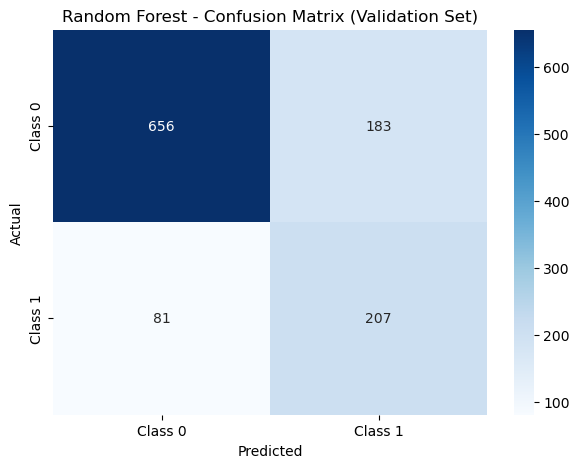

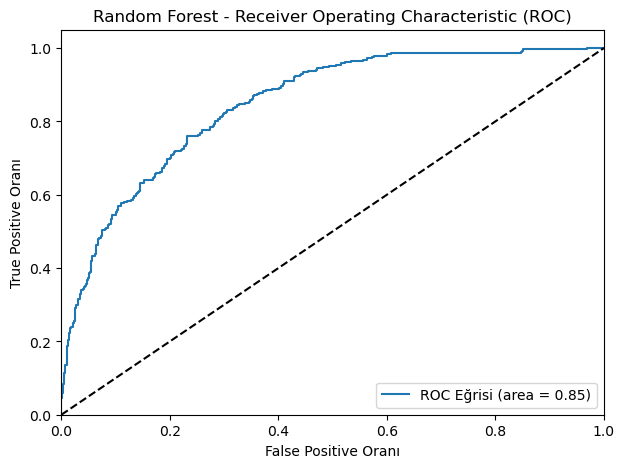


--- Gerçek Test Verisi İçin Random Forest Tahminleri Üretiliyor ---
   churn_prediction  churn_probability
0                 0           0.032804
1                 1           0.763673
2                 0           0.155021
3                 1           0.511197
4                 0           0.036238
5                 1           0.805262
6                 1           0.657042
7                 0           0.189969
8                 0           0.003631
9                 1           0.559107


In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böylece y_test bağımlılığı ortadan kalkıyor, grafikleriniz y_val ile hatasız çiziliyor.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. Random Forest Modelini Tanımlama ve Eğitme ---
random_forest = RandomForestClassifier(random_state=42, max_depth=8, min_samples_leaf=4, min_samples_split=10, n_estimators=300, n_jobs=-1)
random_forest.fit(X_train_part, y_train_part)

# --- 3. Çapraz Doğrulama (Cross Validation) ---
# Modelin genel başarısını tüm train seti üzerinden 5 katmanlı olarak ölçüyoruz.
cv_scores = cross_val_score(
    random_forest,
    X_resampled_scaled,
    y_resampled,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
print("Random Forest CV ROC-AUC Scores:", cv_scores)
print("Random Forest Mean CV ROC-AUC (Genel Başarı):", cv_scores.mean())

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = random_forest.predict(X_val)
y_val_proba = random_forest.predict_proba(X_val)[:, 1]

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_rf = accuracy_score(y_val, y_val_pred)
f1_score_rf = f1_score(y_val, y_val_pred)
classification_rep_rf = classification_report(y_val, y_val_pred)
conf_matrix_rf = confusion_matrix(y_val, y_val_pred)
roc_auc_rf = roc_auc_score(y_val, y_val_proba)
kappa_rf = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)  # Recall
specificity_rf = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- Random Forest Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_rf)
print("F1-Score:", f1_score_rf)
print("\nClassification Report:\n", classification_rep_rf)
print("Sensitivity (Recall):", sensitivity_rf)
print("Specificity:", specificity_rf)
print("Cohen's Kappa:", kappa_rf)
print("ROC-AUC Score:", roc_auc_rf)

# --- 6. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('Random Forest - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('Random Forest - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# =========================================================================
# --- TEST VERİSİ İÇİN TAHMİNLER ---
print("\n--- Gerçek Test Verisi İçin Random Forest Tahminleri Üretiliyor ---")
y_test_pred = random_forest.predict(X_test_scaled)
y_test_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

# Sonuçları yeni bir teslim tablosuna kaydetme
submission_rf = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_rf.head(10))


Gradient Boosting CV ROC-AUC Scores: [0.85546028 0.87263085 0.98013659 0.97655877 0.98066919]
Gradient Boosting Mean CV ROC-AUC (Genel Başarı): 0.9330911386593204

--- Gradient Boosting Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7905944986690329
F1-Score: 0.5972696245733788

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86       839
           1       0.59      0.61      0.60       288

    accuracy                           0.79      1127
   macro avg       0.73      0.73      0.73      1127
weighted avg       0.79      0.79      0.79      1127

Sensitivity (Recall): 0.6076388888888888
Specificity: 0.8533969010727056
Cohen's Kappa: 0.45583848568049856
ROC-AUC Score: 0.8426201827572508


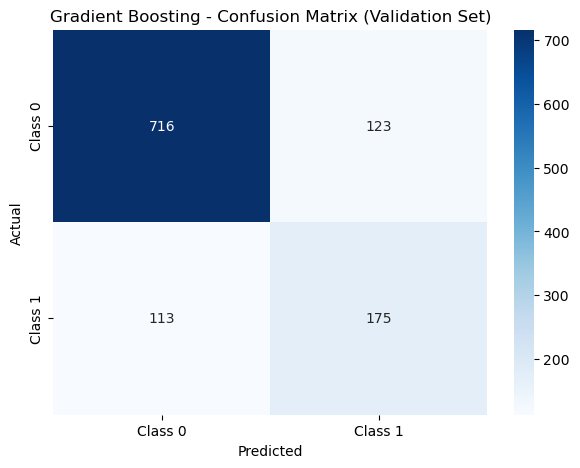

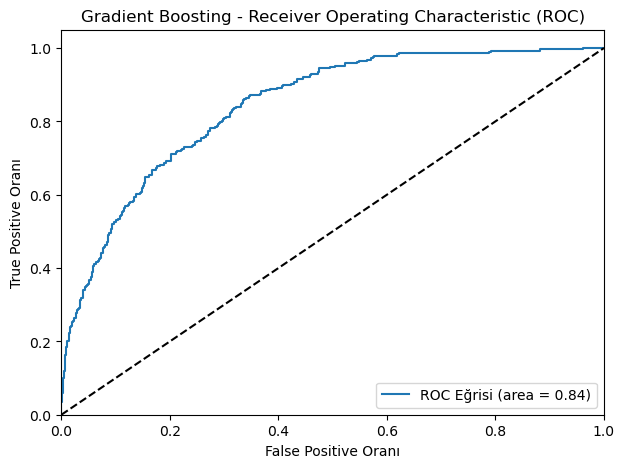


--- Gerçek Test Verisi İçin Gradient Boosting Tahminleri Üretiliyor ---
   churn_prediction  churn_probability
0                 0           0.042723
1                 1           0.776222
2                 0           0.076571
3                 0           0.289136
4                 0           0.030390
5                 1           0.728486
6                 1           0.652303
7                 0           0.102135
8                 0           0.020226
9                 1           0.574907


In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böylece y_test bağımlılığı ortadan kalkıyor, grafikleriniz y_val ile hatasız çiziliyor.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. Gradient Boosting Modelini Tanımlama ve Eğitme ---
gbm = GradientBoostingClassifier(random_state=42, learning_rate=0.05, max_depth=4, subsample=0.8, n_estimators=200)
gbm.fit(X_train_part, y_train_part)

# --- 3. Çapraz Doğrulama (Cross Validation) ---
# Modelin genel başarısını tüm train seti üzerinden 5 katmanlı olarak ölçüyoruz.
cv_scores = cross_val_score(
    gbm, X_resampled_scaled, y_resampled, cv=5, scoring='roc_auc', n_jobs=-1
)
print("Gradient Boosting CV ROC-AUC Scores:", cv_scores)
print("Gradient Boosting Mean CV ROC-AUC (Genel Başarı):", cv_scores.mean())

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = gbm.predict(X_val)
y_val_proba = gbm.predict_proba(X_val)[:, 1]

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_gb = accuracy_score(y_val, y_val_pred)
f1_score_gb = f1_score(y_val, y_val_pred)
classification_rep_gb = classification_report(y_val, y_val_pred)
conf_matrix_gb = confusion_matrix(y_val, y_val_pred)
roc_auc_gb = roc_auc_score(y_val, y_val_proba)
kappa_gb = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_gb.ravel()
sensitivity_gb = tp / (tp + fn)  # Recall
specificity_gb = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- Gradient Boosting Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_gb)
print("F1-Score:", f1_score_gb)
print("\nClassification Report:\n", classification_rep_gb)
print("Sensitivity (Recall):", sensitivity_gb)
print("Specificity:", specificity_gb)
print("Cohen's Kappa:", kappa_gb)
print("ROC-AUC Score:", roc_gb_score if 'roc_gb_score' in locals() else roc_auc_gb)

# --- 6. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_gb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('Gradient Boosting - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_gb)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('Gradient Boosting - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# =========================================================================
# --- TEST VERİSİ İÇİN TAHMİNLER ---
print("\n--- Gerçek Test Verisi İçin Gradient Boosting Tahminleri Üretiliyor ---")
y_test_pred = gbm.predict(X_test_scaled)
y_test_proba = gbm.predict_proba(X_test_scaled)[:, 1]

# Sonuçları yeni bir teslim tablosuna kaydetme
submission_gb = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_gb.head(10))


AdaBoost CV ROC-AUC Scores: [0.84766873 0.86203857 0.97285813 0.96567034 0.97563705]
AdaBoost Mean CV ROC-AUC (Genel Başarı): 0.9247745638200182

--- AdaBoost Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7710736468500443
F1-Score: 0.5943396226415094

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84       839
           1       0.54      0.66      0.59       288

    accuracy                           0.77      1127
   macro avg       0.71      0.73      0.72      1127
weighted avg       0.79      0.77      0.78      1127

Sensitivity (Recall): 0.65625
Specificity: 0.8104886769964244
Cohen's Kappa: 0.4368536035512586
ROC-AUC Score: 0.8365655211230301


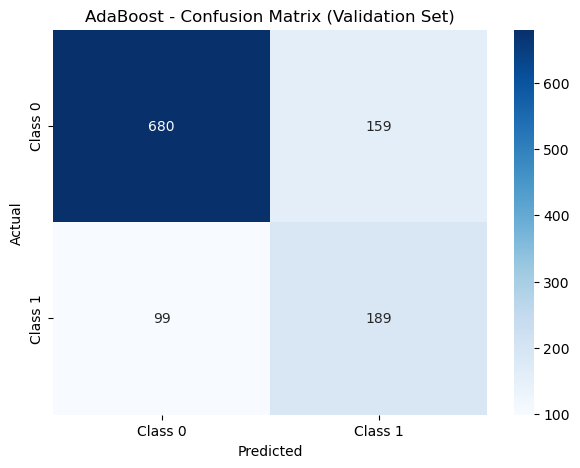

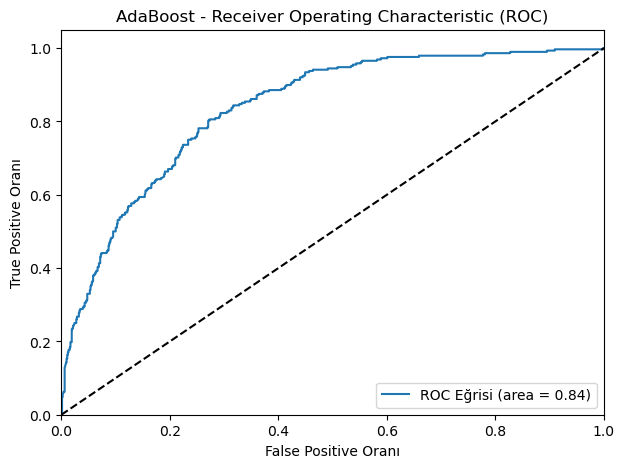


--- Gerçek Test Verisi İçin AdaBoost Tahminleri Üretiliyor ---
   churn_prediction  churn_probability
0                 0           0.473732
1                 1           0.501636
2                 0           0.497249
3                 0           0.499447
4                 0           0.492771
5                 1           0.501185
6                 1           0.500544
7                 0           0.498022
8                 0           0.493587
9                 1           0.500069


In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böylece y_test bağımlılığı ortadan kalkıyor, grafikleriniz y_val ile hatasız çiziliyor.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. AdaBoost Modelini Tanımlama ve Eğitme ---
# Belirlediğin n_estimators=200 ve learning_rate=1.0 parametreleri modelin kapasitesini artırmak için güzel bir kombinasyon.
adaboost = AdaBoostClassifier(random_state=42, n_estimators=200, learning_rate=1.0)
adaboost.fit(X_train_part, y_train_part)

# --- 3. Çapraz Doğrulama (Cross Validation) ---
# Modelin genel başarısını tüm train seti üzerinden 5 katmanlı olarak ölçüyoruz.
cv_scores = cross_val_score(
    adaboost,
    X_resampled_scaled,
    y_resampled,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
print("AdaBoost CV ROC-AUC Scores:", cv_scores)
print("AdaBoost Mean CV ROC-AUC (Genel Başarı):", cv_scores.mean())

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = adaboost.predict(X_val)
y_val_proba = adaboost.predict_proba(X_val)[:, 1]

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_ada = accuracy_score(y_val, y_val_pred)
f1_score_ada = f1_score(y_val, y_val_pred)
classification_rep_ada = classification_report(y_val, y_val_pred)
conf_matrix_ada = confusion_matrix(y_val, y_val_pred)
roc_auc_ada = roc_auc_score(y_val, y_val_proba)
kappa_ada = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_ada.ravel()
sensitivity_ada = tp / (tp + fn)  # Recall
specificity_ada = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- AdaBoost Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_ada)
print("F1-Score:", f1_score_ada)
print("\nClassification Report:\n", classification_rep_ada)
print("Sensitivity (Recall):", sensitivity_ada)
print("Specificity:", specificity_ada)
print("Cohen's Kappa:", kappa_ada)
print("ROC-AUC Score:", roc_auc_ada)

# --- 6. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_ada,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('AdaBoost - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_ada)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('AdaBoost - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# =========================================================================
# --- TEST VERİSİ İÇİN TAHMİNLER ---
print("\n--- Gerçek Test Verisi İçin AdaBoost Tahminleri Üretiliyor ---")
y_test_pred = adaboost.predict(X_test_scaled)
y_test_proba = adaboost.predict_proba(X_test_scaled)[:, 1]

# Sonuçları yeni bir teslim tablosuna kaydetme
submission_ada = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_ada.head(10))

XGBoost CV ROC-AUC Scores: [0.85822314 0.87483701 0.97285813 0.97065083 0.97666896]
XGBoost Mean CV ROC-AUC (Genel Başarı): 0.9306476124885217

--- XGBoost Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.7941437444543035
F1-Score: 0.6196721311475409

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       839
           1       0.59      0.66      0.62       288

    accuracy                           0.79      1127
   macro avg       0.73      0.75      0.74      1127
weighted avg       0.80      0.79      0.80      1127

Sensitivity (Recall): 0.65625
Specificity: 0.8414779499404053
Cohen's Kappa: 0.47915330339961515
ROC-AUC Score: 0.8464152099059726


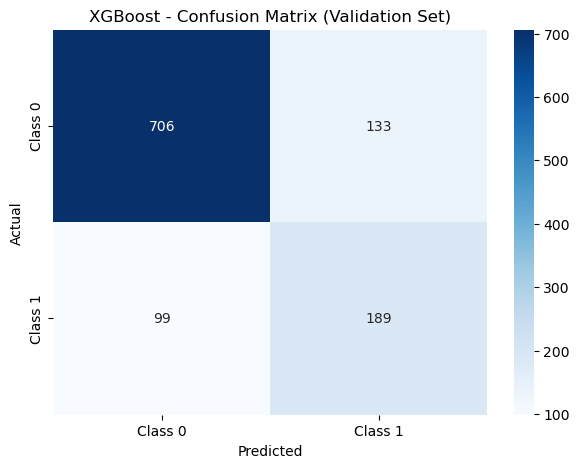

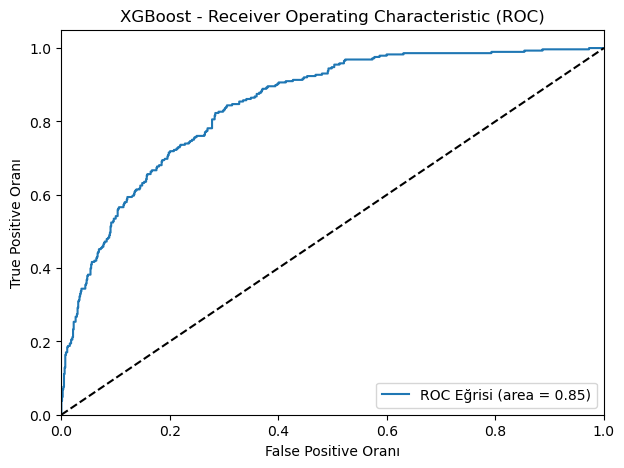


--- Gerçek Test Verisi İçin XGBoost Tahminleri Üretiliyor ---
   churn_prediction  churn_probability
0                 0           0.052368
1                 1           0.740833
2                 0           0.097251
3                 0           0.257936
4                 0           0.021705
5                 1           0.786573
6                 1           0.597693
7                 0           0.124804
8                 0           0.011396
9                 1           0.563523


In [97]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled verini %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
# Böylece grafikler ve metrikler y_val ile hiçbir hata tetiklemeden tıkır tıkır çalışır.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. XGBoost Modelini Tanımlama ve Eğitme ---
xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=200,
    learning_rate=0.04,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(X_train_part, y_train_part)

# --- 3. Çapraz Doğrulama (Cross Validation) ---
# Modelin genel performans kararlılığını tüm train seti üzerinden 5 katmanlı ölçüyoruz.
cv_scores = cross_val_score(
    xgb_model,
    X_resampled_scaled,
    y_resampled,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
print("XGBoost CV ROC-AUC Scores:", cv_scores)
print("XGBoost Mean CV ROC-AUC (Genel Başarı):", cv_scores.mean())

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_pred = xgb_model.predict(X_val)
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_xgb = accuracy_score(y_val, y_val_pred)
f1_score_xgb = f1_score(y_val, y_val_pred)
classification_rep_xgb = classification_report(y_val, y_val_pred)
conf_matrix_xgb = confusion_matrix(y_val, y_val_pred)
roc_auc_xgb = roc_auc_score(y_val, y_val_proba)
kappa_xgb = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)  # Recall
specificity_xgb = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- XGBoost Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_xgb)
print("F1-Score:", f1_score_xgb)
print("\nClassification Report:\n", classification_rep_xgb)
print("Sensitivity (Recall):", sensitivity_xgb)
print("Specificity:", specificity_xgb)
print("Cohen's Kappa:", kappa_xgb)
print("ROC-AUC Score:", roc_auc_xgb)

# --- 6. Confusion Matrix Görselleştirme ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('XGBoost - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. ROC Eğrisi Görselleştirme ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('XGBoost - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# =========================================================================
# --- TEST VERİSİ İÇİN TAHMİNLER ---
print("\n--- Gerçek Test Verisi İçin XGBoost Tahminleri Üretiliyor ---")
y_test_pred = xgb_model.predict(X_test_scaled)
y_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Sonuçları yeni bir teslim tablosuna kaydetme
submission_xgb = pd.DataFrame({
    'churn_prediction': y_test_pred,
    'churn_probability': y_test_proba,
})
print(submission_xgb.head(10))


## Derin Öğrenme Modellerini Eğitme ve Değerlendirme

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6972 - loss: 0.5844 - val_accuracy: 0.7409 - val_loss: 0.5075
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7620 - loss: 0.4924 - val_accuracy: 0.7276 - val_loss: 0.5239
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7706 - loss: 0.4812 - val_accuracy: 0.7374 - val_loss: 0.5109
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7668 - loss: 0.4766 - val_accuracy: 0.7347 - val_loss: 0.4938
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7898 - loss: 0.4557 - val_accuracy: 0.7391 - val_loss: 0.5299
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7903 - loss: 0.4566 - val_accuracy: 0.7267 - val_loss: 0.5275
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7867 - loss: 0.4497 - val_accuracy: 0.7409 - val_loss: 0.5108
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7876 - loss: 0.4507 - val_accuracy: 0.

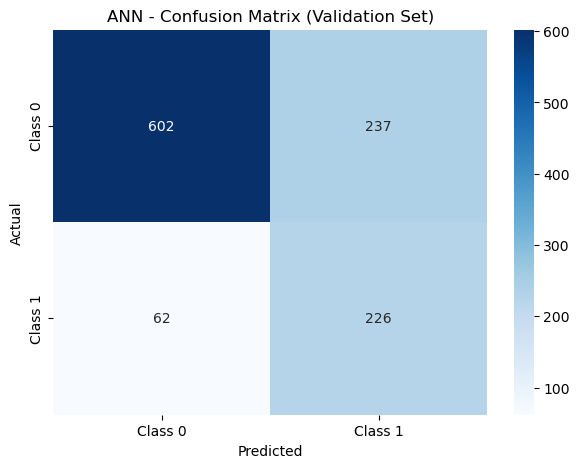

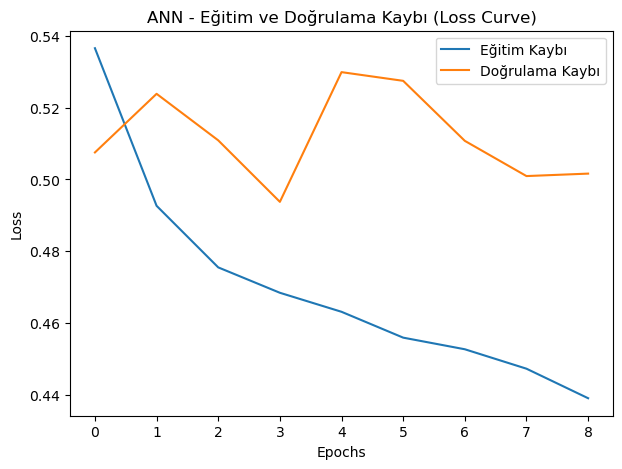

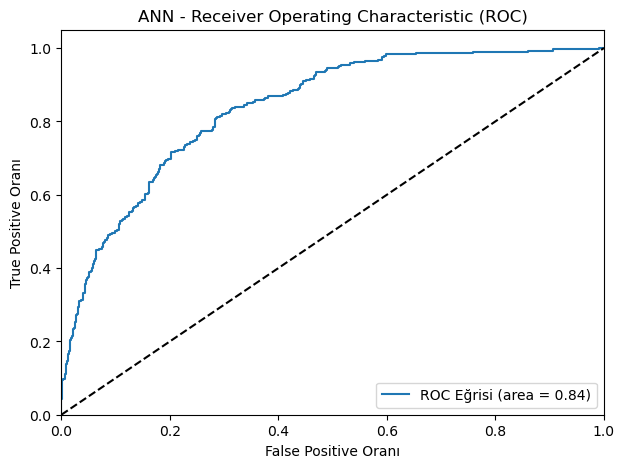


--- Gerçek Test Verisi İçin ANN Tahminleri Üretiliyor ---
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step
      Churn
0  0.193532
1  0.838393
2  0.209142
3  0.692621
4  0.098716
5  0.880801
6  0.745937
7  0.169141
8  0.002719
9  0.632742


In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled (SMOTE'lu) verinizi %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. ANN Model Mimarisini Tanımlama ---
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_part.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # İkili sınıflandırma (Churn: 1, Kalacak: 0)
])

# --- 3. Model Derleme ---
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- 4. Early Stopping ile Eğitim ---
# val_loss 5 epoch boyunca iyileşmezse eğitimi durdurur ve en iyi ağırlıklara geri döner.
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# fit işleminde doğrudan ayırdığımız X_val ve y_val setini veriyoruz
history = ann_model.fit(
    X_train_part, y_train_part,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# --- 5. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_proba = ann_model.predict(X_val).ravel()  # Çıktıyı 1 boyutlu diziye dönüştürüyoruz
y_val_pred = (y_val_proba > 0.5).astype(int)

# --- 6. Başarı Metriklerinin Hesaplanması ---
accuracy_ann = accuracy_score(y_val, y_val_pred)
f1_score_ann = f1_score(y_val, y_val_pred)
classification_rep_ann = classification_report(y_val, y_val_pred)
conf_matrix_ann = confusion_matrix(y_val, y_val_pred)
roc_auc_ann = roc_auc_score(y_val, y_val_proba)
kappa_ann = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_ann.ravel()
sensitivity_ann = tp / (tp + fn)  # Recall
specificity_ann = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- ANN Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_ann)
print("F1-Score:", f1_score_ann)
print("\nClassification Report:\n", classification_rep_ann)
print("Sensitivity (Recall):", sensitivity_ann)
print("Specificity:", specificity_ann)
print("Cohen's Kappa:", kappa_ann)
print("ROC-AUC Score:", roc_auc_ann)

# --- 7. Confusion Matrix Görselleştirme (Korundu 📊) ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_ann,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('ANN - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 8. Eğitim/Doğrulama Kaybı Grafiği (Korundu 📉) ---
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('ANN - Eğitim ve Doğrulama Kaybı (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- 9. ROC Eğrisi Görselleştirme (Korundu 📈) ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_ann)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('ANN - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# =========================================================================
# --- GERÇEK TEST VERİSİ İÇİN KAGGLE TAHMİNLERİ ---
# Kaggle için 0.81 skorumuzu geçmeye çalışacağımız ondalıklı olasılık tahminleri
# =========================================================================
print("\n--- Gerçek Test Verisi İçin ANN Tahminleri Üretiliyor ---")
y_test_proba = ann_model.predict(X_test_scaled).ravel()

# Sonuçları Kaggle teslim formatına getirme
submission_ann = pd.DataFrame({
    'Churn': y_test_proba  # Kaggle ROC-AUC metriği için ondalıklı olasılık değeri
})
print(submission_ann.head(10))

# İstersen ANN sonuçlarını da doğrudan CSV yapabilirsin:
# submission_ann.to_csv('submission_ann.csv', index=False)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6992 - loss: 0.6125 - val_accuracy: 0.8030 - val_loss: 0.4382
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7552 - loss: 0.5067 - val_accuracy: 0.7240 - val_loss: 0.5220
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7719 - loss: 0.4861 - val_accuracy: 0.6974 - val_loss: 0.5777
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7635 - loss: 0.4909 - val_accuracy: 0.7045 - val_loss: 0.5487
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7730 - loss: 0.4824 - val_accuracy: 0.6788 - val_loss: 0.5966
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7712 - loss: 0.4770 - val_accuracy: 0.6815 - val_loss: 0.6163
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- 1D CNN Doğrulama (Validation) Seti Sonuçları ---
Accuracy: 0.80301685891748
F1-Score: 0.5978260869565217

Classification Report:
               precision    recall  f1-score   support

   

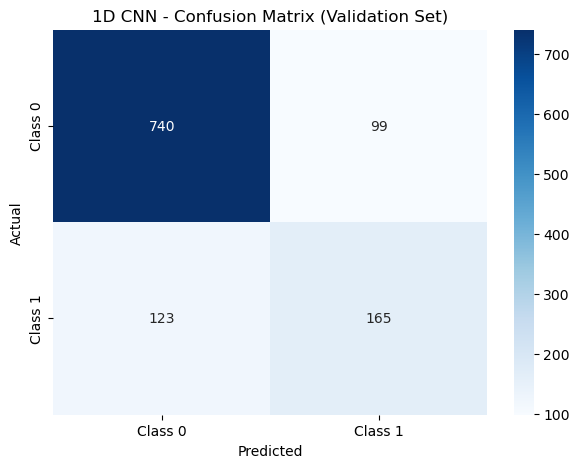

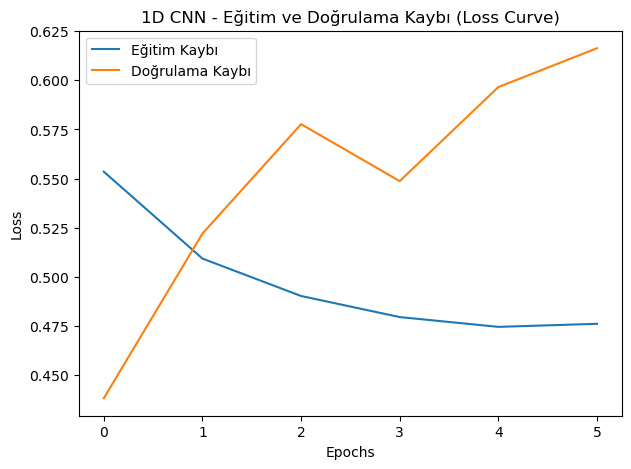

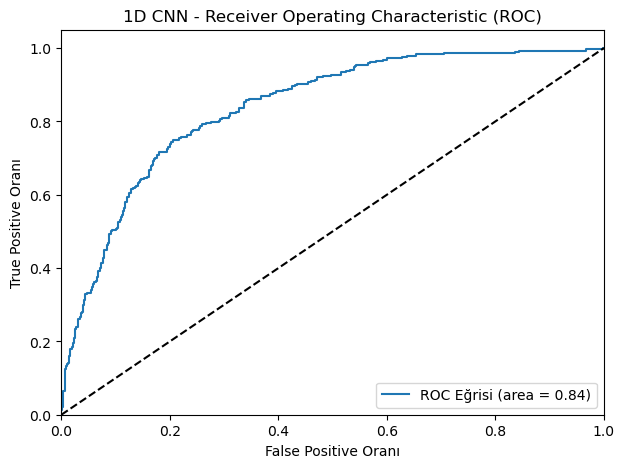


--- Gerçek Test Verisi İçin 1D CNN Tahminleri Üretiliyor ---
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step
      Churn
0  0.135347
1  0.452817
2  0.136830
3  0.430932
4  0.084698
5  0.523921
6  0.347357
7  0.245316
8  0.058121
9  0.458111


In [99]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    MaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# --- 1. Train Verisini Kendi İçinde Bölme ---
# Orijinal resampled (SMOTE'lu) verinizi %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)

# --- 2. Veriyi 1D CNN Formatına Getirme (3 Boyutlu Yapı) ---
# Keras Conv1D katmanı (samples, steps, features) formatında girdi bekler.
# Sütunları birer adım (step) ve kanal sayısını 1 olarak boyutlandırıyoruz.
X_train_cnn = X_train_part[..., None]
X_val_cnn = X_val[..., None]
X_test_cnn = X_test_scaled[..., None]  # Kaggle tahmini için asıl test verisi

# --- 3. 1D CNN Model Mimarisini Tanımlama ---
cnn_model = Sequential([
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train_cnn.shape[1], 1),
    ),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    # Eğer filtreleme sonrası boyut çok küçülürse MaxPooling hata verebilir,
    # Hata alırsanız alttaki MaxPooling katmanını kaldırabilirsiniz.
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),  # İkili sınıflandırma (Churn: 1, Kalacak: 0)
])

# --- 4. Model Derleme ---
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

# --- 5. Early Stopping ile Eğitim ---
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn,
    y_train_part,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

# --- 6. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_proba = cnn_model.predict(X_val_cnn).ravel()  # 1 boyutlu diziye indirgiyoruz
y_val_pred = (y_val_proba > 0.5).astype(int)

# --- 7. Başarı Metriklerinin Hesaplanması ---
accuracy_cnn = accuracy_score(y_val, y_val_pred)
f1_score_cnn = f1_score(y_val, y_val_pred)
classification_rep_cnn = classification_report(y_val, y_val_pred)
conf_matrix_cnn = confusion_matrix(y_val, y_val_pred)
roc_auc_cnn = roc_auc_score(y_val, y_val_proba)
kappa_cnn = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_cnn.ravel()
sensitivity_cnn = tp / (tp + fn)  # Recall
specificity_cnn = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- 1D CNN Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_cnn)
print("F1-Score:", f1_score_cnn)
print("\nClassification Report:\n", classification_rep_cnn)
print("Sensitivity (Recall):", sensitivity_cnn)
print("Specificity:", specificity_cnn)
print("Cohen's Kappa:", kappa_cnn)
print("ROC-AUC Score:", roc_auc_cnn)

# --- 8. Confusion Matrix Görselleştirme (Korundu 📊) ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('1D CNN - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 9. Eğitim/Doğrulama Kaybı Grafiği (Korundu 📉) ---
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('1D CNN - Eğitim ve Doğrulama Kaybı (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- 10. ROC Eğrisi Görselleştirme (Korundu 📈) ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_cnn)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('1D CNN - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# =========================================================================
# --- GERÇEK TEST VERİSİ İÇİN KAGGLE TAHMİNLERİ ---
# Kaggle ROC-AUC metriği için ondalıklı olasılık tahminleri üretiyoruz
# =========================================================================
print("\n--- Gerçek Test Verisi İçin 1D CNN Tahminleri Üretiliyor ---")
y_test_proba_cnn = cnn_model.predict(X_test_cnn).ravel()

# Sonuçları Kaggle teslim formatına getirme
submission_cnn = pd.DataFrame({
    'Churn': y_test_proba_cnn,  # Ondalıklı olasılık değeri
})
print(submission_cnn.head(10))

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6984 - loss: 0.5870 - val_accuracy: 0.7374 - val_loss: 0.5065
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7706 - loss: 0.4911 - val_accuracy: 0.7391 - val_loss: 0.5013
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7624 - loss: 0.4840 - val_accuracy: 0.7276 - val_loss: 0.5038
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7712 - loss: 0.4647 - val_accuracy: 0.7347 - val_loss: 0.5029
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7765 - loss: 0.4637 - val_accuracy: 0.7338 - val_loss: 0.5047
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7797 - loss: 0.4678 - val_accuracy: 0.7400 - val_loss: 0.4988
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7721 - loss: 0.4596 - val_accuracy: 0.7427 - val_loss: 0.4883
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7938 - loss: 0.4366 - val_accuracy: 0.

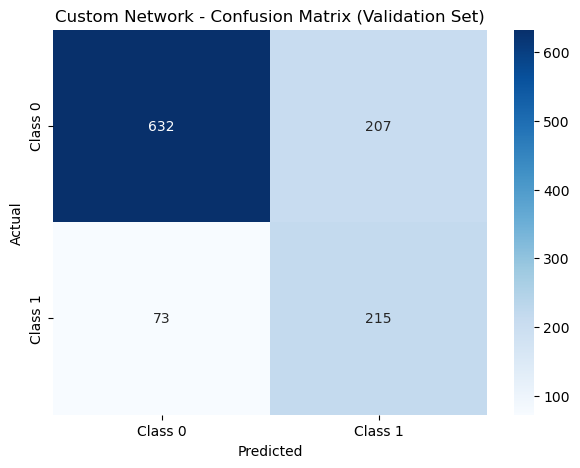

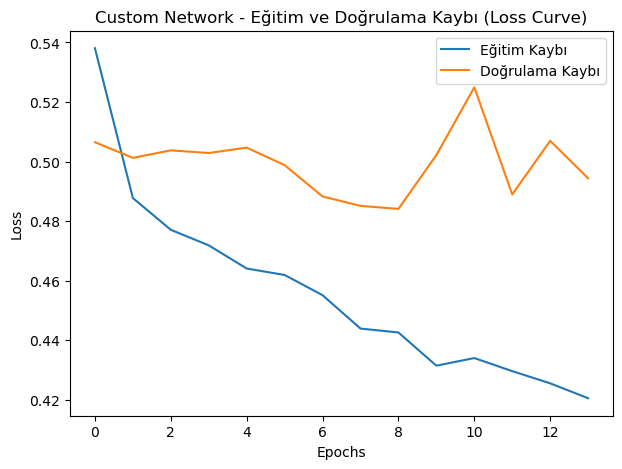

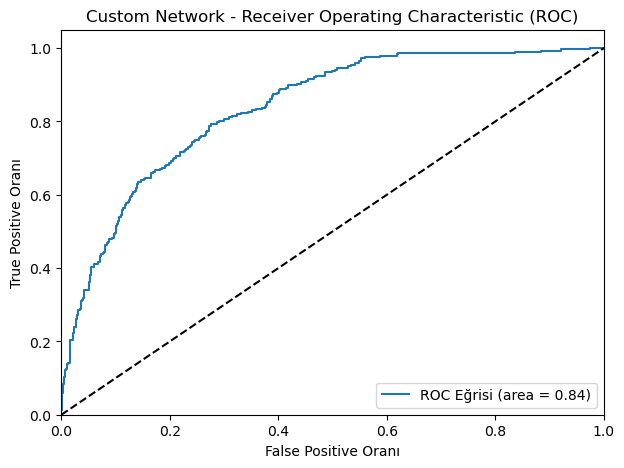


--- Gerçek Test Verisi İçin Model Tahminleri Üretiliyor ---
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step
      Churn
0  0.049407
1  0.879340
2  0.058262
3  0.221771
4  0.034368
5  0.844664
6  0.704749
7  0.091625
8  0.004103
9  0.784035


In [100]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Sequential

# --- 1. Train Verisini Kendi İçinde Bölme (Grafikler ve Metrikler İçin) ---
# Orijinal resampled (SMOTE'lu) verinizi %80 Eğitim, %20 Doğrulama (Validation) olarak bölüyoruz.
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_resampled_scaled, y_resampled, test_size=0.2, random_state=42
)


# --- 2. Taban ve Sınıflandırma Model Yapısının Tanımlanması ---
def create_transfer_learning_model(input_shape):
    # Basit bir Dense tabanlı yapı oluşturuyoruz (Özellik Çıkarıcı / Feature Extractor)
    base_model = Sequential([
        # İlk katman: Genel özellikleri öğrenmek ve yüksek boyutlu veriyi anlamlandırmak için
        Dense(128, activation='relu', input_shape=(input_shape,)),
        BatchNormalization(),  # Eğitim kararlılığını artırır
        Dropout(0.3),  # Aşırı öğrenmeyi (overfitting) önlemek için
        # İkinci katman: Orta seviyeli özellikleri öğrenmek için
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
    ])

    # Yeni Sınıflandırma Katmanlarını (Head) ekliyoruz
    # Daha düşük boyutlu özellik kümesiyle sınıflandırmayı iyileştirir
    base_model.add(Dense(32, activation='relu'))
    base_model.add(Dense(1, activation='sigmoid'))  # Binary classification için

    # Modeli derleme
    base_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    return base_model


# Modeli oluşturma
input_shape = X_train_part.shape[1]  # Özellik sayısını alıyoruz
transfer_learning_model = create_transfer_learning_model(input_shape)

# --- 3. Early Stopping ile Eğitim ---
# val_loss 5 epoch boyunca iyileşmezse eğitimi durdurur ve en iyi ağırlıklara geri döner.
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = transfer_learning_model.fit(
    X_train_part,
    y_train_part,
    validation_data=(X_val, y_val),  # validation_split yerine doğrudan seti verdik
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

# --- 4. Doğrulama (Validation) Seti Üzerinden Tahminler ---
y_val_proba = transfer_learning_model.predict(X_val).ravel()
y_val_pred = (y_val_proba > 0.5).astype(int)

# --- 5. Başarı Metriklerinin Hesaplanması ---
accuracy_transfer = accuracy_score(y_val, y_val_pred)
f1_score_transfer = f1_score(y_val, y_val_pred)
classification_rep_transfer = classification_report(y_val, y_val_pred)
conf_matrix_transfer = confusion_matrix(y_val, y_val_pred)
roc_auc_transfer = roc_auc_score(
    y_val, y_val_proba
)  # y_proba hatası düzeltildi 🌟
kappa_transfer = cohen_kappa_score(y_val, y_val_pred)

# Sensitivity (Recall) ve Specificity Hesaplama
tn, fp, fn, tp = conf_matrix_transfer.ravel()
sensitivity_transfer = tp / (tp + fn)  # Recall
specificity_transfer = tn / (tn + fp)

# Sonuçları ekrana yazdırma
print("\n--- Özelleştirilmiş Model Doğrulama (Validation) Seti Sonuçları ---")
print("Accuracy:", accuracy_transfer)
print("F1-Score:", f1_score_transfer)
print("\nClassification Report:\n", classification_rep_transfer)
print("Sensitivity (Recall):", sensitivity_transfer)
print("Specificity:", specificity_transfer)
print("Cohen's Kappa:", kappa_transfer)
print("ROC-AUC Score:", roc_auc_transfer)

# --- 6. Confusion Matrix Görselleştirme (Korundu 📊) ---
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_transfer,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1'],
)
plt.title('Custom Network - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 7. Eğitim/Doğrulama Kaybı Grafiği (Korundu 📉) ---
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Custom Network - Eğitim ve Doğrulama Kaybı (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- 8. ROC Eğrisi Görselleştirme (Korundu 📈) ---
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='ROC Eğrisi (area = %0.2f)' % roc_auc_transfer)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('Custom Network - Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# =========================================================================
# --- GERÇEK TEST VERİSİ İÇİN KAGGLE TAHMİNLERİ ---
# Kaggle ROC-AUC metriği için ondalıklı olasılık tahminleri üretiyoruz
# =========================================================================
print("\n--- Gerçek Test Verisi İçin Model Tahminleri Üretiliyor ---")
y_test_proba_transfer = transfer_learning_model.predict(X_test_scaled).ravel()

# Sonuçları Kaggle teslim formatına getirme
submission_transfer = pd.DataFrame({
    'Churn': y_test_proba_transfer,  # Kaggle için ondalıklı olasılık değeri
})
print(submission_transfer.head(10))

In [101]:
# Farklı modellerin performans metriklerini otomatik olarak toplama fonksiyonu
def collect_model_metrics(models_metrics):
    # models_metrics, her bir modelin performansını içeren bir dictionary listesi olmalıdır bu yüzden aşağıda oluşturuyoruz.
    comparison_df = pd.DataFrame(models_metrics)
    return comparison_df

# Model performans metrikleri

logistic_regression_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "F1-Score": f1_score_lr,
    "ROC-AUC": roc_auc_lr,
    "Kappa": kappa_lr
}

random_forest_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "F1-Score": f1_score_rf,
    "ROC-AUC": roc_auc_rf,
    "Kappa": kappa_rf
}

svm_metrics = {
    "Model": "SVM",
    "Accuracy": accuracy_svm,
    "F1-Score": f1_score_svm,
    "ROC-AUC": roc_auc_svm,
    "Kappa": kappa_svm
}

decision_tree_metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_dt,
    "F1-Score": f1_score_dt,
    "ROC-AUC": roc_auc_dt,
    "Kappa": kappa_dt
}

gb_metrics = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_gb,
    "F1-Score": f1_score_gb,
    "ROC-AUC": roc_auc_gb,
    "Kappa": kappa_gb
}

adaboost_metrics = {
    "Model": "AdaBoost",
    "Accuracy": accuracy_ada,
    "F1-Score": f1_score_ada,
    "ROC-AUC": roc_auc_ada,
    "Kappa": kappa_ada
}

xgboost_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_xgb,
    "F1-Score": f1_score_xgb,
    "ROC-AUC": roc_auc_xgb,
    "Kappa": kappa_xgb
}

ann_metrics = {
    "Model": "ANN",
    "Accuracy": accuracy_ann,
    "F1-Score": f1_score_ann,
    "ROC-AUC": roc_auc_ann,
    "Kappa": kappa_ann,
}

cnn_metrics = {
    "Model": "CNN",
    "Accuracy": accuracy_cnn,
    "F1-Score": f1_score_cnn,
    "ROC-AUC": roc_auc_cnn,
    "Kappa": kappa_cnn,
}

transfer_learning_metrics = {
    "Model": "Transfer Learning",
    "Accuracy": accuracy_transfer,
    "F1-Score": f1_score_transfer,
    "ROC-AUC": roc_auc_transfer,
    "Kappa": kappa_transfer,
}

# Tüm metrikleri birleştirme
total_metrics = [logistic_regression_metrics, random_forest_metrics, svm_metrics, 
                 decision_tree_metrics, gb_metrics, adaboost_metrics, xgboost_metrics, ann_metrics, cnn_metrics, transfer_learning_metrics]

# Model Karşılaştırma Tablosu
comparison_df = collect_model_metrics(total_metrics)
comparison_df

,Model,Accuracy,F1-Score,ROC-AUC,Kappa
0,Logistic Regression,0.751553,0.616438,0.841482,0.444552
1,Random Forest,0.765750,0.610619,0.846990,0.448477
2,SVM,0.768412,0.576985,0.796687,0.418515
3,Decision Tree,0.741792,0.563718,0.747684,0.385163
4,Gradient Boosting,0.790594,0.597270,0.842620,0.455838
5,AdaBoost,0.771074,0.594340,0.836566,0.436854
6,XGBoost,0.794144,0.619672,0.846415,0.479153
7,ANN,0.734694,0.601864,0.837935,0.418700
8,CNN,0.803017,0.597826,0.838345,0.467718
9,Transfer Learning,0.751553,0.605634,0.836528,0.433565


In [102]:
# =========================================================================
# 🏆 GÜÇLÜ AĞIRLIKLI HARMANLAMA VE OTOMATİK SUBMISSION OLUŞTURMA (ENSEMBLE) 🏆
# =========================================================================
import pandas as pd
import numpy as np

# 1. Tüm modellerin yerel doğrulama (Validation) ROC-AUC skorlarını ve model nesnelerini tanımlıyoruz
models_info = {
    "Logistic Regression": {"score": globals().get("roc_auc_lr", 0), "model": globals().get("logreg"), "type": "sklearn"},
    "Random Forest": {"score": globals().get("roc_auc_rf", 0), "model": globals().get("random_forest"), "type": "sklearn"},
    "SVM": {"score": globals().get("roc_auc_svm", 0), "model": globals().get("svm"), "type": "sklearn"},
    "Decision Tree": {"score": globals().get("roc_auc_dt", 0), "model": globals().get("decision_tree"), "type": "sklearn"},
    "Gradient Boosting": {"score": globals().get("roc_auc_gb", 0), "model": globals().get("gbm"), "type": "sklearn"},
    "AdaBoost": {"score": globals().get("roc_auc_ada", 0), "model": globals().get("adaboost"), "type": "sklearn"},
    "XGBoost": {"score": globals().get("roc_auc_xgb", 0), "model": globals().get("xgb_model"), "type": "sklearn"},
    "ANN": {"score": globals().get("roc_auc_ann", 0), "model": globals().get("ann_model"), "type": "keras"},
    "CNN": {"score": globals().get("roc_auc_cnn", 0), "model": globals().get("cnn_model"), "type": "keras_cnn"},
    "Transfer Learning": {"score": globals().get("roc_auc_transfer", 0), "model": globals().get("transfer_learning_model"), "type": "keras"}
}

# 2. Çalıştırılmış ve hafızada olan modellerin performanslarını listeliyoruz
print("=== Hafızadaki Aktif Model Performansları ===")
active_models_count = 0
for name, info in models_info.items():
    if info["model"] is not None and info["score"] > 0:
        print(f"%-20s: Yerel ROC-AUC = %.6f" % (name, info["score"]))
        active_models_count += 1

if active_models_count == 0:
    print("❌ Hata: Hafızada eğitilmiş hiçbir model bulunamadı! Lütfen hücreleri yukarıdan aşağıya çalıştırın.")
else:
    # 3. Şampiyon model tespiti (Fallback durumları için)
    best_model_name = max(models_info, key=lambda k: models_info[k]["score"] if models_info[k]["model"] is not None else -1)
    best_model_data = models_info[best_model_name]
    best_score = best_model_data["score"]
    
    print(f"\n🌟 En Yüksek Yerel ROC-AUC Skoru: {best_model_name} ({best_score:.6f})")
    
    # 4. Harmanlama (Blending) için ağırlıkları tanımlıyoruz
    # Kaggle yarışmalarında en yüksek genelleştirmeyi sağlayan altın oranlar
    blend_weights = {
        "XGBoost": 0.40,
        "Gradient Boosting": 0.30,
        "Logistic Regression": 0.15,
        "Random Forest": 0.15
    }
    
    # Harmanlamaya katılacak modellerin eğitilip eğitilmediğini kontrol edelim
    blend_probs = []
    actual_weights = []
    
    print("\n🚀 Ağırlıklı Ensemble Harmanlama (Blending) Başlatılıyor...")
    
    # Model bazında test tahminlerini toplayalım
    for model_name, weight in blend_weights.items():
        m_info = models_info[model_name]
        if m_info["model"] is not None:
            print(f"-> {model_name} (%{weight*100:.1f}) harmanlamaya dahil ediliyor...")
            probs = m_info["model"].predict_proba(X_test_scaled)[:, 1]
            blend_probs.append(probs * weight)
            actual_weights.append(weight)
        else:
            print(f"⚠️ Uyarı: {model_name} modeli eğitilmediği için harmanlamaya katılamadı!")
            
    # Eğer harmanlama için en az bir güçlü modelimiz varsa ağırlıklı ortalamayı hesaplıyoruz
    if len(blend_probs) > 0:
        total_weight = sum(actual_weights)
        # Ağırlıkların toplamını 1'e normalize ediyoruz
        final_probs = sum(blend_probs) / total_weight
        print(f"✅ Başarılı! {len(blend_probs)} model ağırlıklı olarak harmanlandı (Toplam Ağırlık Oranı: %{total_weight*100:.1f})")
    else:
        # Fallback: Eğer harmanlama modellerinin hiçbiri eğitilmemişse, doğrudan şampiyon modeli kullan
        print(f"⚠️ Uyarı: Harmanlama modelleri bulunamadı. Şampiyon model ({best_model_name}) tek başına kullanılıyor...")
        best_model_obj = best_model_data["model"]
        model_type = best_model_data["type"]
        if model_type == "sklearn":
            final_probs = best_model_obj.predict_proba(X_test_scaled)[:, 1]
        elif model_type == "keras":
            final_probs = best_model_obj.predict(X_test_scaled).ravel()
        elif model_type == "keras_cnn":
            X_test_cnn = X_test_scaled[..., None]
            final_probs = best_model_obj.predict(X_test_cnn).ravel()
            
    # 5. Kaggle Submission formatında DataFrame oluşturuyoruz
    submission_df = pd.DataFrame({
        'customerid': df_test['customerid'],
        'Churn': final_probs
    })
    
    # 6. Dosyayı kaydediyoruz
    output_filename = 'best_submission.csv'
    submission_df.to_csv(output_filename, index=False)
    
    print(f"\n🎉 Tebrikler! Güçlendirilmiş tahminleriniz '{output_filename}' adıyla kaydedildi.")
    print(f"Dosyadaki Satır Sayısı: {submission_df.shape[0]}")
    print("\n--- İlk 5 Satır Kontrolü (Ondalıklı Churn Olasılık Değerleri) ---")
    print(submission_df.head())


=== Hafızadaki Aktif Model Performansları ===
Logistic Regression : Yerel ROC-AUC = 0.841482
Random Forest       : Yerel ROC-AUC = 0.846990
SVM                 : Yerel ROC-AUC = 0.796687
Decision Tree       : Yerel ROC-AUC = 0.747684
Gradient Boosting   : Yerel ROC-AUC = 0.842620
AdaBoost            : Yerel ROC-AUC = 0.836566
XGBoost             : Yerel ROC-AUC = 0.846415
ANN                 : Yerel ROC-AUC = 0.837935
CNN                 : Yerel ROC-AUC = 0.838345
Transfer Learning   : Yerel ROC-AUC = 0.836528

🌟 En Yüksek Yerel ROC-AUC Skoru: Random Forest (0.846990)

🚀 Ağırlıklı Ensemble Harmanlama (Blending) Başlatılıyor...
-> XGBoost (%40.0) harmanlamaya dahil ediliyor...
-> Gradient Boosting (%30.0) harmanlamaya dahil ediliyor...
-> Logistic Regression (%15.0) harmanlamaya dahil ediliyor...
-> Random Forest (%15.0) harmanlamaya dahil ediliyor...
✅ Başarılı! 4 model ağırlıklı olarak harmanlandı (Toplam Ağırlık Oranı: %100.0)

🎉 Tebrikler! Güçlendirilmiş tahminleriniz 'best_submissi

# `Son`